# Xây dựng mô hình phân tích cảm xúc khách hàng trong ngành hàng không sử dụng RNN

**Bài thực nghiệm Deep Learning có thể chạy lại — ma trận khuyến nghị 22 run.**

Input: tweet tiếng Anh; output chính: `negative / neutral / positive`. Mọi recurrent layer thực thi trong dự án là **RNN**, không có LSTM/GRU/Transformer.

Notebook Kaggle [Airline Sentiment Analysis (90% Accuracy) using RNN](https://www.kaggle.com/code/chibuzorokocha/airline-sentiment-analysis-90-accuracy-using-rnn) thực tế dùng **LSTM và chỉ hai lớp**. Vì vậy A1 dưới đây là *source pipeline adapted to RNN*, không được gọi là tái lập chính xác mô hình nguồn. A2 kiểm tra binary bằng protocol sạch; C0 và B là benchmark ba lớp trọng tâm.

Notebook này đi từ audit → chuẩn bị → huấn luyện → selection validation → final test → phân tích lỗi → inference. File đã có output thực thi. `Run All` kiểm tra cache theo checksum; để huấn luyện mới hoàn toàn, đặt `RUN_ROOT` thành thư mục mới trước khi chạy. Thư viện đồng hành `airline_rnn/` là phần của notebook; upload **toàn bộ project ZIP** khi dùng Colab, không chỉ một file `.ipynb`.

Không dùng lại holdout đã mở để chọn hyperparameter. Softmax trong demo chưa calibration. Một số case review cần nhóm tự annotate; notebook không tự gán nhãn sarcasm.

## Chuẩn bị runtime — máy cá nhân hoặc Colab

Colab: upload project ZIP qua cell sau nếu chưa có thư mục code. ZIP chứa dataset public, checkpoint và artifacts; không chứa `.venv`. Dependencies pin ở `requirements.txt`. Cell cài đặt chỉ chạy khi package thiếu hoặc sai phiên bản. Nếu đã import ML package sai phiên bản trước khi cài, cần restart runtime rồi Run All.

Máy cá nhân: tạo virtual environment theo README và chọn kernel của environment đó. Các số thời gian/GPU dưới đây được đọc từ run thực tế, không gán cấu hình Colab cho kết quả chạy CPU.

In [1]:
from pathlib import Path
import os, sys, json, importlib.metadata, subprocess, zipfile

def locate_project():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "airline_rnn" / "training.py").exists():
            return path
    found = sorted(Path.cwd().glob("**/airline_rnn/training.py"))
    return found[0].parents[1] if found else None

ROOT = locate_project()
if ROOT is None:
    try:
        from google.colab import files
    except ImportError:
        raise RuntimeError("Mở notebook từ thư mục project hoặc cài project theo README.")
    uploaded = files.upload()
    archives = [name for name in uploaded if name.endswith(".zip")]
    if len(archives) != 1:
        raise RuntimeError("Upload đúng một project ZIP.")
    destination = Path.cwd() / "airline_project"
    destination.mkdir(exist_ok=True)
    with zipfile.ZipFile(archives[0]) as archive:
        for item in archive.infolist():
            if not (destination / item.filename).resolve().is_relative_to(destination.resolve()):
                raise ValueError("ZIP chứa đường dẫn không hợp lệ.")
        archive.extractall(destination)
    ROOT = locate_project()
if ROOT is None:
    raise RuntimeError("Không tìm thấy package airline_rnn trong project.")
sys.path.insert(0, str(ROOT))
print("Project:", ROOT)

requirements = (ROOT / "requirements.txt").read_text().splitlines()
mismatches = []
for line in requirements:
    if "==" not in line:
        continue
    package, wanted = line.split("==", 1)
    try:
        actual = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        actual = None
    if actual != wanted:
        mismatches.append((package, actual, wanted))
if mismatches:
    print("Install pinned dependencies:", mismatches)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt")])
    if any(name in sys.modules for name in ("numpy", "tensorflow", "keras", "sklearn")):
        raise RuntimeError("Đã cài dependencies; restart runtime để tránh dùng package cũ đã import.")
else:
    print("All pinned dependency versions match.")

Project: /Users/johnnycu/Downloads/DeepLearning_Project/airline-rnn
All pinned dependency versions match.


In [2]:
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
from airline_rnn.__main__ import bootstrap
from airline_rnn.common import read_json
from airline_rnn.config import configurations, configuration_by_id
from airline_rnn.data import prepare_data, load_benchmark, prepare_representation
from airline_rnn.training import run_matrix, run_experiment, environment_snapshot
from airline_rnn.model import RNN, configure_runtime
from airline_rnn.evaluation import freeze_selection, evaluate_final, verified_runs
from airline_rnn.reporting import generate_eda, generate_results, write_report

TIER = "recommended"  # minimum=2 runs; recommended=22; advanced=34 (separate NEW root)
RUN_ROOT = ROOT       # fresh training: ROOT / "fresh_reproduction"; keep existing holdout frozen
# Colab + Drive, optional: mount Drive and use a NEW path such as /content/drive/MyDrive/airline-rnn-run-01
RUN_ROOT = bootstrap(RUN_ROOT)
configure_runtime(42)

def figure(name):
    path = RUN_ROOT / "results/figures" / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path), width=950))
    else:
        print("Figure unavailable for this tier:", name)

display(pd.DataFrame([{"Configuration": config.id, "Benchmark": config.benchmark,
                      "T": config.sequence_length or "auto/train (A1: all source)", "H": config.hidden_units,
                      "Class weights": config.class_weighting, "Seeds": list(seeds)}
                     for config, seeds in configurations(TIER)]))
print("Current notebook runtime:")
display(environment_snapshot())

,Configuration,Benchmark,T,H,Class weights,Seeds
0,A1,binary_source,auto/train (A1: all source),196,none,[42]
1,A2,binary_clean,auto/train (A1: all source),196,none,"[42, 2026, 3407]"
2,C0,three_class,40,196,none,"[42, 2026, 3407]"
3,B1-20,three_class,20,196,none,"[42, 2026, 3407]"
4,B1-60,three_class,60,196,none,"[42, 2026, 3407]"
5,B3-64,three_class,40,64,none,"[42, 2026, 3407]"
6,B3-128,three_class,40,128,none,"[42, 2026, 3407]"
7,B5-balanced,three_class,40,196,balanced,"[42, 2026, 3407]"


Current notebook runtime:


{'recorded_at_utc': '2026-10-06T03:21:54.837257+00:00',
 'python': '3.12.14',
 'os': 'macOS-27.2-arm64-arm-64bit',
 'processor': 'arm',
 'machine': 'arm64',
 'cpu_physical_cores': 10,
 'cpu_logical_cores': 10,
 'ram_bytes': 17179869184,
 'gpu_devices': [],
 'tensorflow_build': OrderedDict([('is_cuda_build', False),
              ('is_rocm_build', False),
              ('is_tensorrt_build', False)]),
 'versions': {'tensorflow': '2.20.0',
  'keras': '3.11.3',
  'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scikit-learn': '1.7.2',
  'matplotlib': '3.10.6'},
 'precision': 'float32',
 'deterministic_ops': True,
 'intra_threads': 2,
 'inter_threads': 1}

## Phase 0 — Audit nguồn và định nghĩa reproduction

Dataset public [Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment): 14.640 tweet, 15 cột. Nguồn bỏ toàn bộ neutral và 5.000 negative đầu, còn 6.541 tweet. Chỉ text và sentiment dùng cho học.

Source cleaning dùng `lstrip` theo character set, lowercase và regex xóa punctuation; tokenizer Keras cap 4.000 fit **trước split trên cả 6.541 tweet**, không OOV token; auto maxlen=31, pre-padding/pre-truncation. Label binary negative=0, positive=1. Split nguồn: sklearn train/test 70/30 stratified random_state=1, sau đó validation_split=0.2 lấy cuối training array. Embedding128 → SpatialDropout0.5 → **LSTM196** (input/recurrent dropout0.3) → Dropout0.2 → Dense100/ReLU → Dropout0.4 → Dense2/softmax. Sparse CE, Adam (không ghi LR), batch32,20epochs, Accuracy.

Nguồn báo test Accuracy90.32094%, không phải số đo của nhóm. Train-only vocabulary và duplicate isolation chưa được thực hiện ở nguồn. A1 giữ các vấn đề này để audit pipeline, thay recurrent cell bằng RNN/tanh và ghi Adam0.001 tường minh. Đây là khác biệt có chủ đích do phạm vi môn học; không có một run LSTM ẩn trong project.

In [3]:
display(read_json(RUN_ROOT / "sources/historical_outputs.json"))
print("Historical source output above is NOT our RNN result.")

{'type': 'historical_source_output_not_our_training',
 'source_url': 'https://www.kaggle.com/code/chibuzorokocha/airline-sentiment-analysis-90-accuracy-using-rnn',
 'version': 1,
 'script_version_id': 120745701,
 'model': 'LSTM',
 'labels': ['negative', 'positive'],
 'population_rows': 6541,
 'test_accuracy': 0.9032094,
 'test_loss': 0.6523001417498685,
 'final_train_accuracy': 0.9962,
 'final_val_accuracy': 0.9061,
 'best_val_accuracy': 0.9258,
 'best_val_accuracy_epoch': 11,
 'evidence': 'Code downloaded via public Kaggle API; saved output inspected in Kaggle rendered notebook on 2026-10-05.'}

Historical source output above is NOT our RNN result.


## Phase 1–2 — Dataset, checksum, EDA và split sạch

Raw CSV bất biến được kiểm tra SHA-256. Bỏ exact duplicate records; nối nhóm theo tweet ID/raw text chuẩn hóa/clean text; cách ly toàn bộ nhóm có nhãn mâu thuẫn. A2 và C0/B giữ nhóm trong cùng split và stratify trên nhóm. Main split≈70/15/15, seed42; A2≈56/14/30, seed1; training seeds không thay split. A1 giữ split nguồn riêng, có nguy cơ overlap.

EDA metadata airline phục vụ kiểm tra phân bố, không đưa vào input của mô hình. Cột confidence/gold/negative reason không dùng làm feature hay lọc theo chất lượng nhãn tùy tiện. Các thống kê bị loại/split được lưu để kiểm tra.

{'source': 'https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment',
 'sha256': 'ea94b23f41892b290dec3330bb8cf9cb6b8bc669eaae5f3a84c40f7b0de8f15e',
 'raw_rows': 14640,
 'raw_columns': 15,
 'class_counts': {'negative': 9178, 'neutral': 3099, 'positive': 2363},
 'airline_counts': {'United': 3822,
  'US Airways': 2913,
  'American': 2759,
  'Southwest': 2420,
  'Delta': 2222,
  'Virgin America': 504},
 'missing_counts': {'tweet_id': 0,
  'airline_sentiment': 0,
  'airline_sentiment_confidence': 0,
  'negativereason': 5462,
  'negativereason_confidence': 4118,
  'airline': 0,
  'airline_sentiment_gold': 14600,
  'name': 0,
  'negativereason_gold': 14608,
  'retweet_count': 0,
  'text': 0,
  'tweet_coord': 13621,
  'tweet_created': 0,
  'tweet_location': 4733,
  'user_timezone': 4820},
 'duplicate_tweet_ids': 155,
 'duplicate_raw_texts': 213,
 'benchmarks': {'binary_source': {'rows': 6541,
   'groups': 6541,
   'counts': {'test': {'negative': 1254, 'positive': 709},
    'trai

,benchmark,split,negative,positive,total,neutral
0,binary_source,test,1254,709,1963,0.0
1,binary_source,train,2361,1301,3662,0.0
2,binary_source,validation,563,353,916,0.0
3,binary_clean,test,1257,709,1966,0.0
4,binary_clean,train,2321,1323,3644,0.0
5,binary_clean,validation,577,318,895,0.0
6,three_class,test,1368,333,2149,448.0
7,three_class,train,6404,1544,10043,2095.0
8,three_class,validation,1368,335,2161,458.0


,benchmark,reason,rows
0,binary,exact_duplicate_record,28
1,binary,conflicting_labels_in_duplicate_group,8
2,three_class,conflicting_labels_in_duplicate_group,251
3,three_class,exact_duplicate_record,36


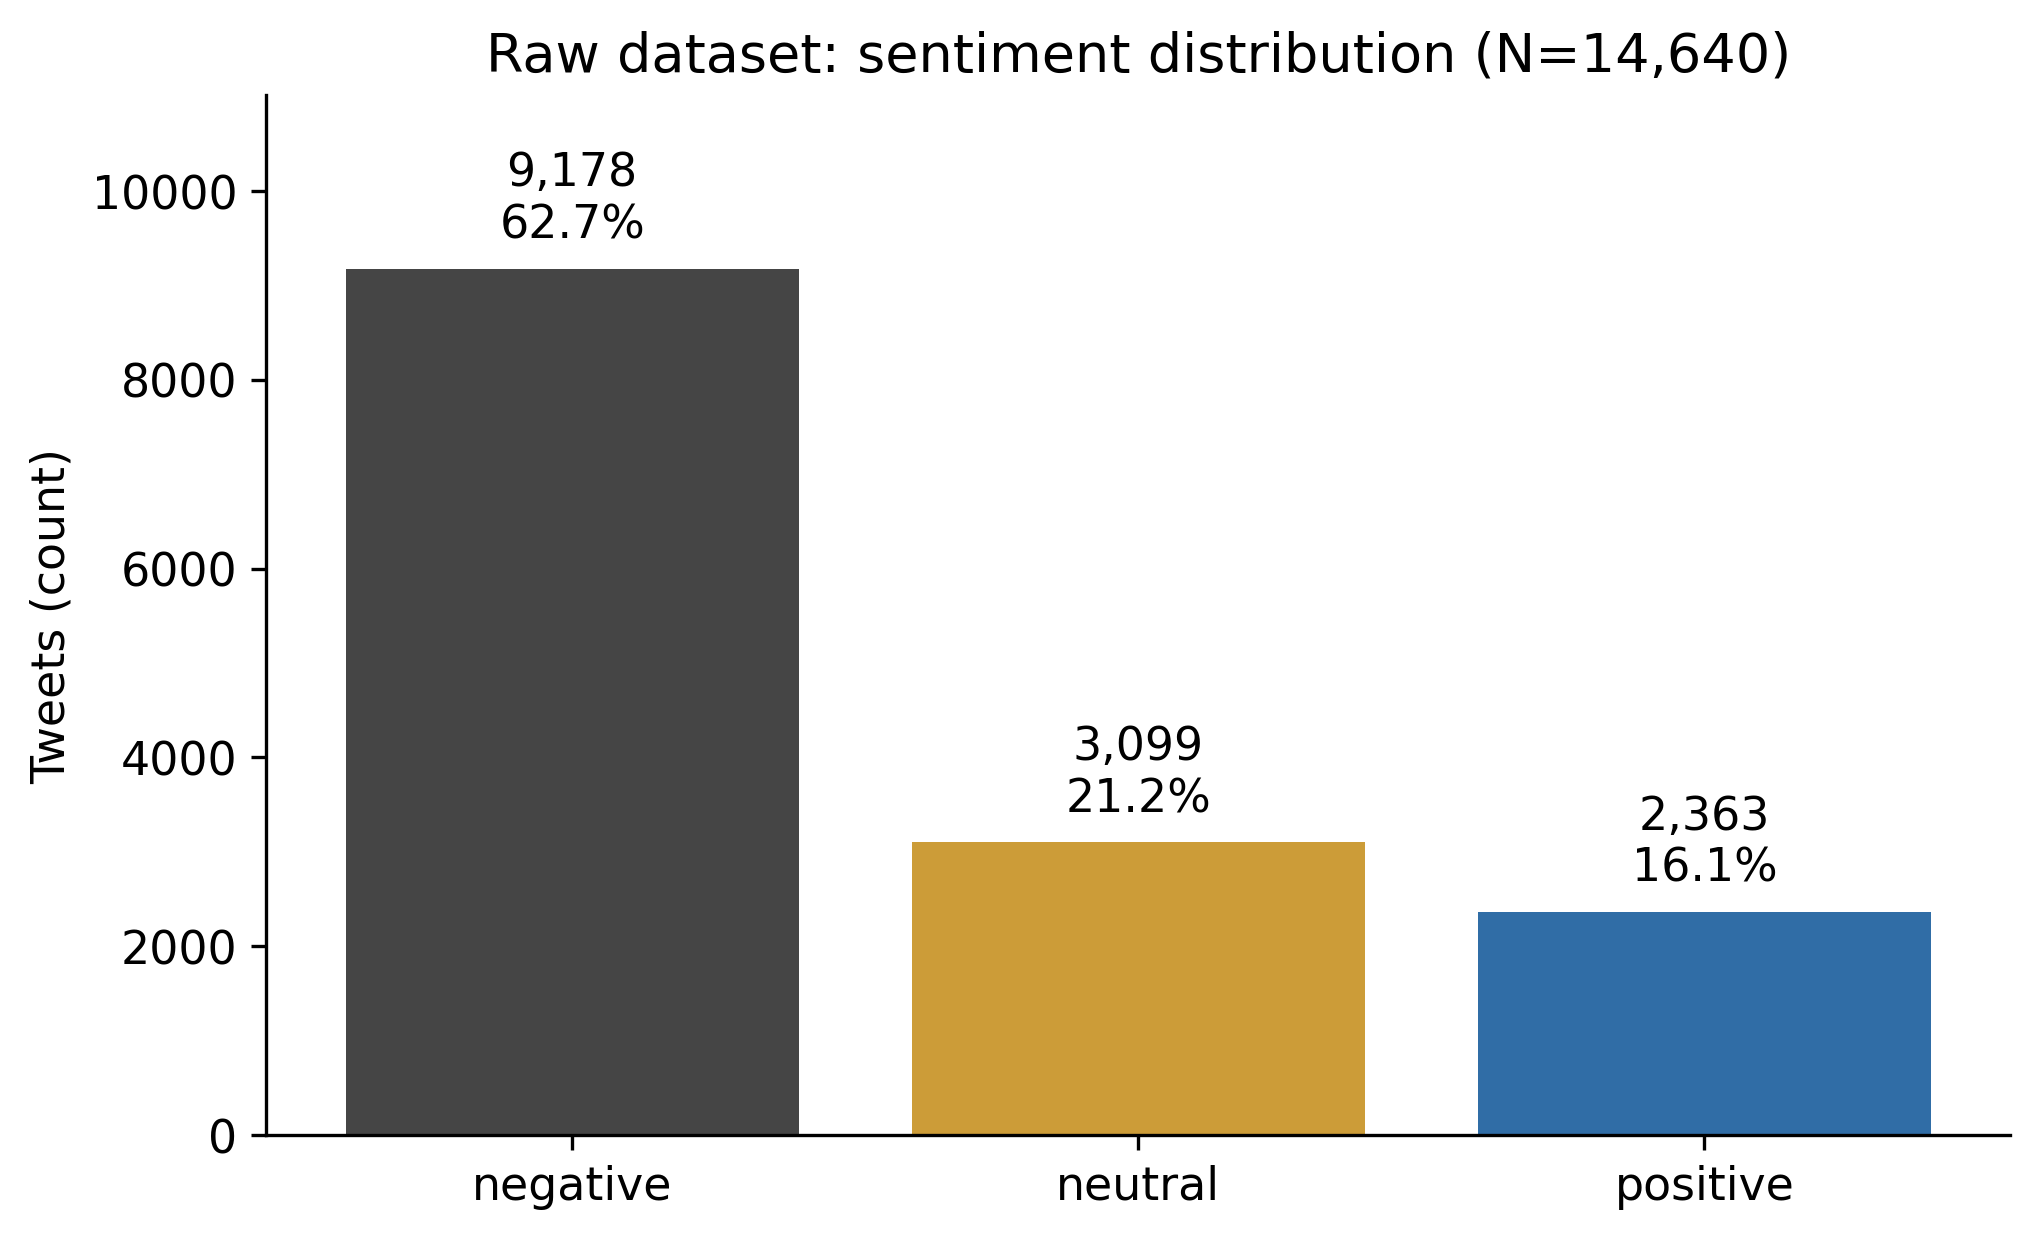

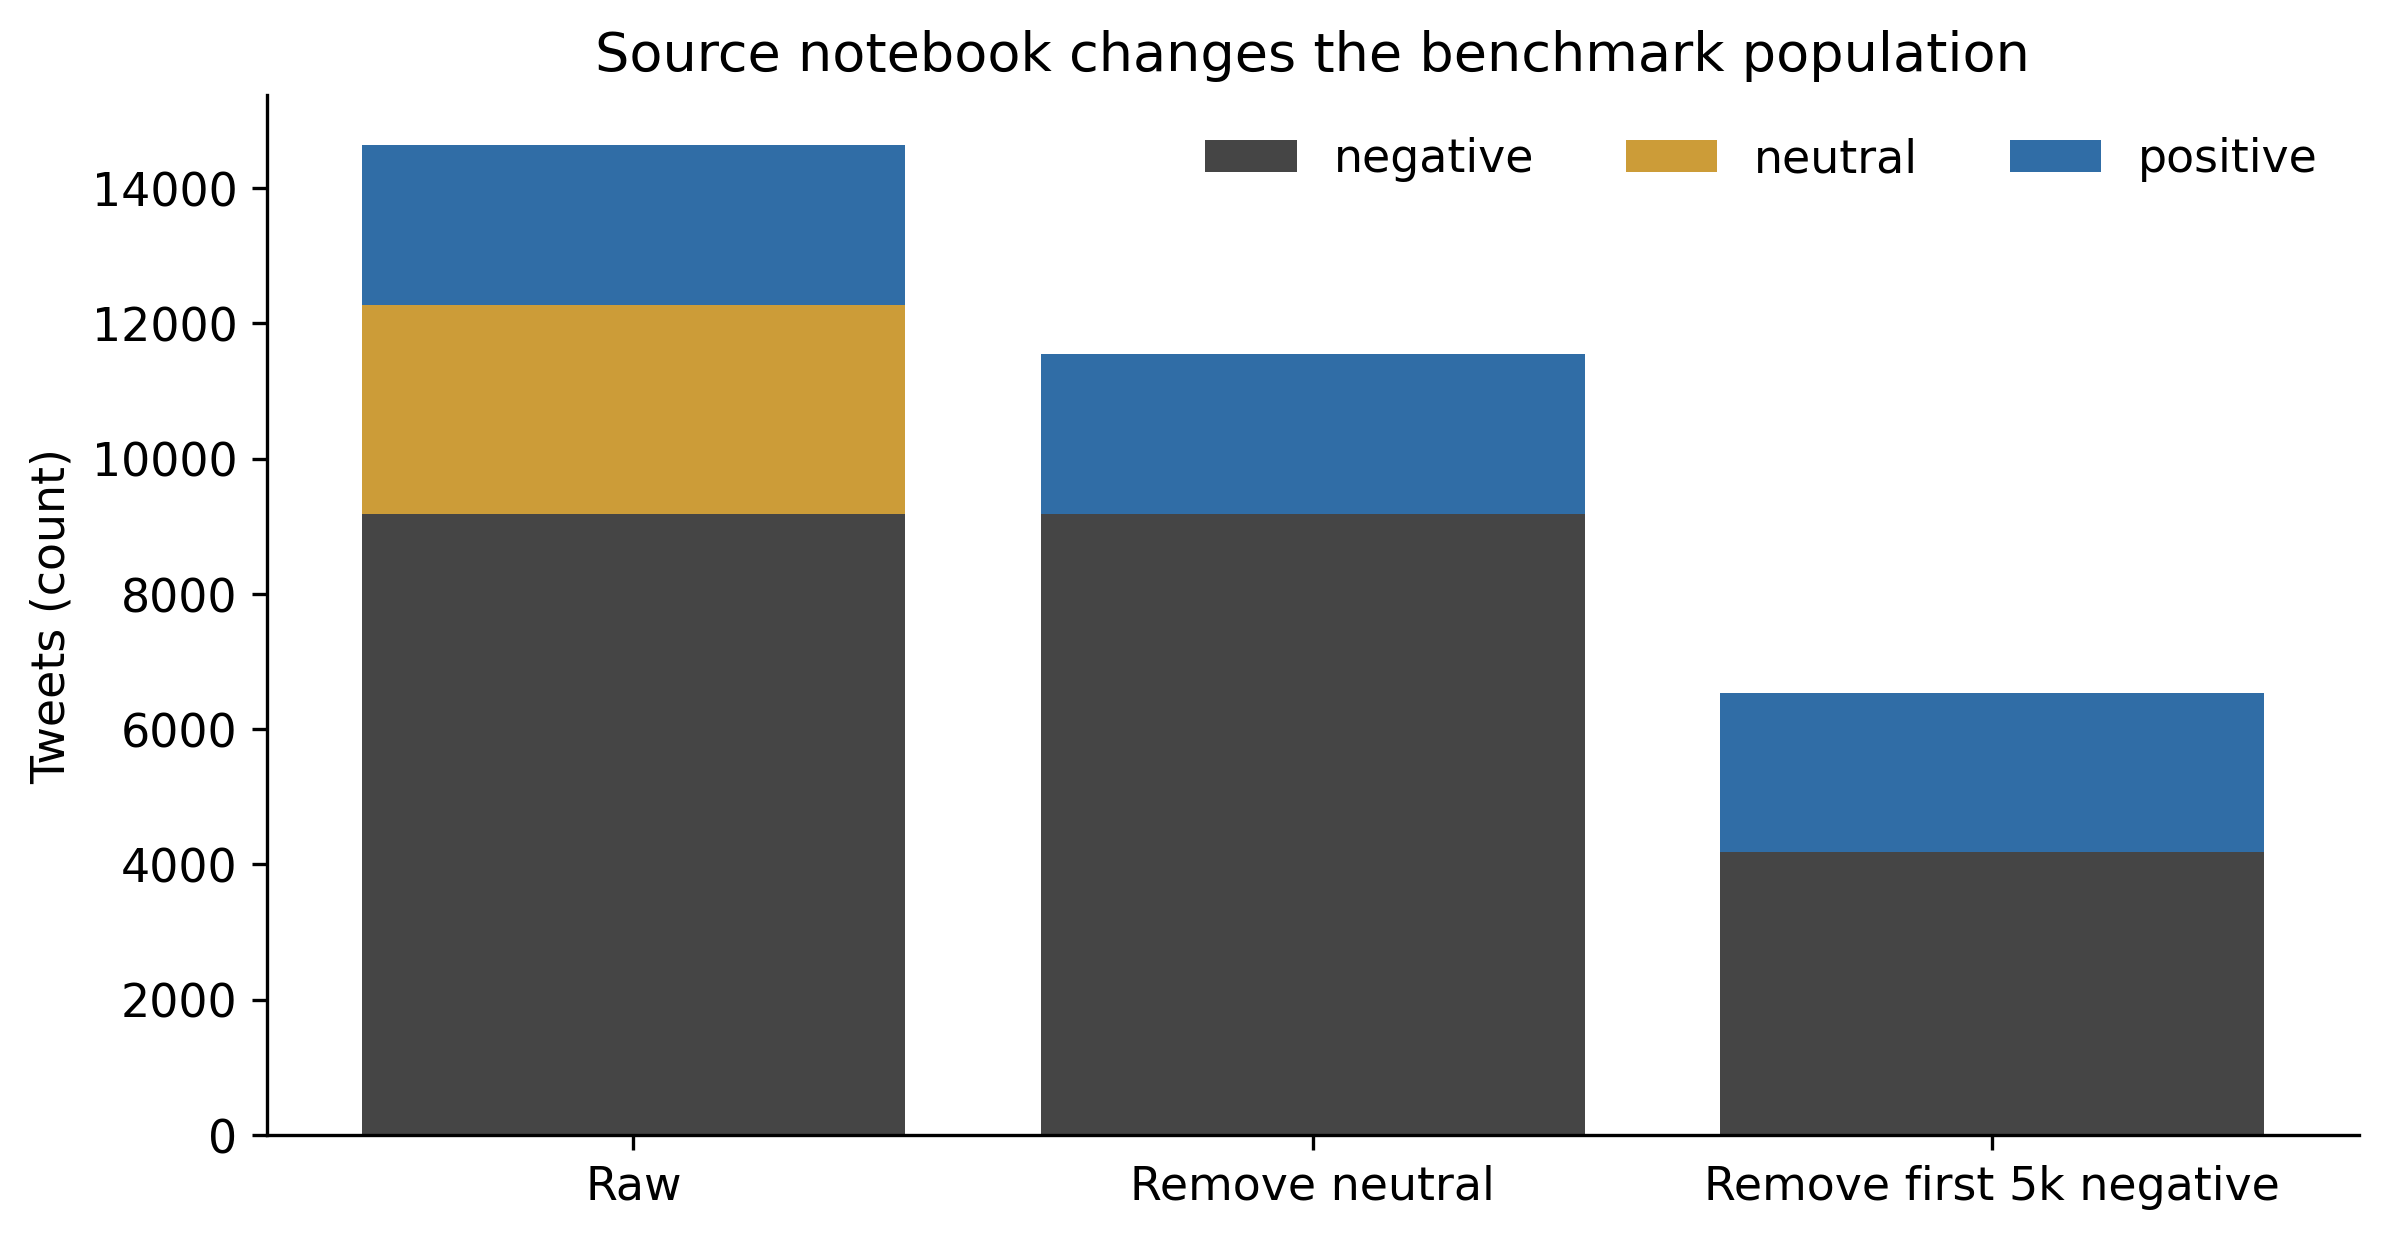

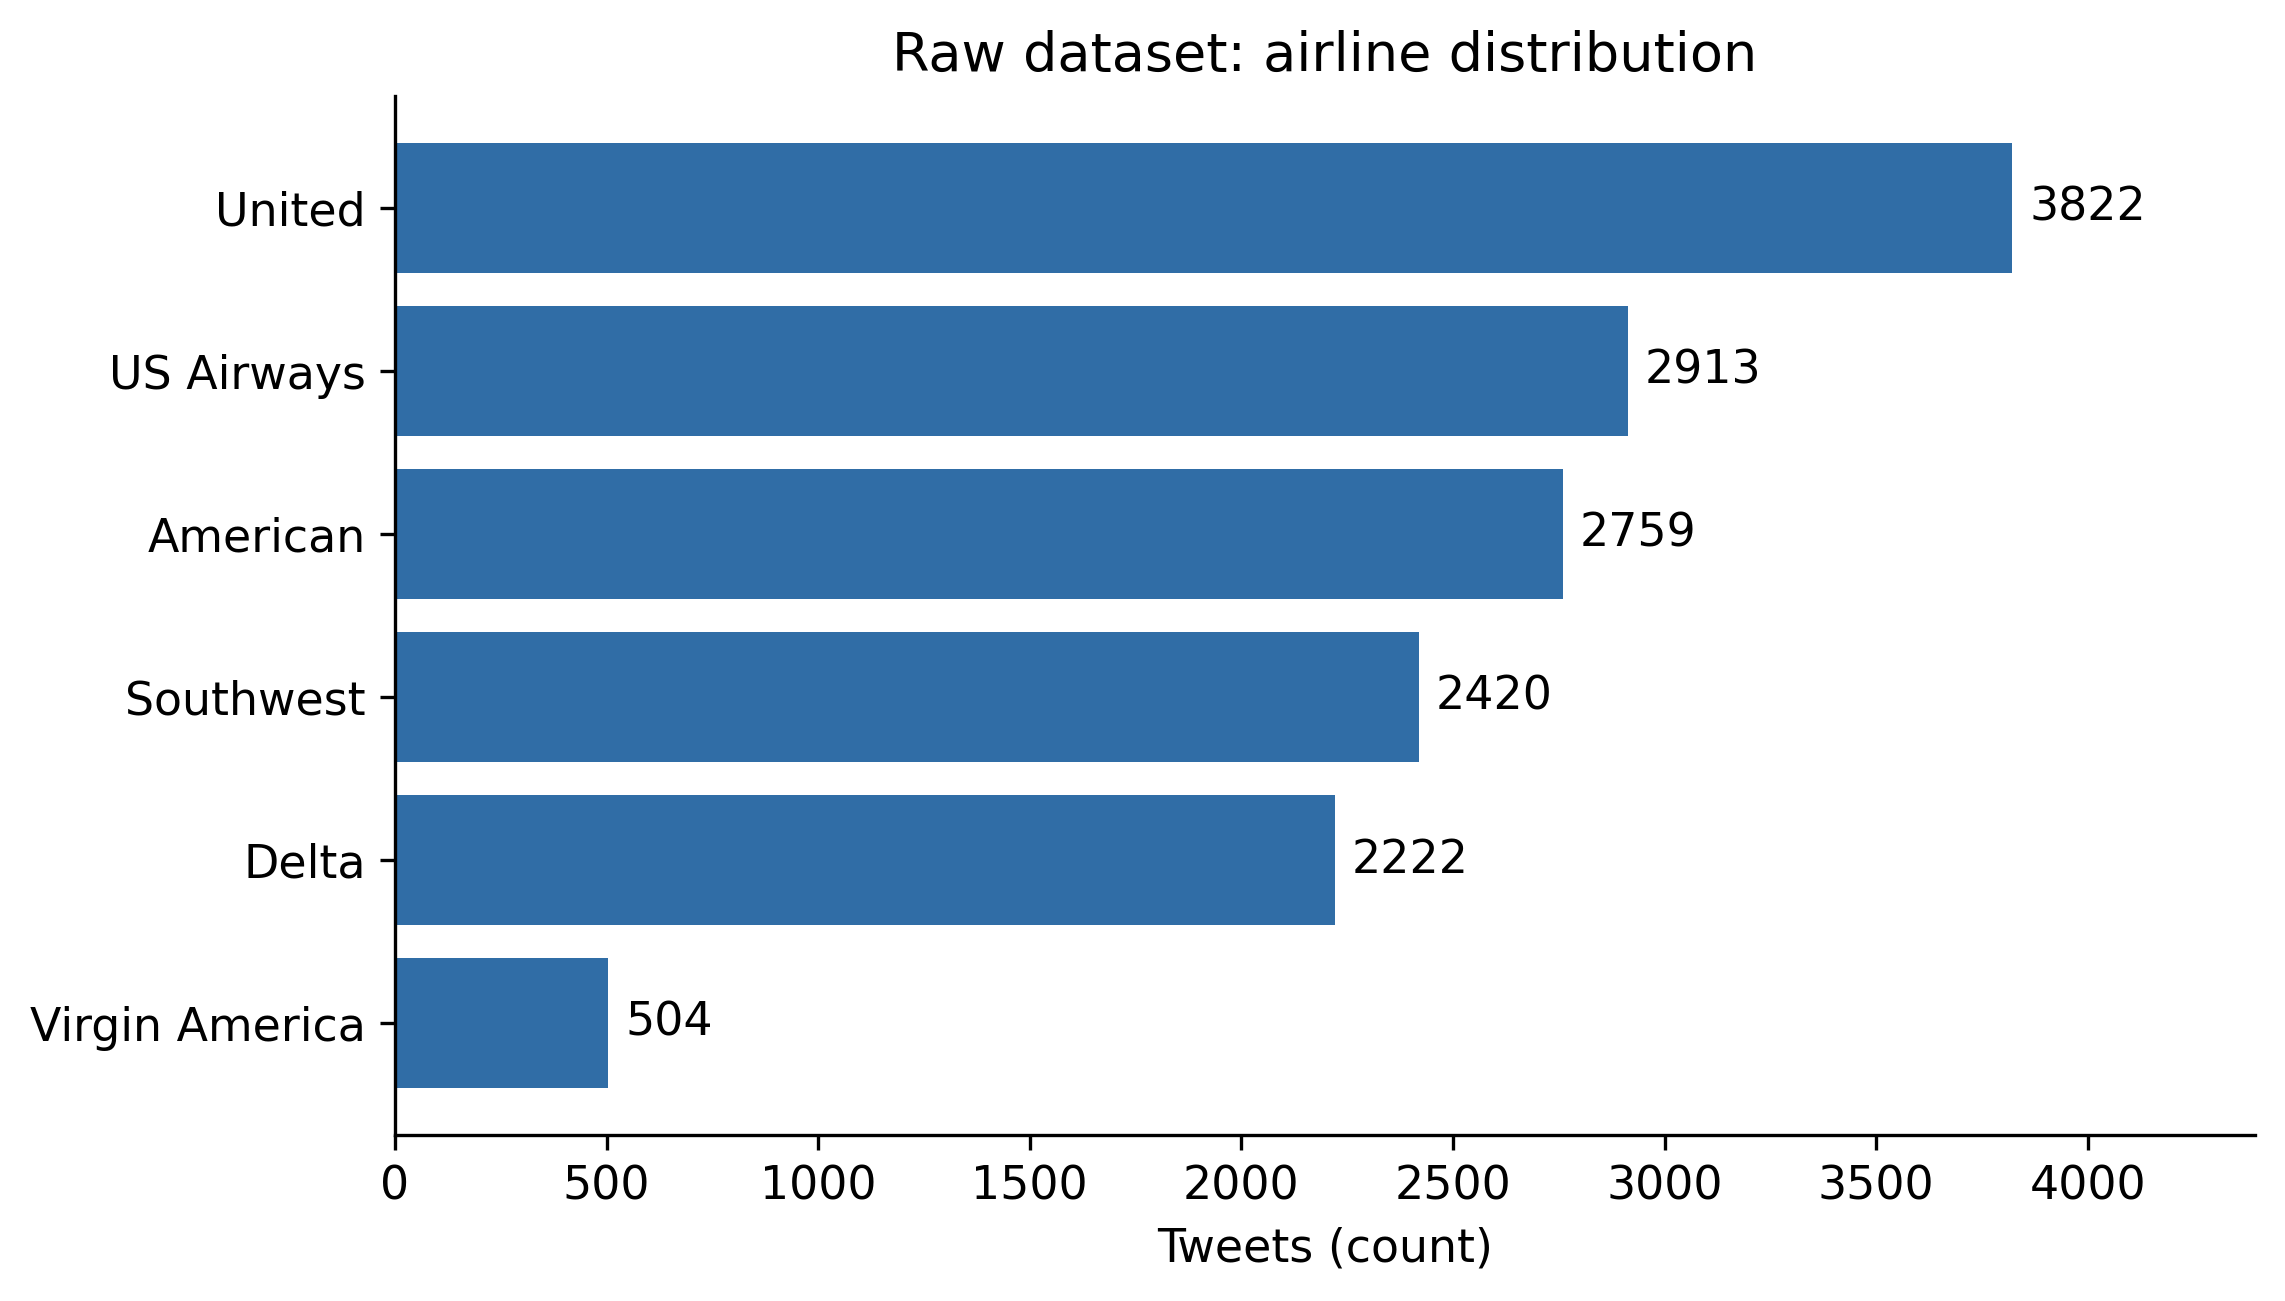

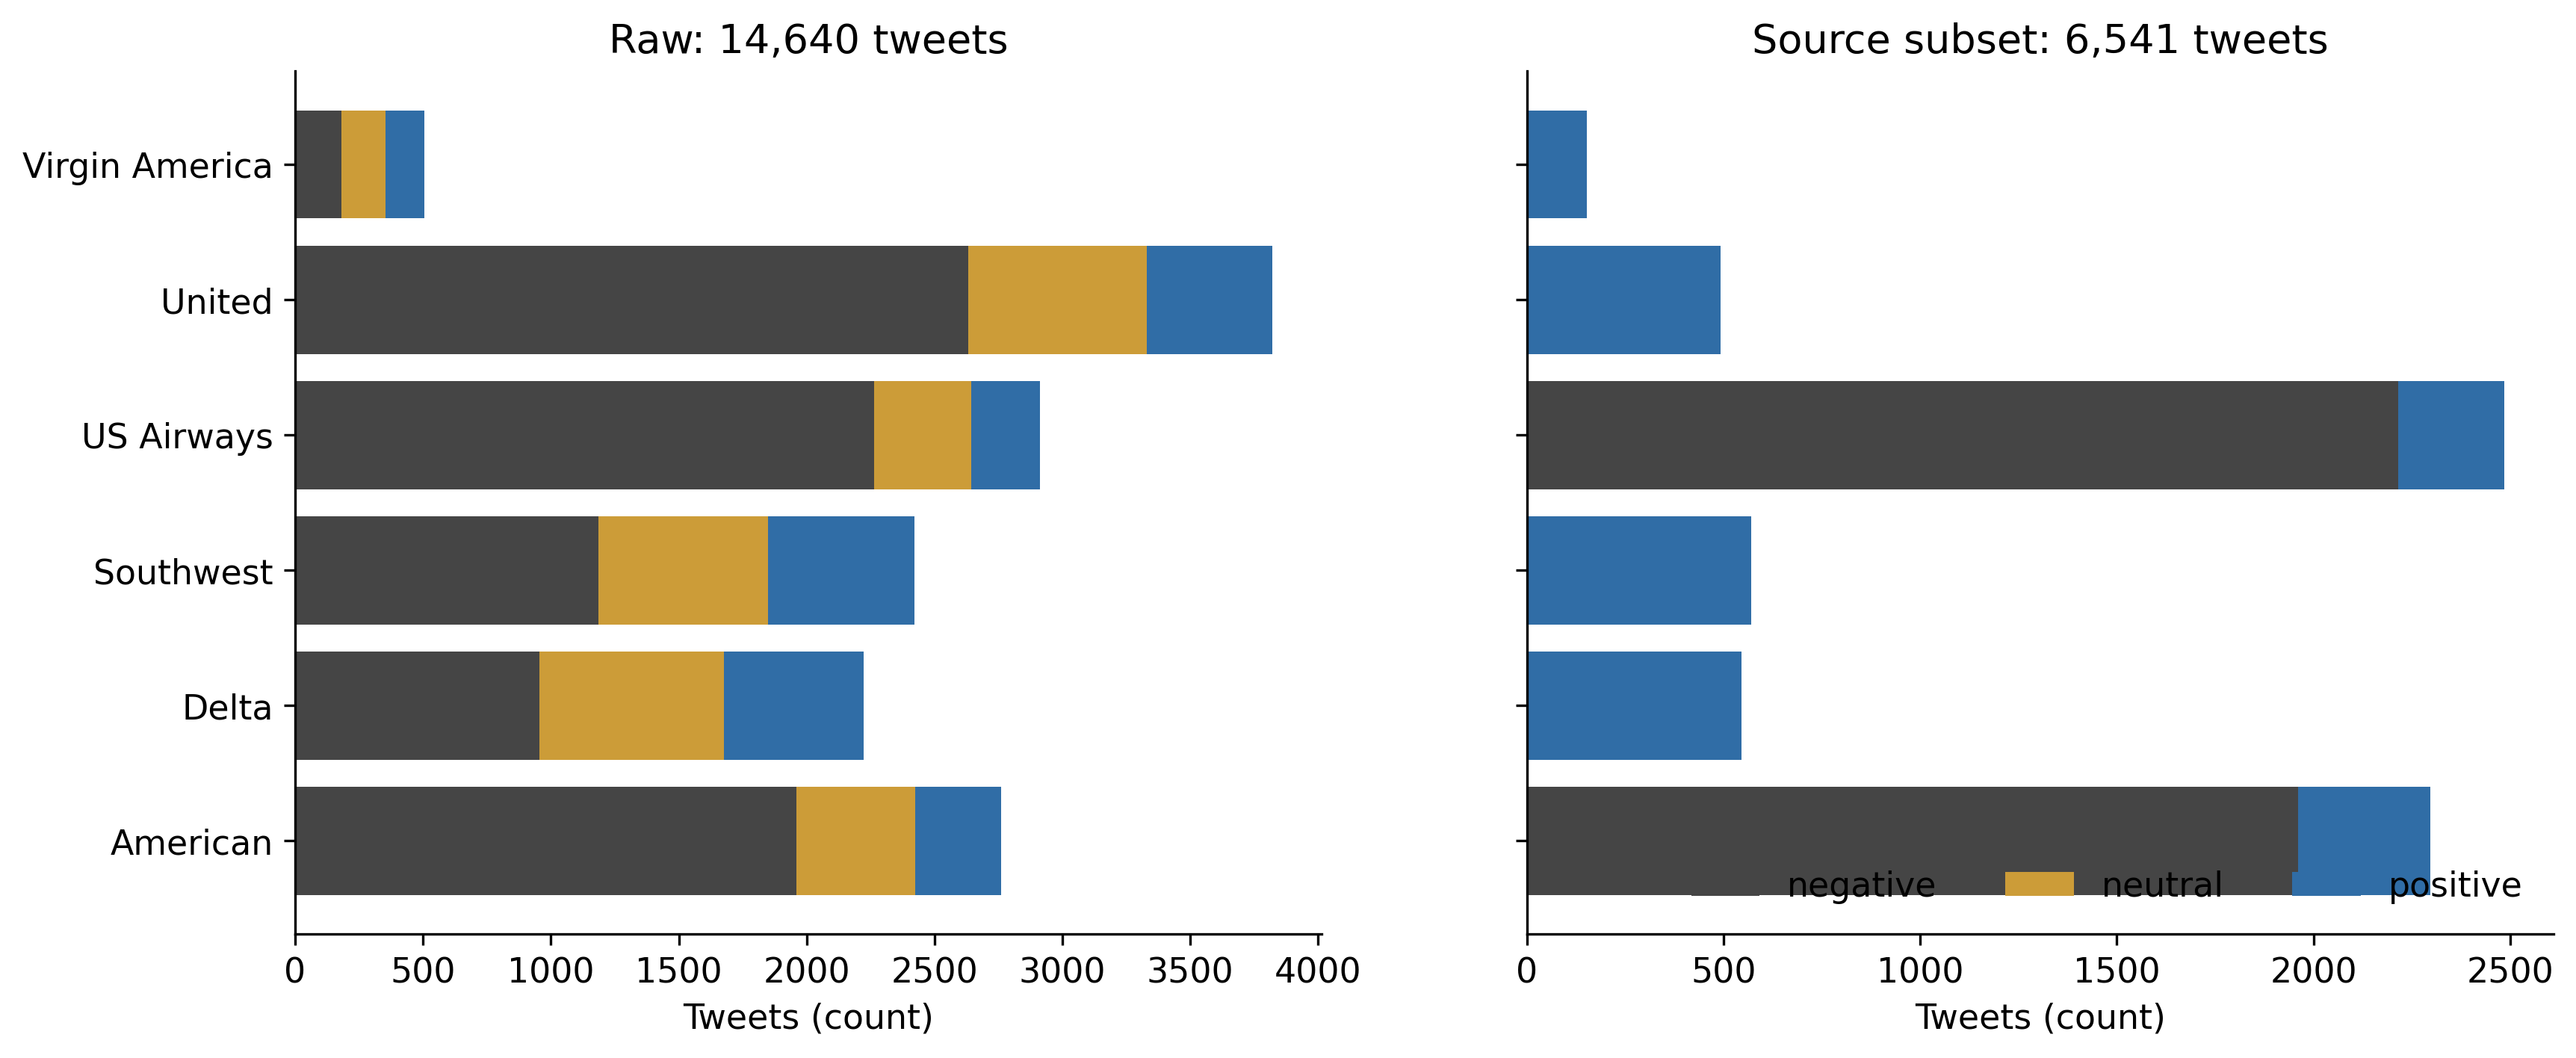

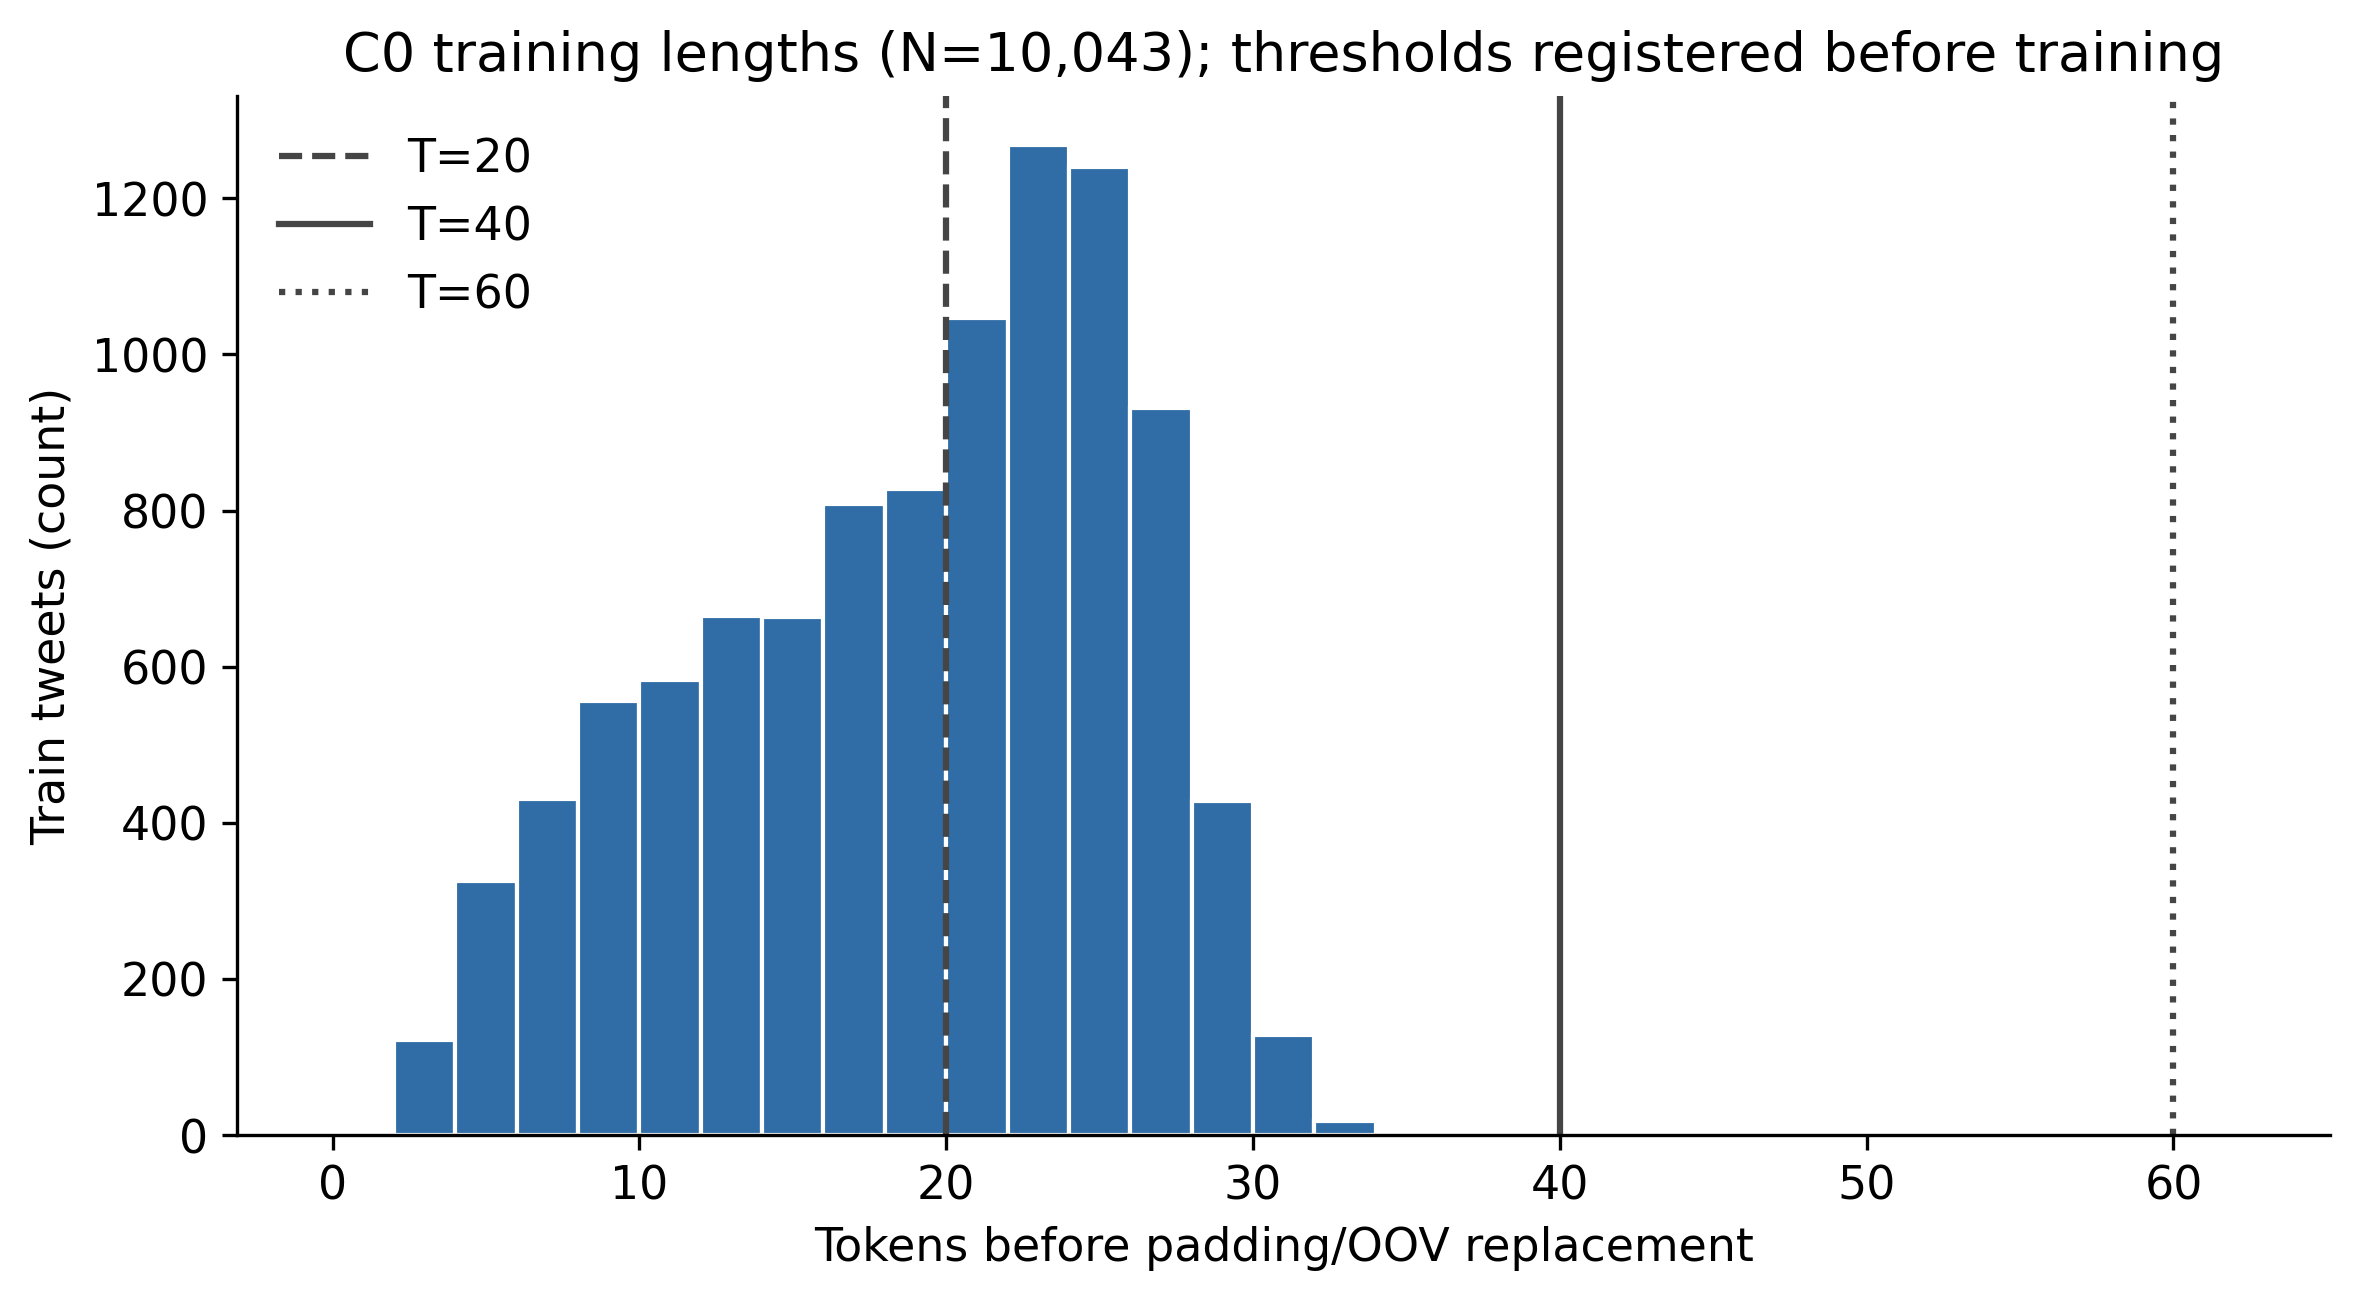

In [4]:
profile = prepare_data(RUN_ROOT)
for config, _ in configurations(TIER):
    prepare_representation(RUN_ROOT, config)
generate_eda(RUN_ROOT)
display(profile)
display(pd.read_csv(RUN_ROOT / "results/tables/dataset_splits.csv"))
display(pd.read_csv(RUN_ROOT / "results/tables/exclusions.csv"))
for name in ("F01_raw_sentiment", "F02_source_filtering", "F03_airlines", "F04_airline_filtering", "F05_train_lengths"):
    figure(name)

## Phase 3 — Preprocessing và biểu diễn chuỗi

P0: chuẩn hóa Unicode/HTML/apostrophe, lowercase, URL→`urlmarker`, mention→`usermarker`, mở contractions giữ phủ định (`can't`→`can not`), bỏ punctuation còn lại; không stopword removal/stemming. Text rỗng sau cleaning→`emptymarker`. Tokenizer fit train-only, cap4.000 gồm PAD0,OOV1,marker2–4. Không học vocabulary từ validation/test. C0/B post-padding, post-truncation, mask PAD; Embedding được học cùng model.

Ảnh preprocessing và CSV chứa ví dụ thật. Emoji/punctuation bị bỏ trong P0 là hạn chế đã biết; chưa khẳng định tác động lên Accuracy nếu chưa có ablation riêng. T40/T60 có thể cùng coverage; chỉ diễn giải thêm context khi thống kê truncation hỗ trợ.

,row_id,text,source_clean,P0_clean
0,1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...,usermarker plus you have added commercials to ...
1,17,@VirginAmerica I flew from NYC to SFO last we...,i flew from nyc to sfo last week and couldnt...,usermarker i flew from nyc to sfo last week an...
2,18,I ❤️ flying @VirginAmerica. ☺️👍,i flying virginamerica,i flying usermarker
3,21,@VirginAmerica I love this graphic. http://t.c...,i love this graphic httptcout5grrwaaa,usermarker i love this graphic urlmarker
4,28,@VirginAmerica amazing to me that we can't get...,amazing to me that we cant get any cold air f...,usermarker amazing to me that we can not get a...


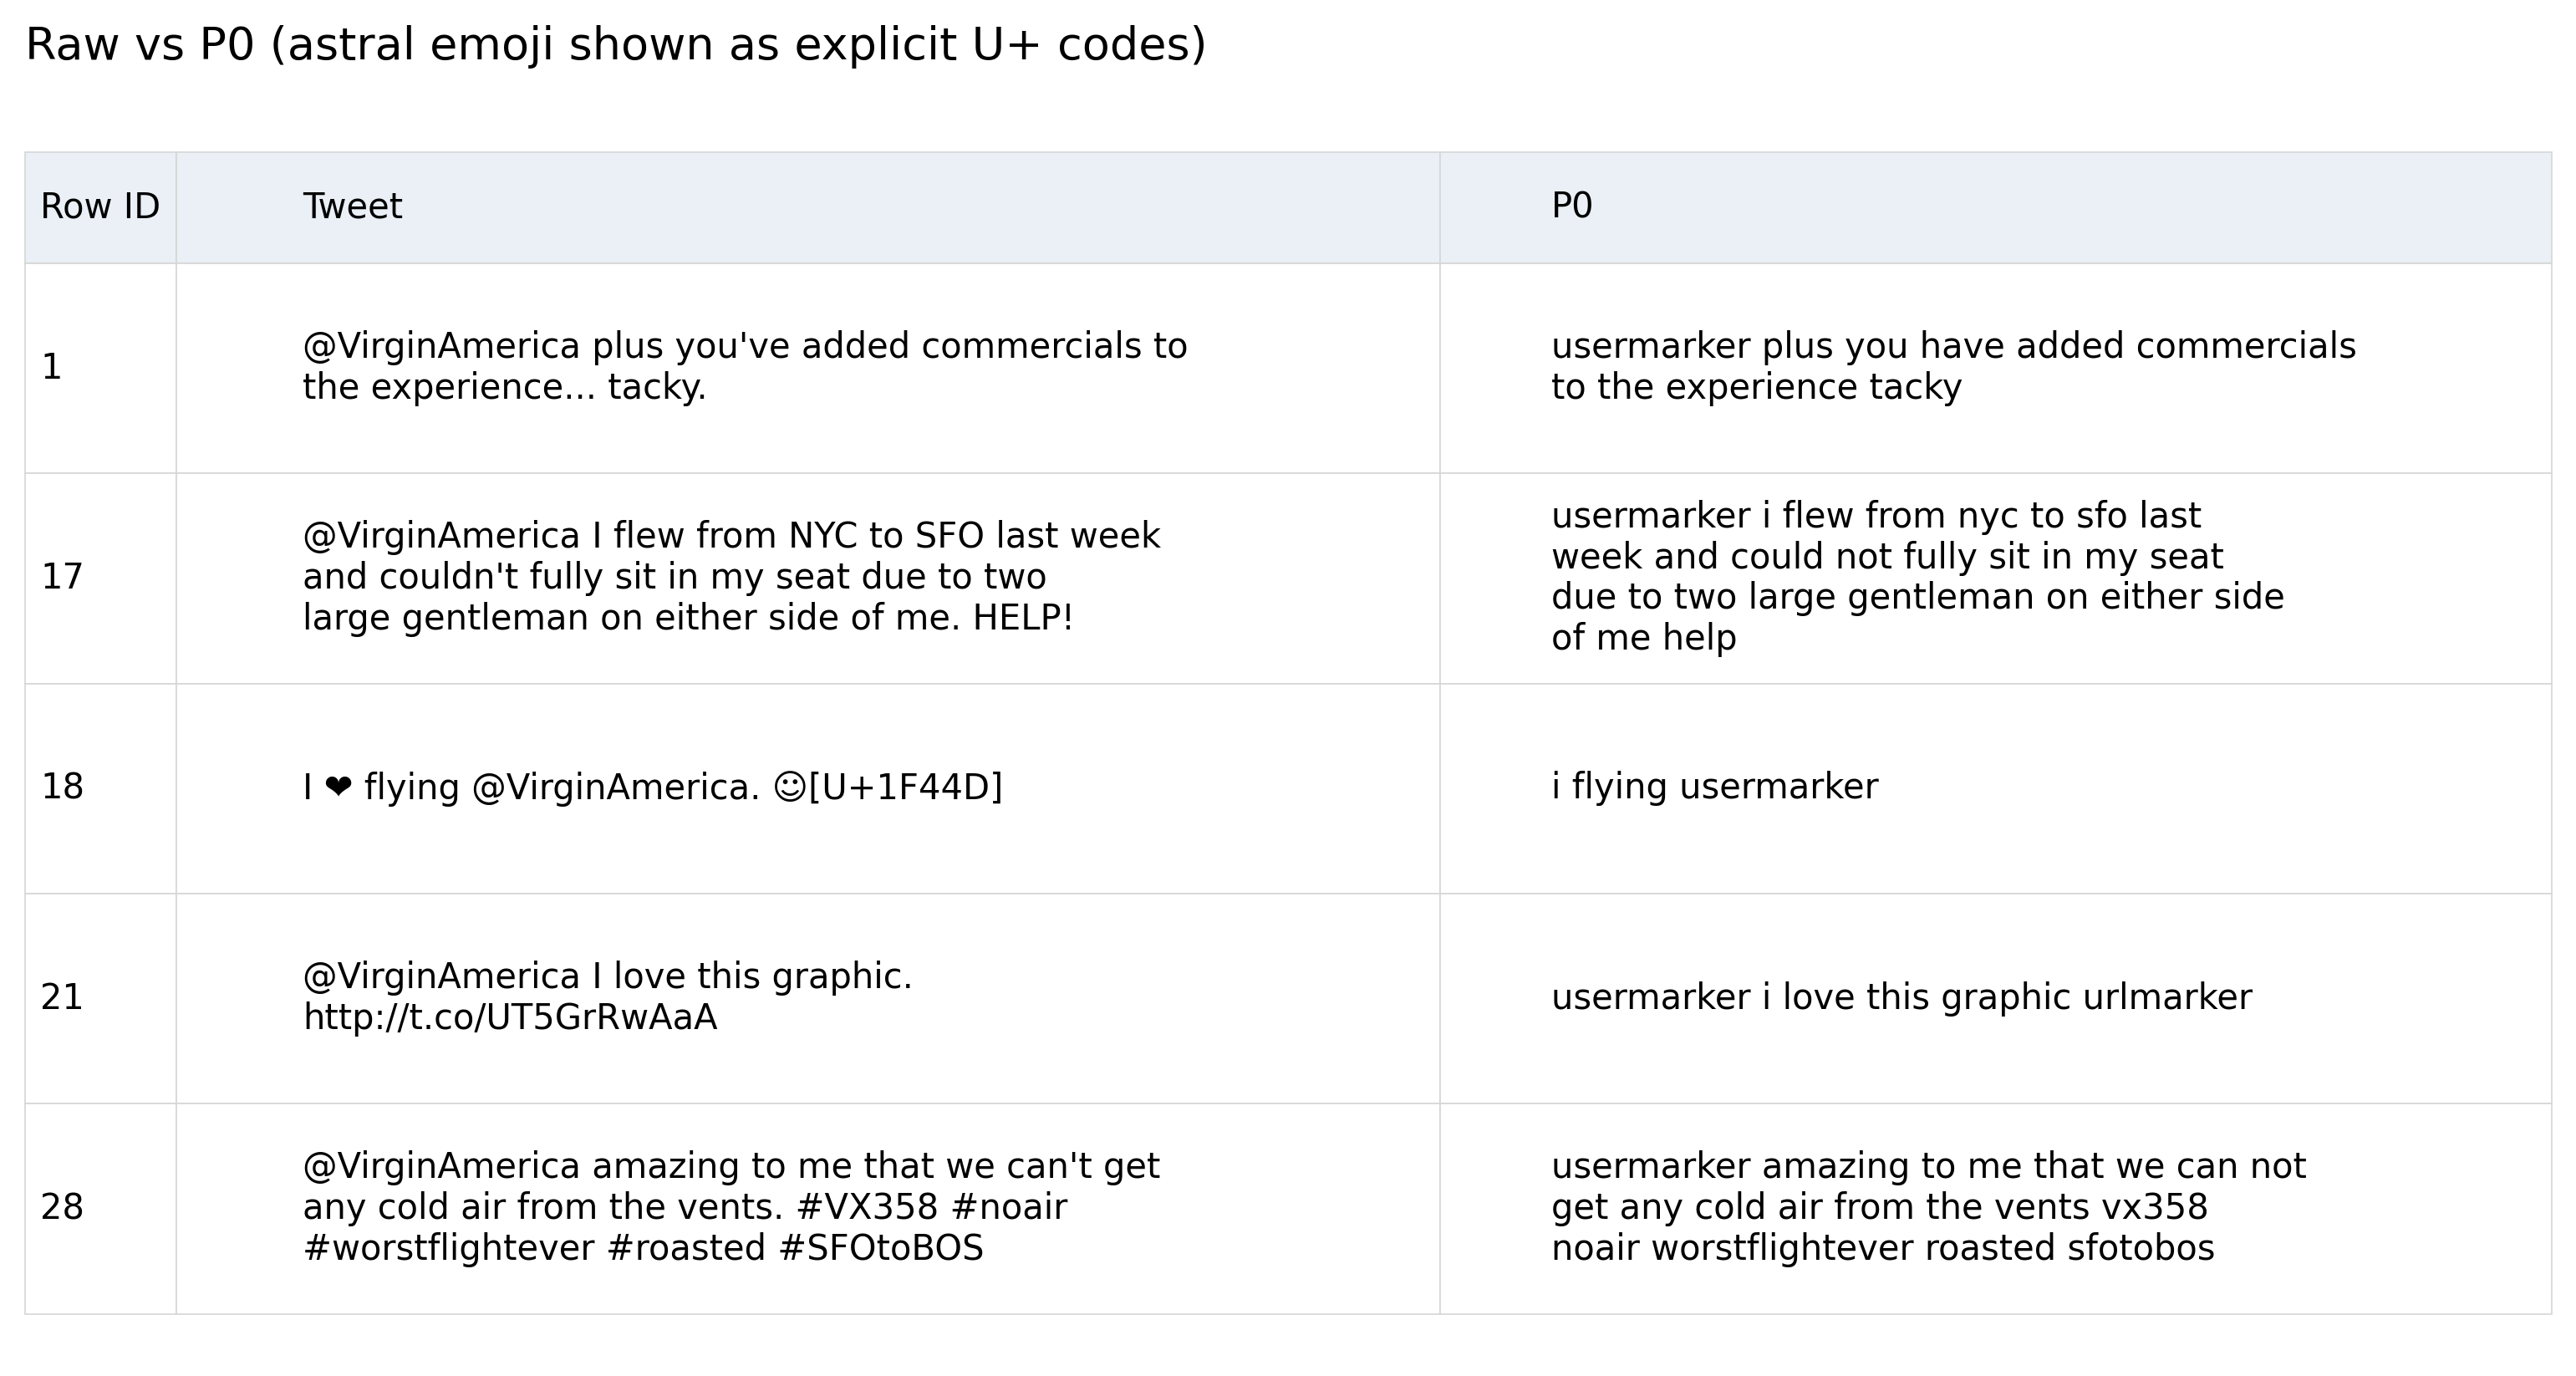

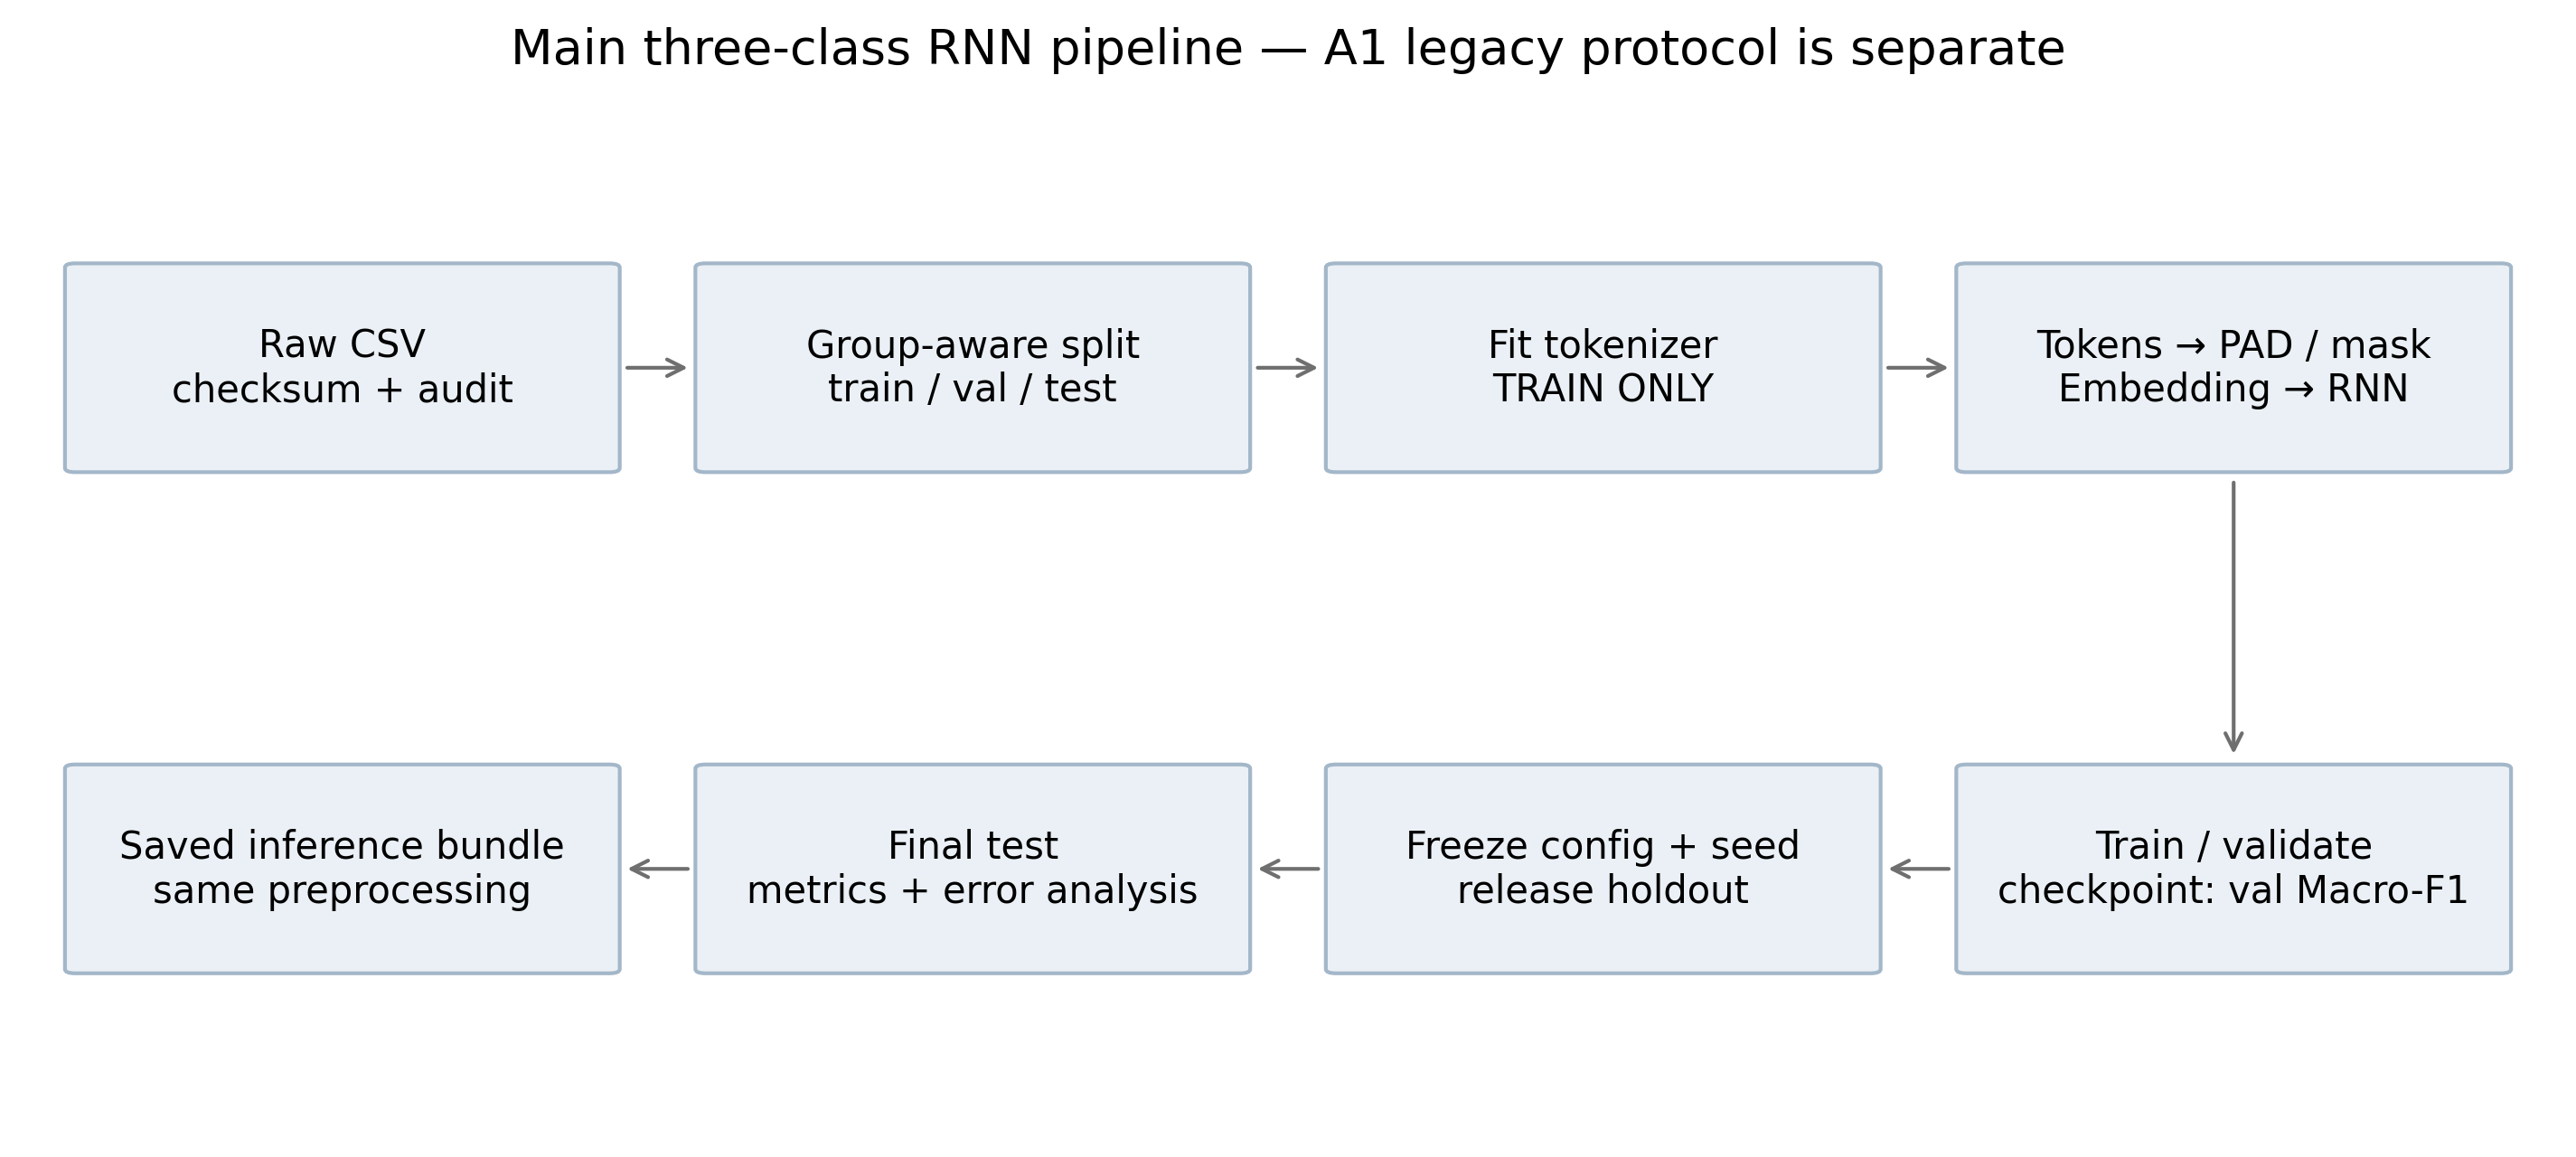

{'config_id': 'C0',
 'benchmark': 'three_class',
 'sequence_length': 40,
 'padding': 'post',
 'truncating': 'post',
 'legacy': False,
 'tokenizer_sha256': 'a25cfee0cb53001674deebfca6ea4fa1aaeb0f2a4a46dc5f3d3b92624e1f135e',
 'split_sha256': '1a520dcff55d7b0ee6263e189be88f7bac47a418c082b28f0b9f00f93bf332b1',
 'dataset_sha256': 'ea94b23f41892b290dec3330bb8cf9cb6b8bc669eaae5f3a84c40f7b0de8f15e',
 'fit_row_ids_sha256': '0d3819af28141899c85e1e16d29e20c70399d5cc8c65a6ac413820abf1c8d601',
 'fit_scope': 'train_only',
 'word_index_size': 4000,
 'stats': {'train': {'rows': 10043,
   'oov_token_rate': 0.04260147029215391,
   'truncation_rate': 0.0,
   'empty_sequence_count': 0,
   'length_percentiles': {'0.5': 20.0,
    '0.9': 26.0,
    '0.95': 28.0,
    '0.99': 30.0}},
  'validation': {'rows': 2161,
   'oov_token_rate': 0.05775208734746307,
   'truncation_rate': 0.0,
   'empty_sequence_count': 0,
   'length_percentiles': {'0.5': 19.0,
    '0.9': 26.0,
    '0.95': 28.0,
    '0.99': 30.0}}}}

In [5]:
display(pd.read_csv(RUN_ROOT / "results/tables/preprocessing_examples.csv"))
for name in ("F07_preprocessing", "F08_pipeline"):
    figure(name)
display(read_json(RUN_ROOT / ("data/processed/C0/representation.json" if TIER != "minimum" else "data/processed/A2/representation.json")))

## Phase 4–6 — Baseline và ma trận controlled experiments

Với embedding $x_t$, RNN cập nhật $h_t=\tanh(W_xx_t+W_hh_{t-1}+b)$; hidden state cuối → Dense/ReLU → softmax. Không có gate. Vanishing/exploding gradient là động cơ lý thuyết; không kết luận đã quan sát từ learning curve nếu chưa đo gradient. C0/B clip global norm1.0; A1/A2 giữ Adam không clipping.

- A1: source binary pipeline adapted, seed42, epoch20 cuối; không ES.
- A2: clean binary, train-only tokenizer/group split, 3 seeds.
- C0: main3class, T40/H196/embedding128, 3 seeds.
- B1-20/B1-60: chỉ đổi sequence length. B3-64/B3-128: chỉ đổi hidden units. B5-balanced: chỉ đổi class weights `N_train/(K*n_class_train)`.

Những factor còn lại giữ cố định. Mỗi run lưu config, code/data/split hashes, environment, class weights, history, best/last checkpoint, validation predictions. Best checkpoint theo **full-validation Macro-F1**, tie theo validation loss; ES patience5/min_delta0.001/max20epochs. Metrics full-split trong inference mode, không lấy trung bình F1 theo minibatch. Smoke test nhỏ dưới đây tách khỏi run khoa học.

In [6]:
smoke = run_experiment(RUN_ROOT, configuration_by_id("C0"), 42, smoke=True, max_epochs=2)
print("SMOKE ONLY — excluded from selection/test/report comparisons:")
display({key: smoke[key] for key in ("status", "smoke", "epochs_trained", "parameters")})

Verified cached run: C0 seed=42


SMOKE ONLY — excluded from selection/test/report comparisons:


{'status': 'completed',
 'smoke': True,
 'epochs_trained': 2,
 'parameters': 595703}

In [7]:
# This is the computationally expensive cell on a fresh root.
# Cached runs are accepted only if config/code/data and artifact hashes match.
if (RUN_ROOT / "results/metrics/final_selection.json").exists():
    verified_runs(RUN_ROOT)  # block incomplete/modified cache after selection
runs = run_matrix(RUN_ROOT, tier=TIER)
print("Completed scientific runs:", len(runs))
display(pd.read_csv(RUN_ROOT / "results/tables/validation_runs.csv"))

Selection already frozen; only matching cached runs are permitted.


Verified cached run: A1 seed=42


Verified cached run: A2 seed=42


Verified cached run: A2 seed=2026


Verified cached run: A2 seed=3407


...

Verified cached run: B5-balanced seed=42


Verified cached run: B5-balanced seed=2026


Verified cached run: B5-balanced seed=3407


Completed scientific runs: 22


,seed,validation_accuracy,validation_macro_f1,validation_weighted_f1,training_seconds,parameters,epochs_trained,best_epoch,config_id,benchmark
0,42,0.848253,0.837562,0.847116,19.478890,595602,20,16,A1,binary_source
1,42,0.646927,0.421096,0.525730,6.420152,595602,6,1,A2,binary_clean
2,2026,0.686034,0.650327,0.682663,19.865503,595602,20,18,A2,binary_clean
3,3407,0.867039,0.854989,0.867086,13.215770,595602,13,8,A2,binary_clean
4,42,0.751967,0.663404,0.746561,77.216914,595703,20,20,C0,three_class
5,2026,0.744563,0.660284,0.743471,75.591447,595703,20,18,C0,three_class
6,3407,0.757057,0.663194,0.749670,76.486885,595703,20,18,C0,three_class
7,42,0.764924,0.685020,0.758910,37.132279,595703,18,13,B1-20,three_class
8,2026,0.758908,0.677286,0.752903,41.321485,595703,20,20,B1-20,three_class
9,3407,0.746876,0.654424,0.741329,39.610599,595703,19,14,B1-20,three_class


## Phase 7 — Khóa mô hình cuối bằng validation, rồi mở test

Selection dùng mean validation Macro-F1. Những configuration cách max dưới0.005 được ưu tiên ít parameters, sau đó median training time và thứ tự matrix. Tolerance là quy tắc thực dụng đặt trước, không phải kiểm định tương đương. Demo dùng seed có validation Macro-F1 trung vị, chọn trước khi đọc test.

Mô hình cuối giữ checkpoint đã train trên train và chọn epoch trên validation; không refit train+validation sau khi xem test. Test chỉ đánh giá A1/A2/C0/winner; test của ablation không được chọn để trống. Không ghép nhiều factor thắng thành một model chưa đăng ký. Ba seeds dùng cùng split; mean±SD phản ánh training variability, không phải confidence interval.

In [8]:
selection = freeze_selection(RUN_ROOT)
display(selection)
display(pd.read_csv(RUN_ROOT / "results/tables/validation_summary.csv"))
# All model selection above is frozen before this call first reads test features for prediction.
test_summary = evaluate_final(RUN_ROOT)
display(test_summary)

{'winner_config': 'B5-balanced',
 'demo_seed': 3407,
 'criterion': 'mean_validation_macro_f1; tolerance<0.005; fewer_parameters; median_training_time; frozen_order',
 'demo_seed_policy': 'median_validation_macro_f1_before_test',
 'tier': 'recommended',
 'matrix_sha256': 'd90c1078f7a2fd19fc511007720eab5df6b90648ab317f1b8a9640aeaa14b0be',
 'run_fingerprints': {'A1/seed-42': '39284d8ab9a4b897b81a74b06798161fe0816fa5afbe26142814a3113160a57c',
  'A2/seed-42': 'f25bf6086a200f14c1d0a58e0159694c329e95ec7d5a7e3c708f22e20b9125dd',
  'A2/seed-2026': 'd463035d55db8daae78ad9f63520e13d1fc07cd68d7010952471cfd9e05cadb7',
  'A2/seed-3407': '279f3d7e00f98e662eb6df25e299b34b9043b6d245d7c249d7c0d651b9c7a916',
  'C0/seed-42': '9bcf75c1d1b9b902f0c6ddb83419fe4b24afc069d91f430302ed9c98c80819f5',
  'C0/seed-2026': '23d8be6aa25654c98e594441ed5c7ce3aac746698b39423458cd7a9f2d03031b',
  'C0/seed-3407': '3d5016b9463604a0ae04256ed7c554e13934d54d6498b8de45f5739dceb7226e',
  'B1-20/seed-42': '0f954b1dc63c2fd623595dcd4

,config_id,benchmark,seeds,val_accuracy_mean,val_accuracy_std,val_macro_f1_mean,val_macro_f1_std,val_weighted_f1_mean,parameters,training_seconds_median,epochs_mean
0,A1,binary_source,1,0.848253,0.000000,0.837562,0.000000,0.847116,595602,19.478890,20.000000
1,A2,binary_clean,3,0.733333,0.117432,0.642137,0.217062,0.691826,595602,13.215770,13.000000
2,C0,three_class,3,0.751195,0.006283,0.662294,0.001744,0.746567,595703,76.486885,20.000000
3,B1-20,three_class,3,0.756903,0.009189,0.672243,0.015909,0.751047,595703,39.610599,19.000000
4,B1-60,three_class,3,0.751195,0.006283,0.662294,0.001744,0.746567,595703,108.855791,20.000000
5,B3-64,three_class,3,0.758754,0.003011,0.662468,0.007324,0.746579,531155,30.324936,16.666667
6,B3-128,three_class,3,0.762147,0.002017,0.672404,0.007898,0.752805,558099,50.474117,19.000000
7,B5-balanced,three_class,3,0.752121,0.008562,0.692637,0.011464,0.755815,595703,75.464372,19.333333


,config_id,benchmark,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,support,seeds
0,A1,binary_source,0.838003,0.000000,0.824899,0.000000,0.838198,1963,1
1,A2,binary_clean,0.740760,0.111174,0.653097,0.218315,0.698936,1966,3
2,C0,three_class,0.747479,0.006318,0.651539,0.001669,0.742339,2149,3
3,B5-balanced,three_class,0.751823,0.013376,0.691425,0.015812,0.756758,2149,3
4,majority,binary_source,0.638818,0.000000,0.389804,0.000000,0.498028,1963,1
5,majority,binary_clean,0.639369,0.000000,0.390009,0.000000,0.498720,1966,1
6,majority,three_class,0.636575,0.000000,0.259312,0.000000,0.495215,2149,1


## Phase 5/7 — Metrics và hình kết quả thực tế

Accuracy=$\#correct/N$. Precision/Recall/F1 báo riêng mỗi lớp; Macro-F1 là trung bình không trọng số của F1 lớp, Weighted-F1 theo support. Negative chiếm đa số, nên một bộ dự đoán toàn negative vẫn có Accuracy đáng kể trong khi bỏ qua neutral/positive. Majority comparator lấy lớp nhiều nhất từ train. Classification report có đủ Precision/Recall/F1/Support/Macro/Weighted.

Confusion matrix: hàng=true, cột=predicted. Hình count và chuẩn hóa theo hàng có cùng checkpoint. Per-class/curves/examples của seed trung vị phải phân biệt với bảng mean±SD 3 seeds.

,config_id,benchmark,seeds,val_accuracy_mean,val_accuracy_std,val_macro_f1_mean,val_macro_f1_std,val_weighted_f1_mean,parameters,training_seconds_median,epochs_mean,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_policy
0,A1,binary_source,1,0.848253,0.000000,0.837562,0.000000,0.847116,595602,19.478890,20.000000,0.838003,0.0,0.824899,0.0,0.838198,final evaluation
1,A2,binary_clean,3,0.733333,0.117432,0.642137,0.217062,0.691826,595602,13.215770,13.000000,0.74076,0.111174,0.653097,0.218315,0.698936,final evaluation
2,C0,three_class,3,0.751195,0.006283,0.662294,0.001744,0.746567,595703,76.486885,20.000000,0.747479,0.006318,0.651539,0.001669,0.742339,final evaluation
3,B1-20,three_class,3,0.756903,0.009189,0.672243,0.015909,0.751047,595703,39.610599,19.000000,withheld,withheld,withheld,withheld,withheld,withheld: validation-only ablation
4,B1-60,three_class,3,0.751195,0.006283,0.662294,0.001744,0.746567,595703,108.855791,20.000000,withheld,withheld,withheld,withheld,withheld,withheld: validation-only ablation
5,B3-64,three_class,3,0.758754,0.003011,0.662468,0.007324,0.746579,531155,30.324936,16.666667,withheld,withheld,withheld,withheld,withheld,withheld: validation-only ablation
6,B3-128,three_class,3,0.762147,0.002017,0.672404,0.007898,0.752805,558099,50.474117,19.000000,withheld,withheld,withheld,withheld,withheld,withheld: validation-only ablation
7,B5-balanced,three_class,3,0.752121,0.008562,0.692637,0.011464,0.755815,595703,75.464372,19.333333,0.751823,0.013376,0.691425,0.015812,0.756758,final evaluation


,layer,type,input_shape,output_shape,parameters
0,word_embedding,Embedding,"(None, 40)","(None, 40, 128)",512000
1,embedding_dropout,SpatialDropout1D,"(None, 40, 128)","(None, 40, 128)",0
2,rnn,RNN,"(None, 40, 128)","(None, 196)",63700
3,state_dropout,Dropout,"(None, 196)","(None, 196)",0
4,dense_features,Dense,"(None, 196)","(None, 100)",19700
5,dense_dropout,Dropout,"(None, 100)","(None, 100)",0
6,sentiment_probabilities,Dense,"(None, 100)","(None, 3)",303


Model: "Airline_B5_balanced_RNN"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 40, 128)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, 40, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)          │ (None, 196)            │        63,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ state_dropout (Dropout)         │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 100)         

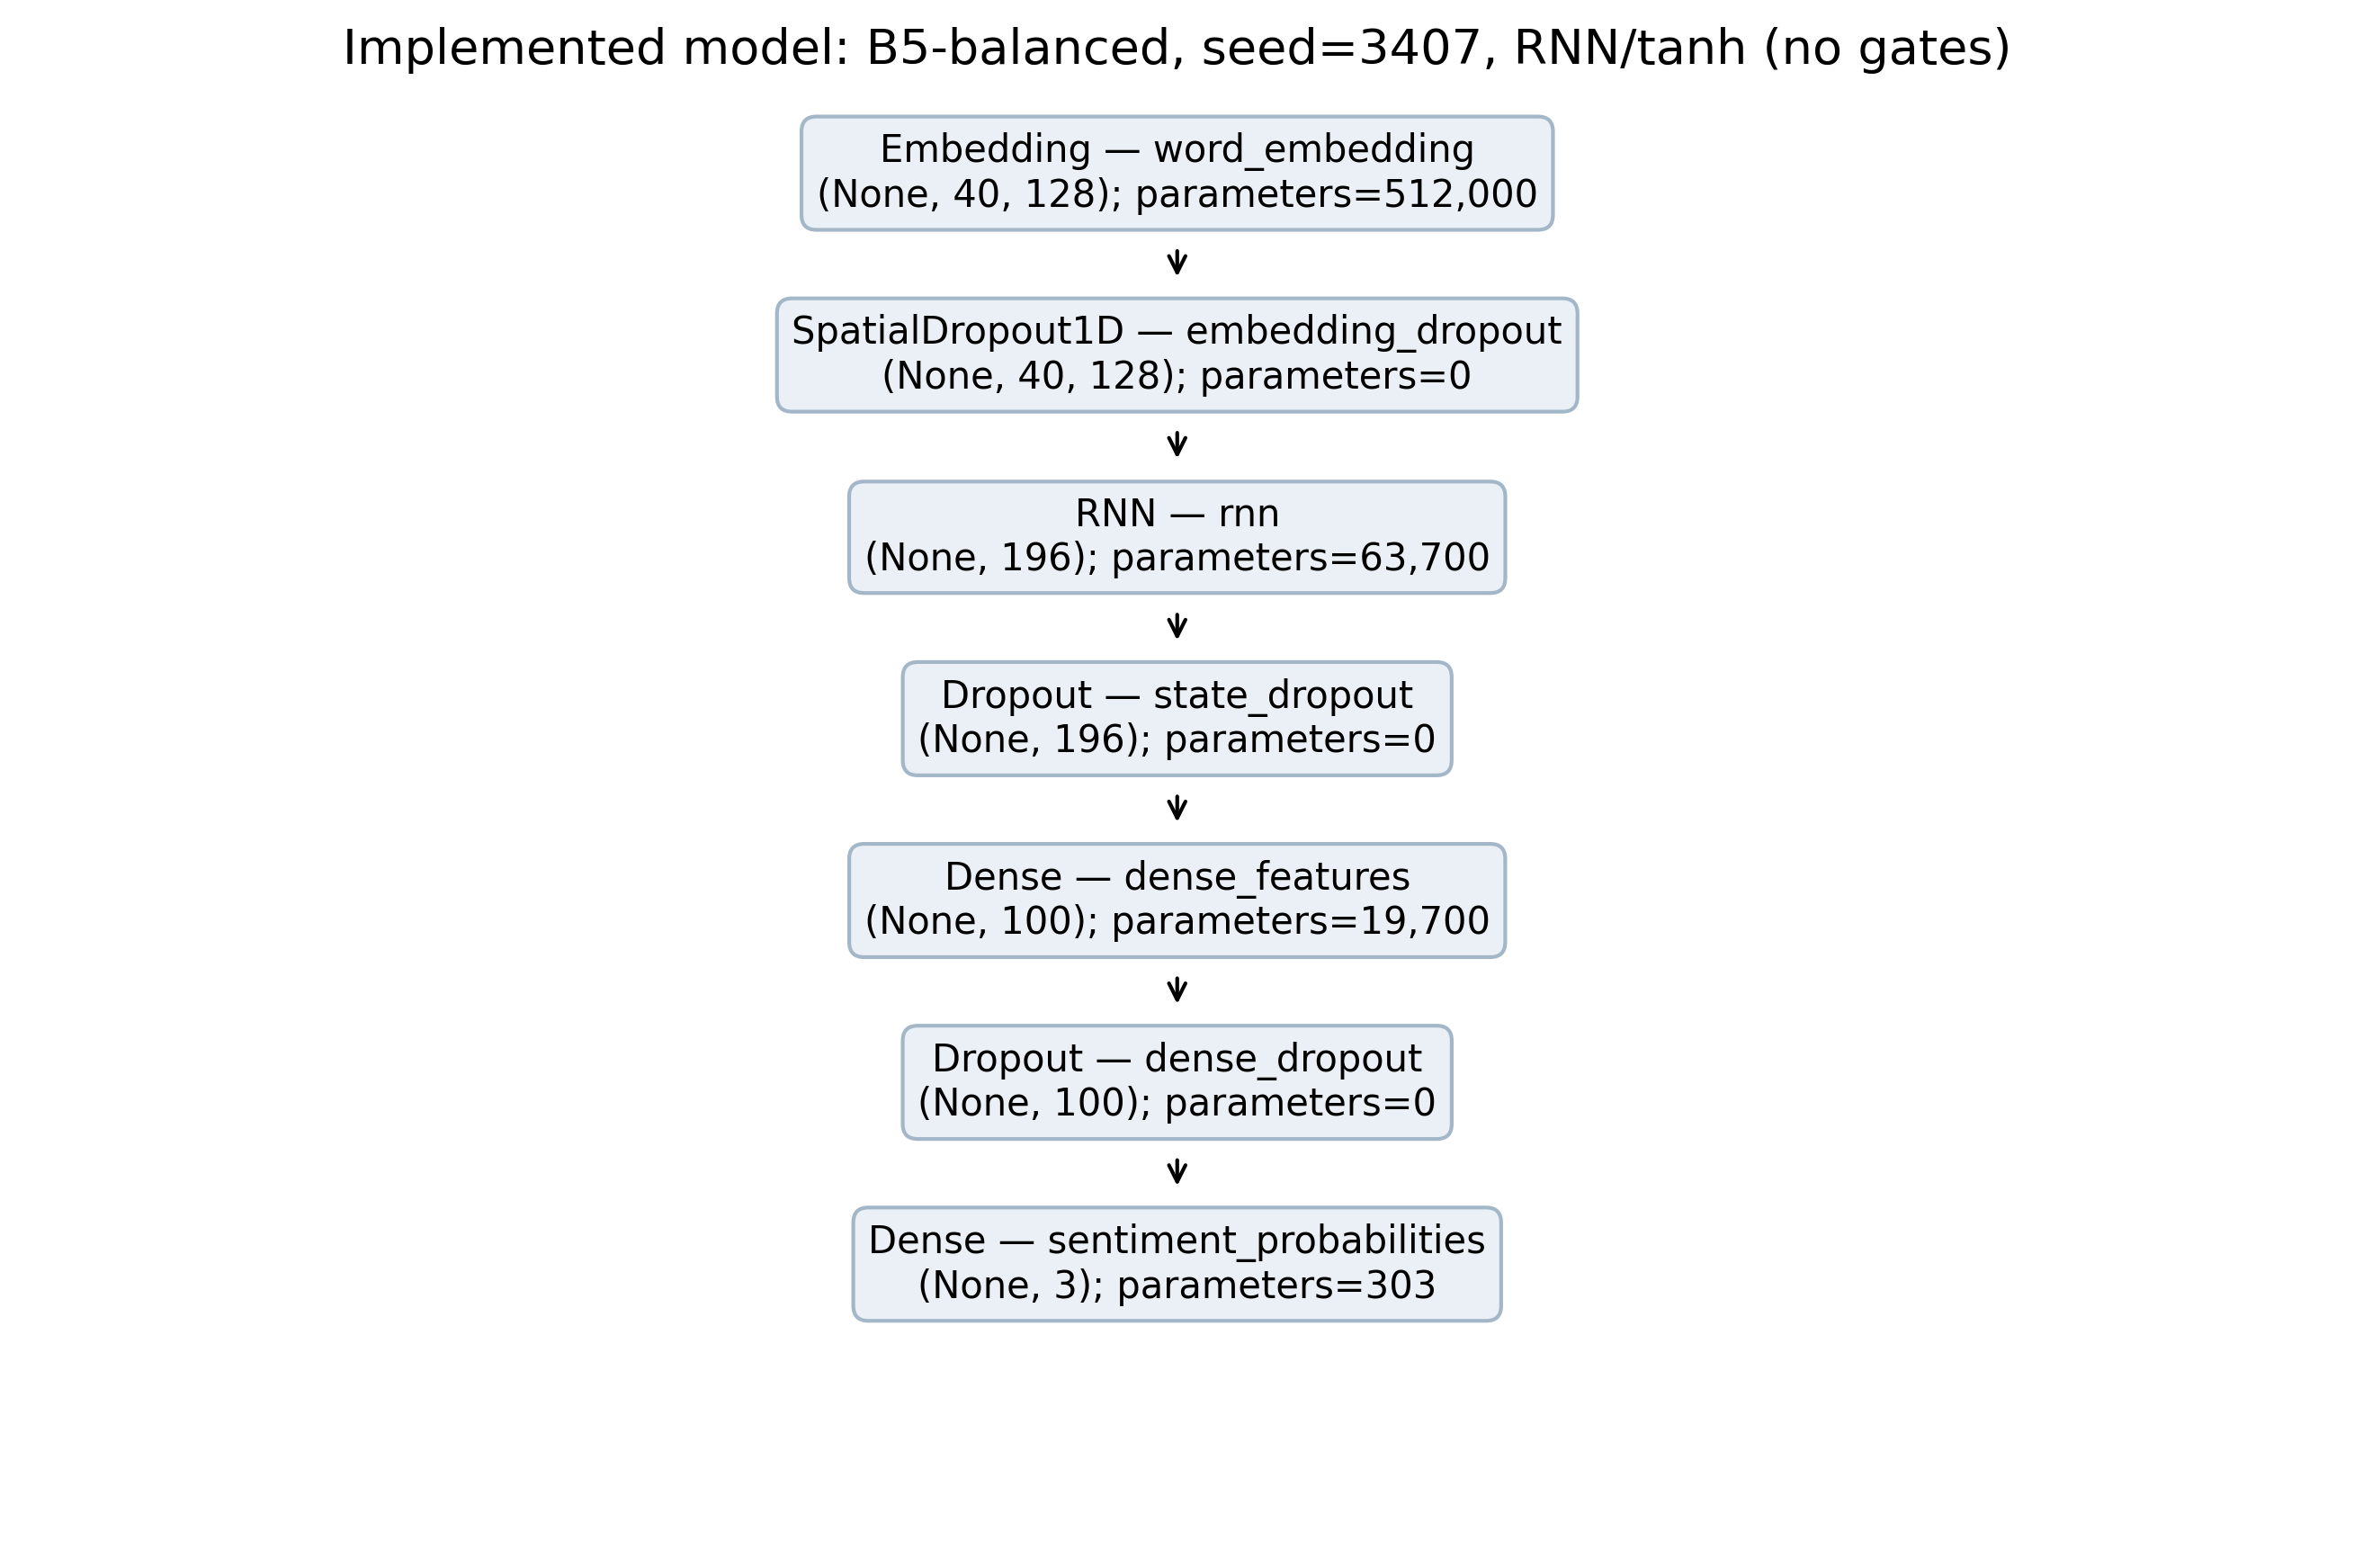

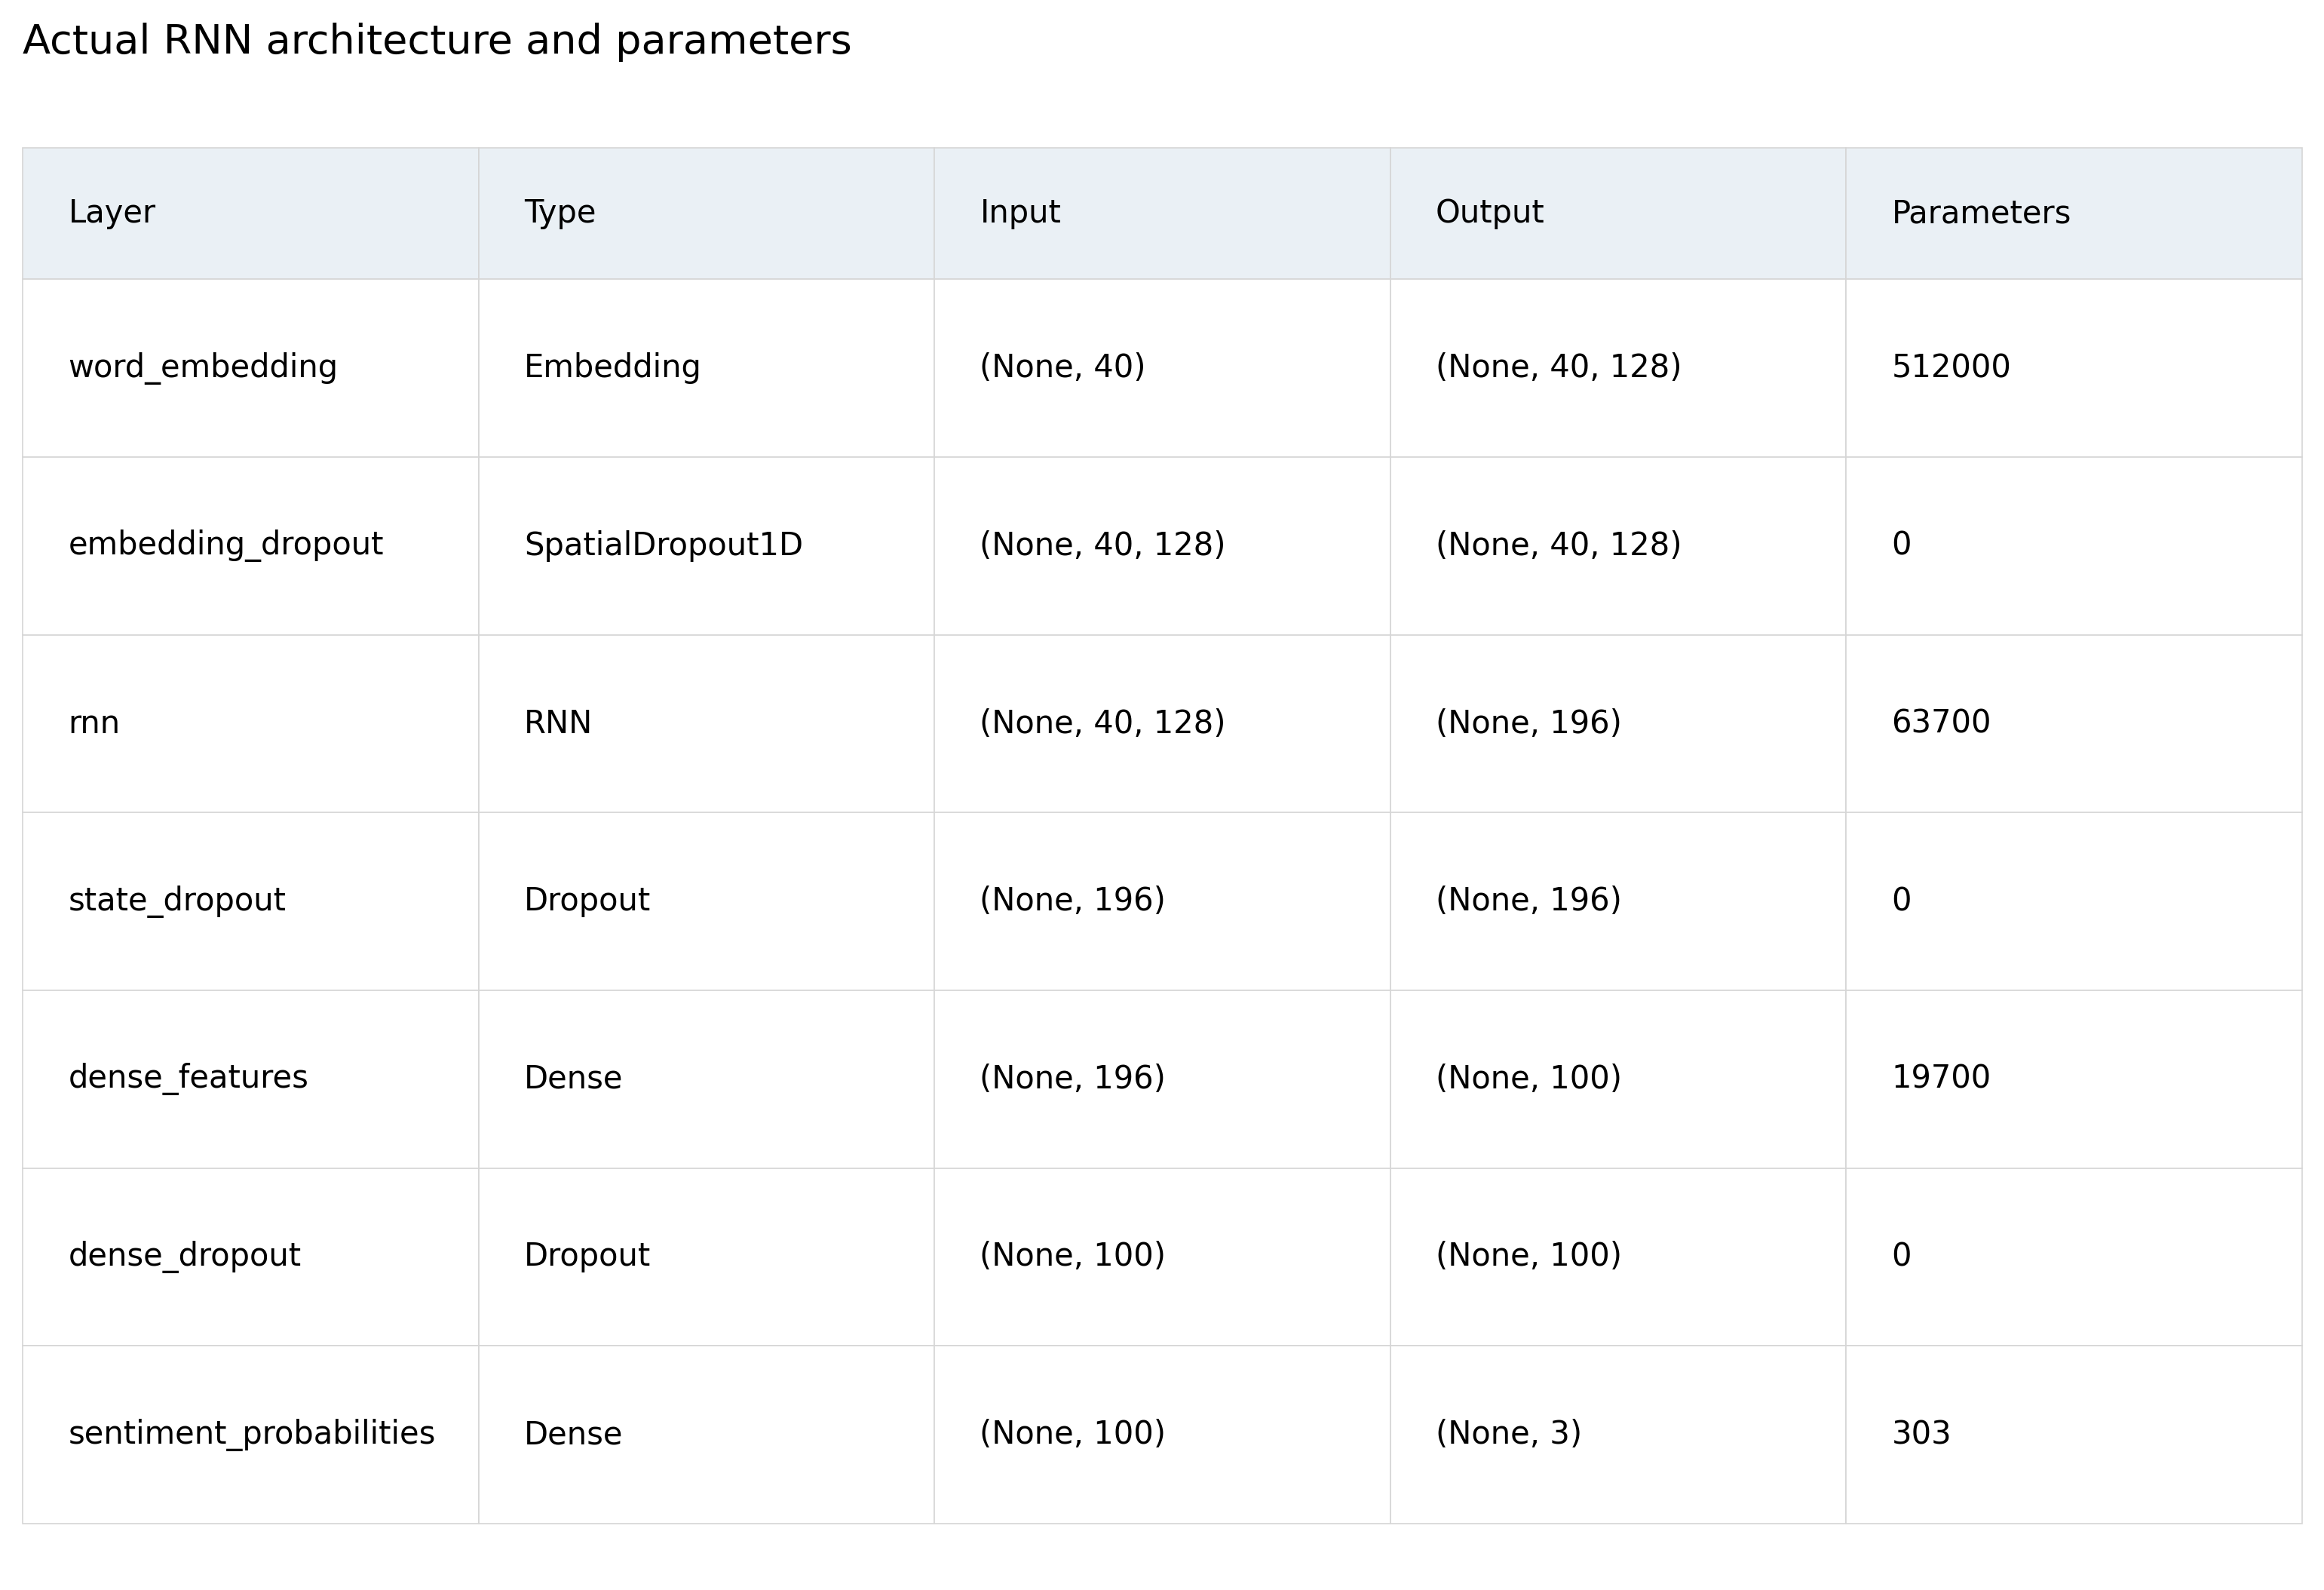

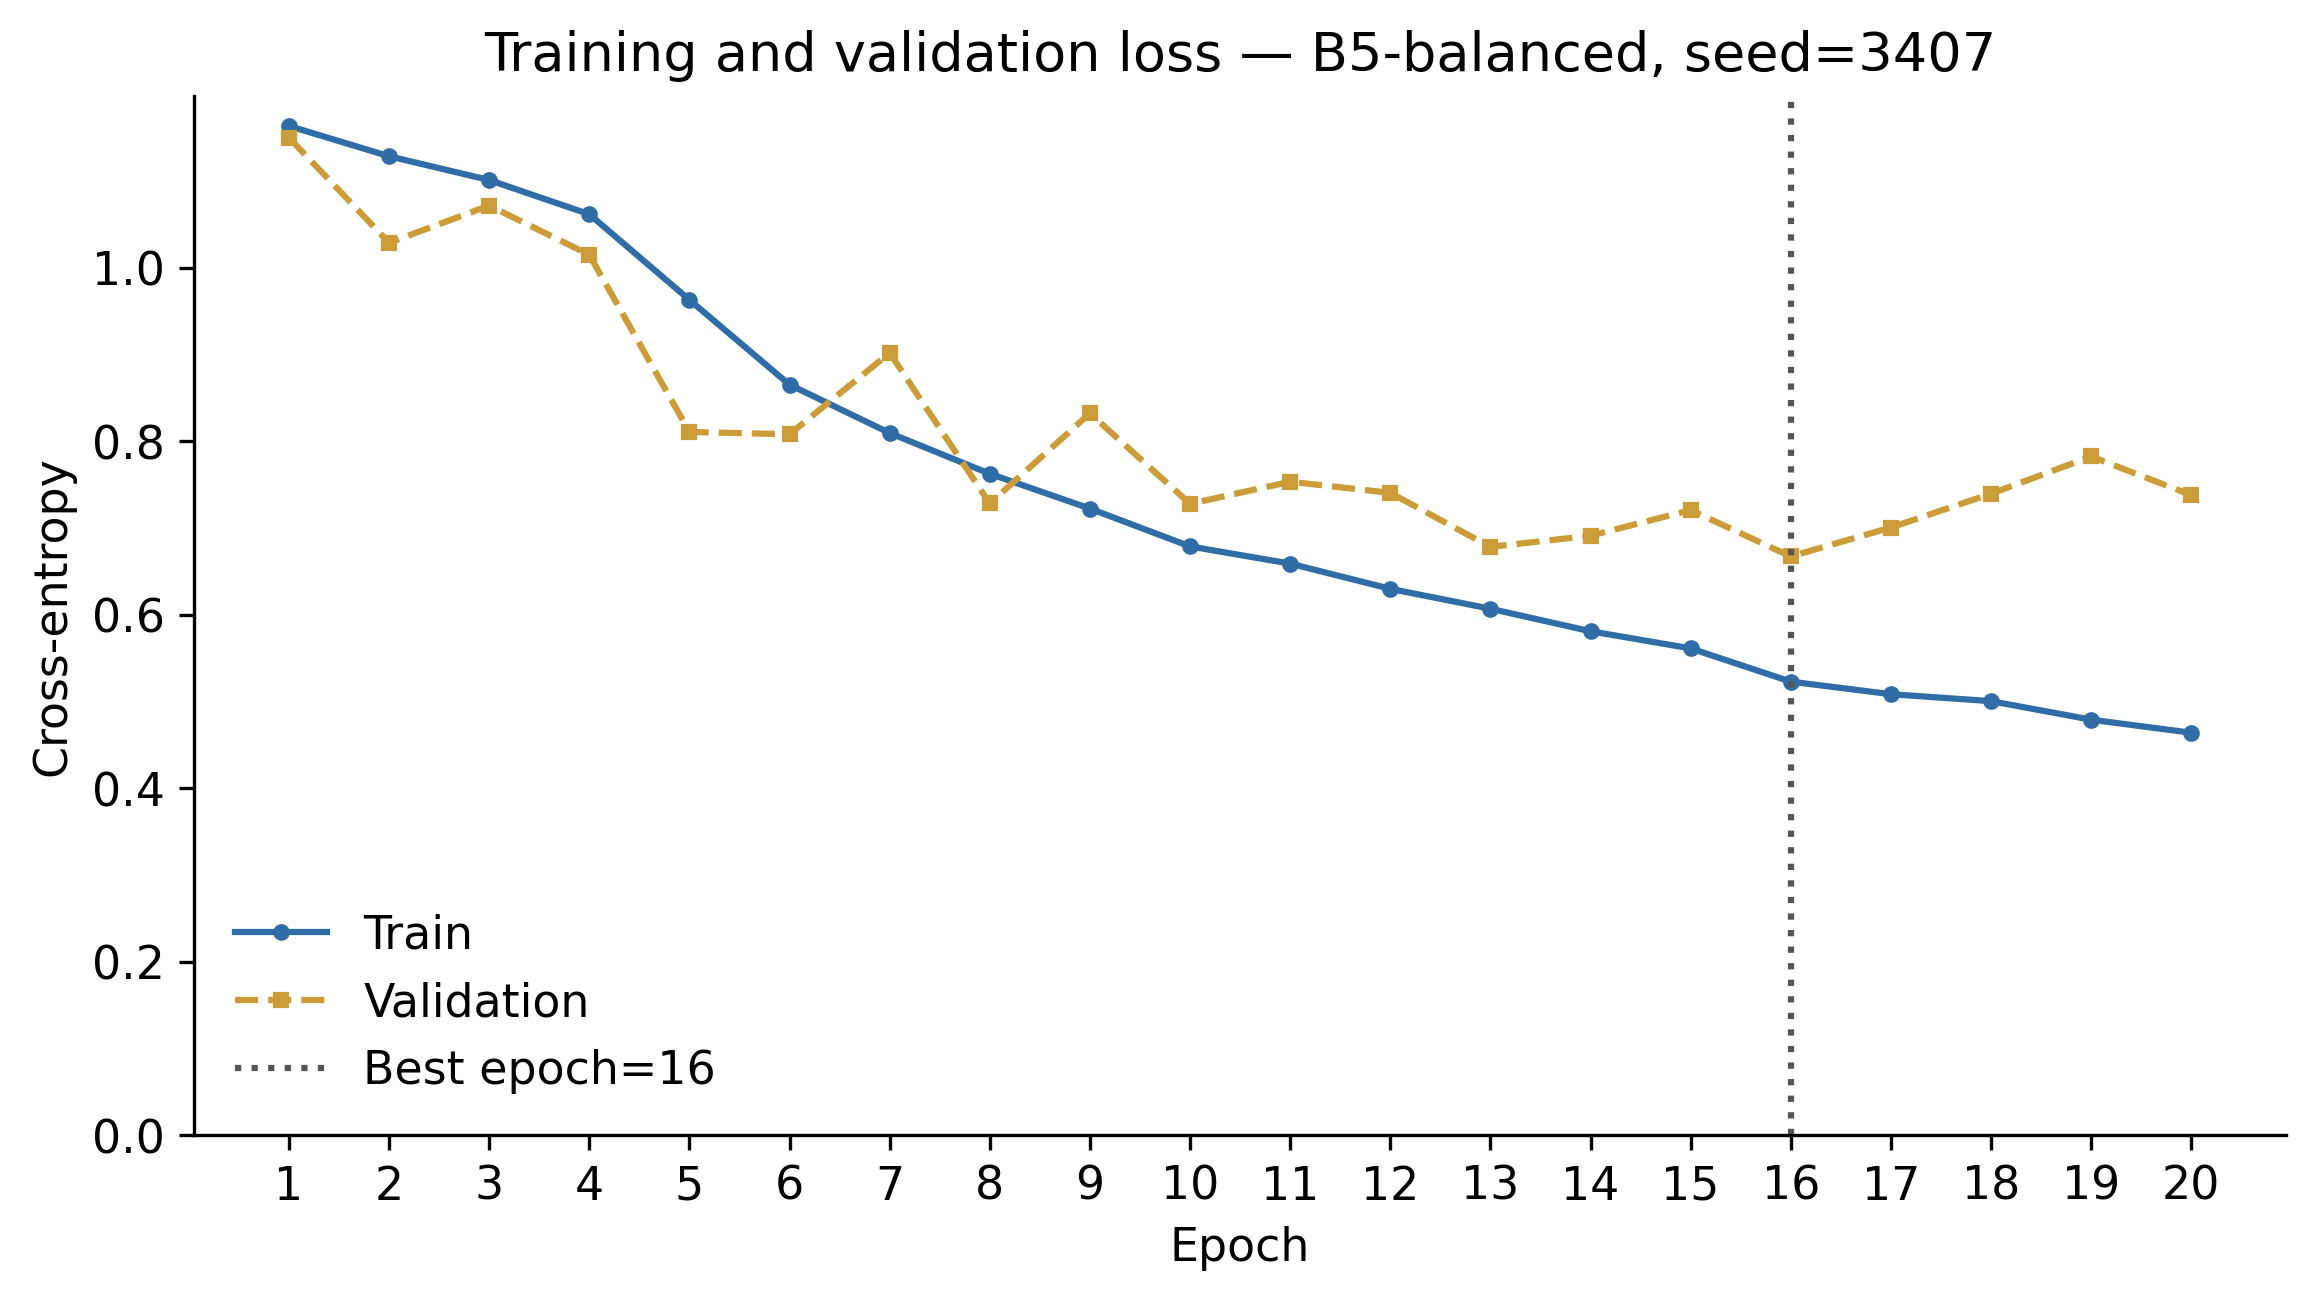

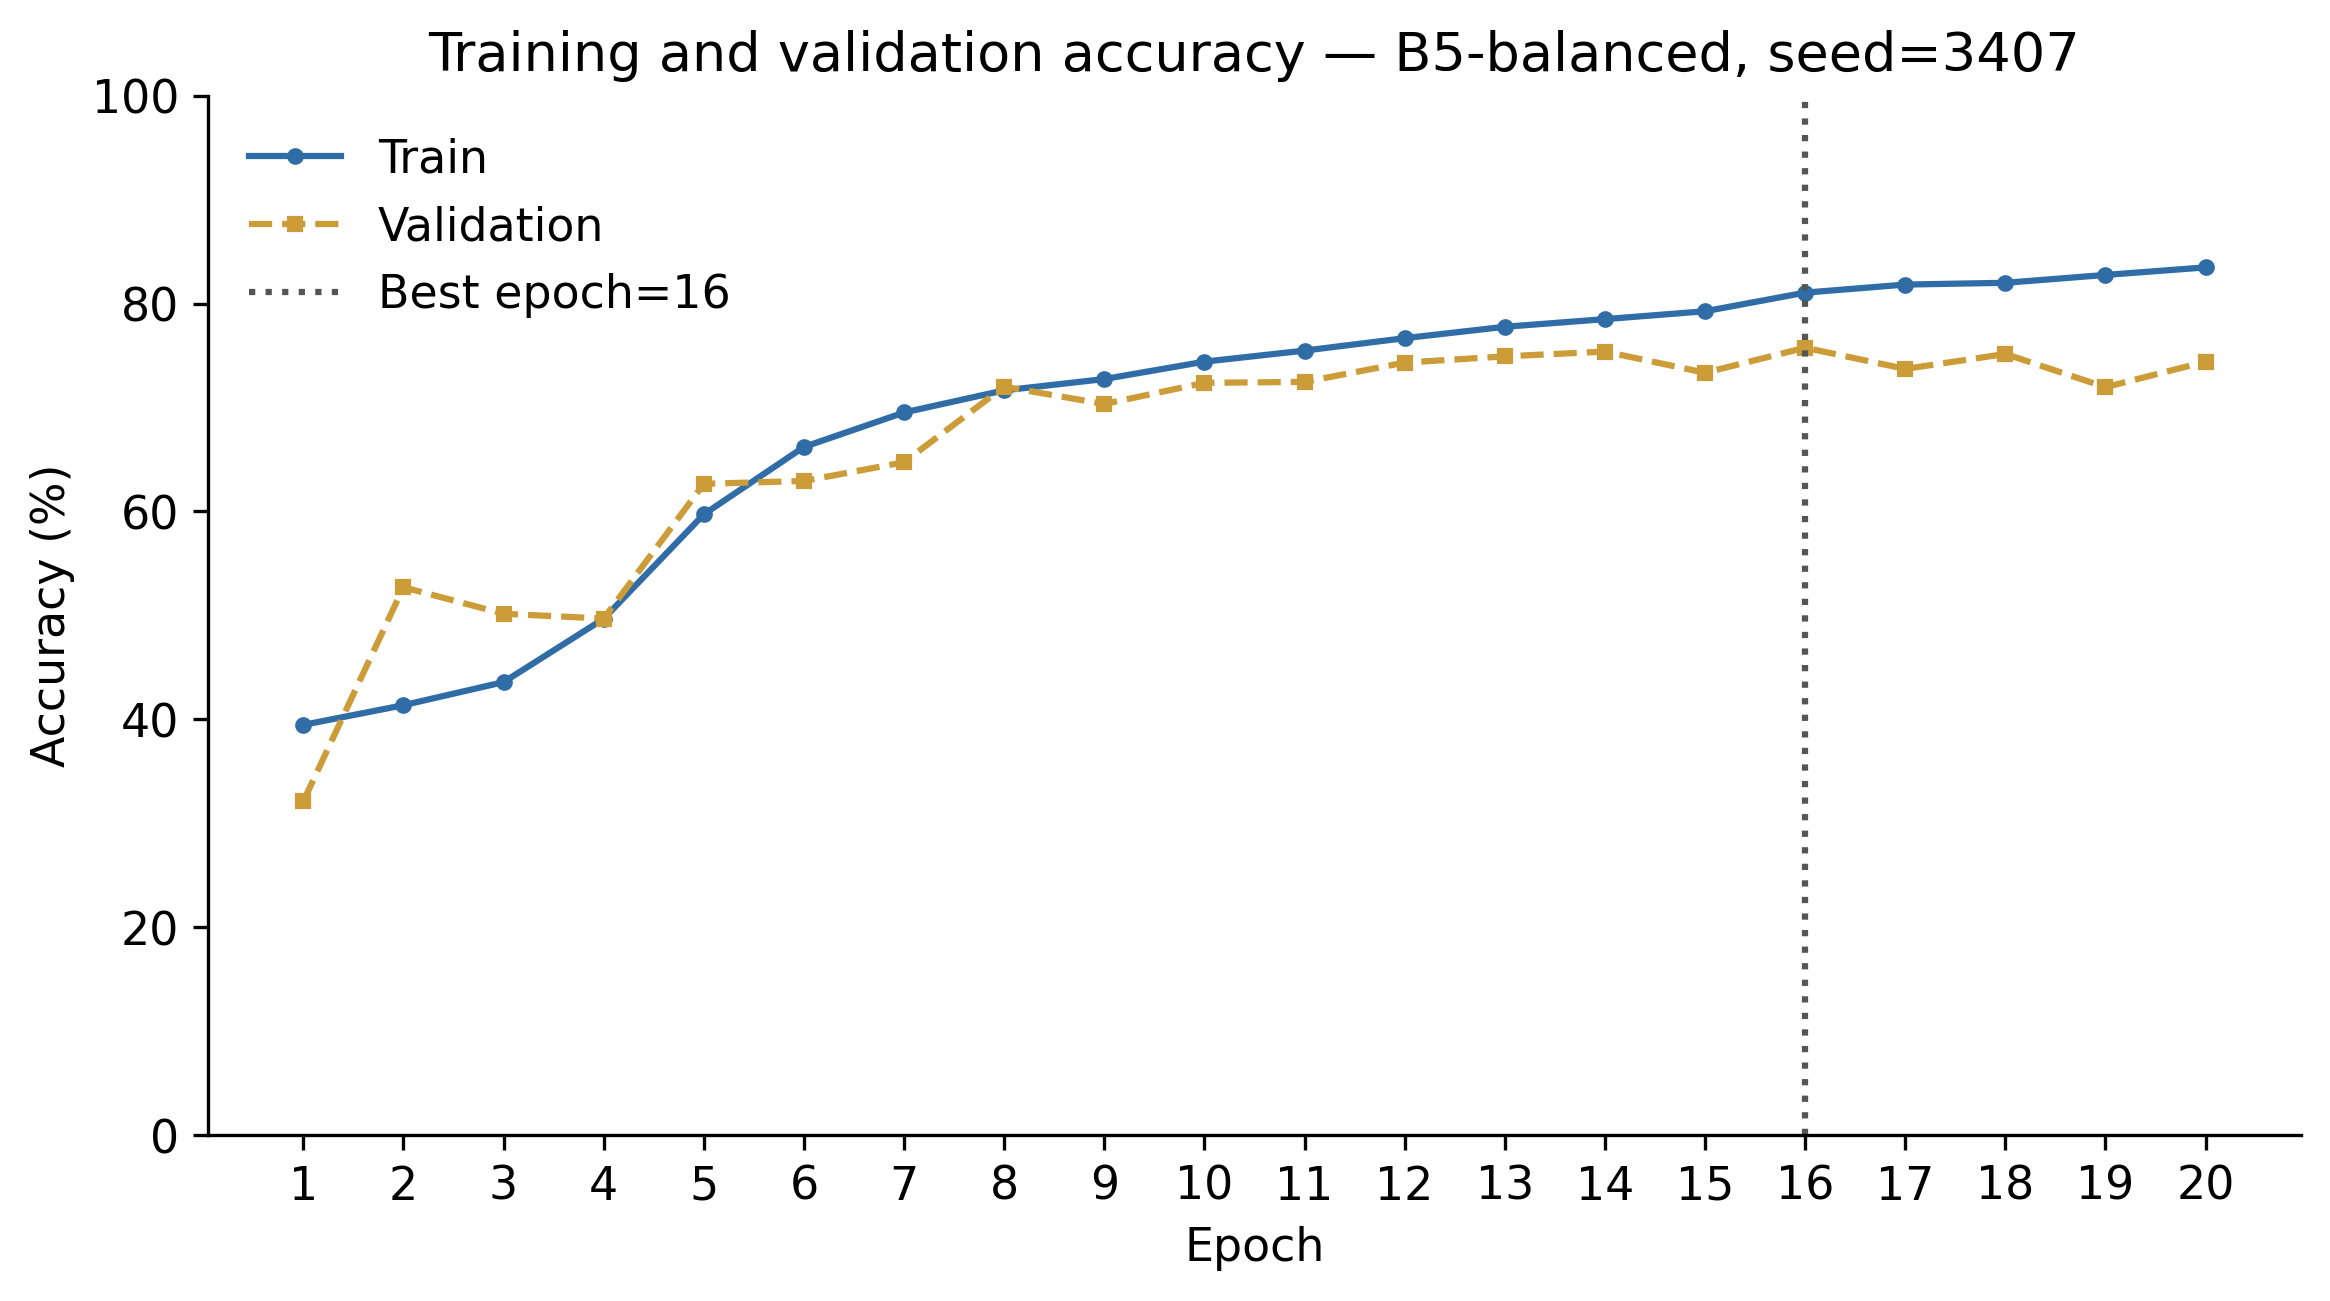

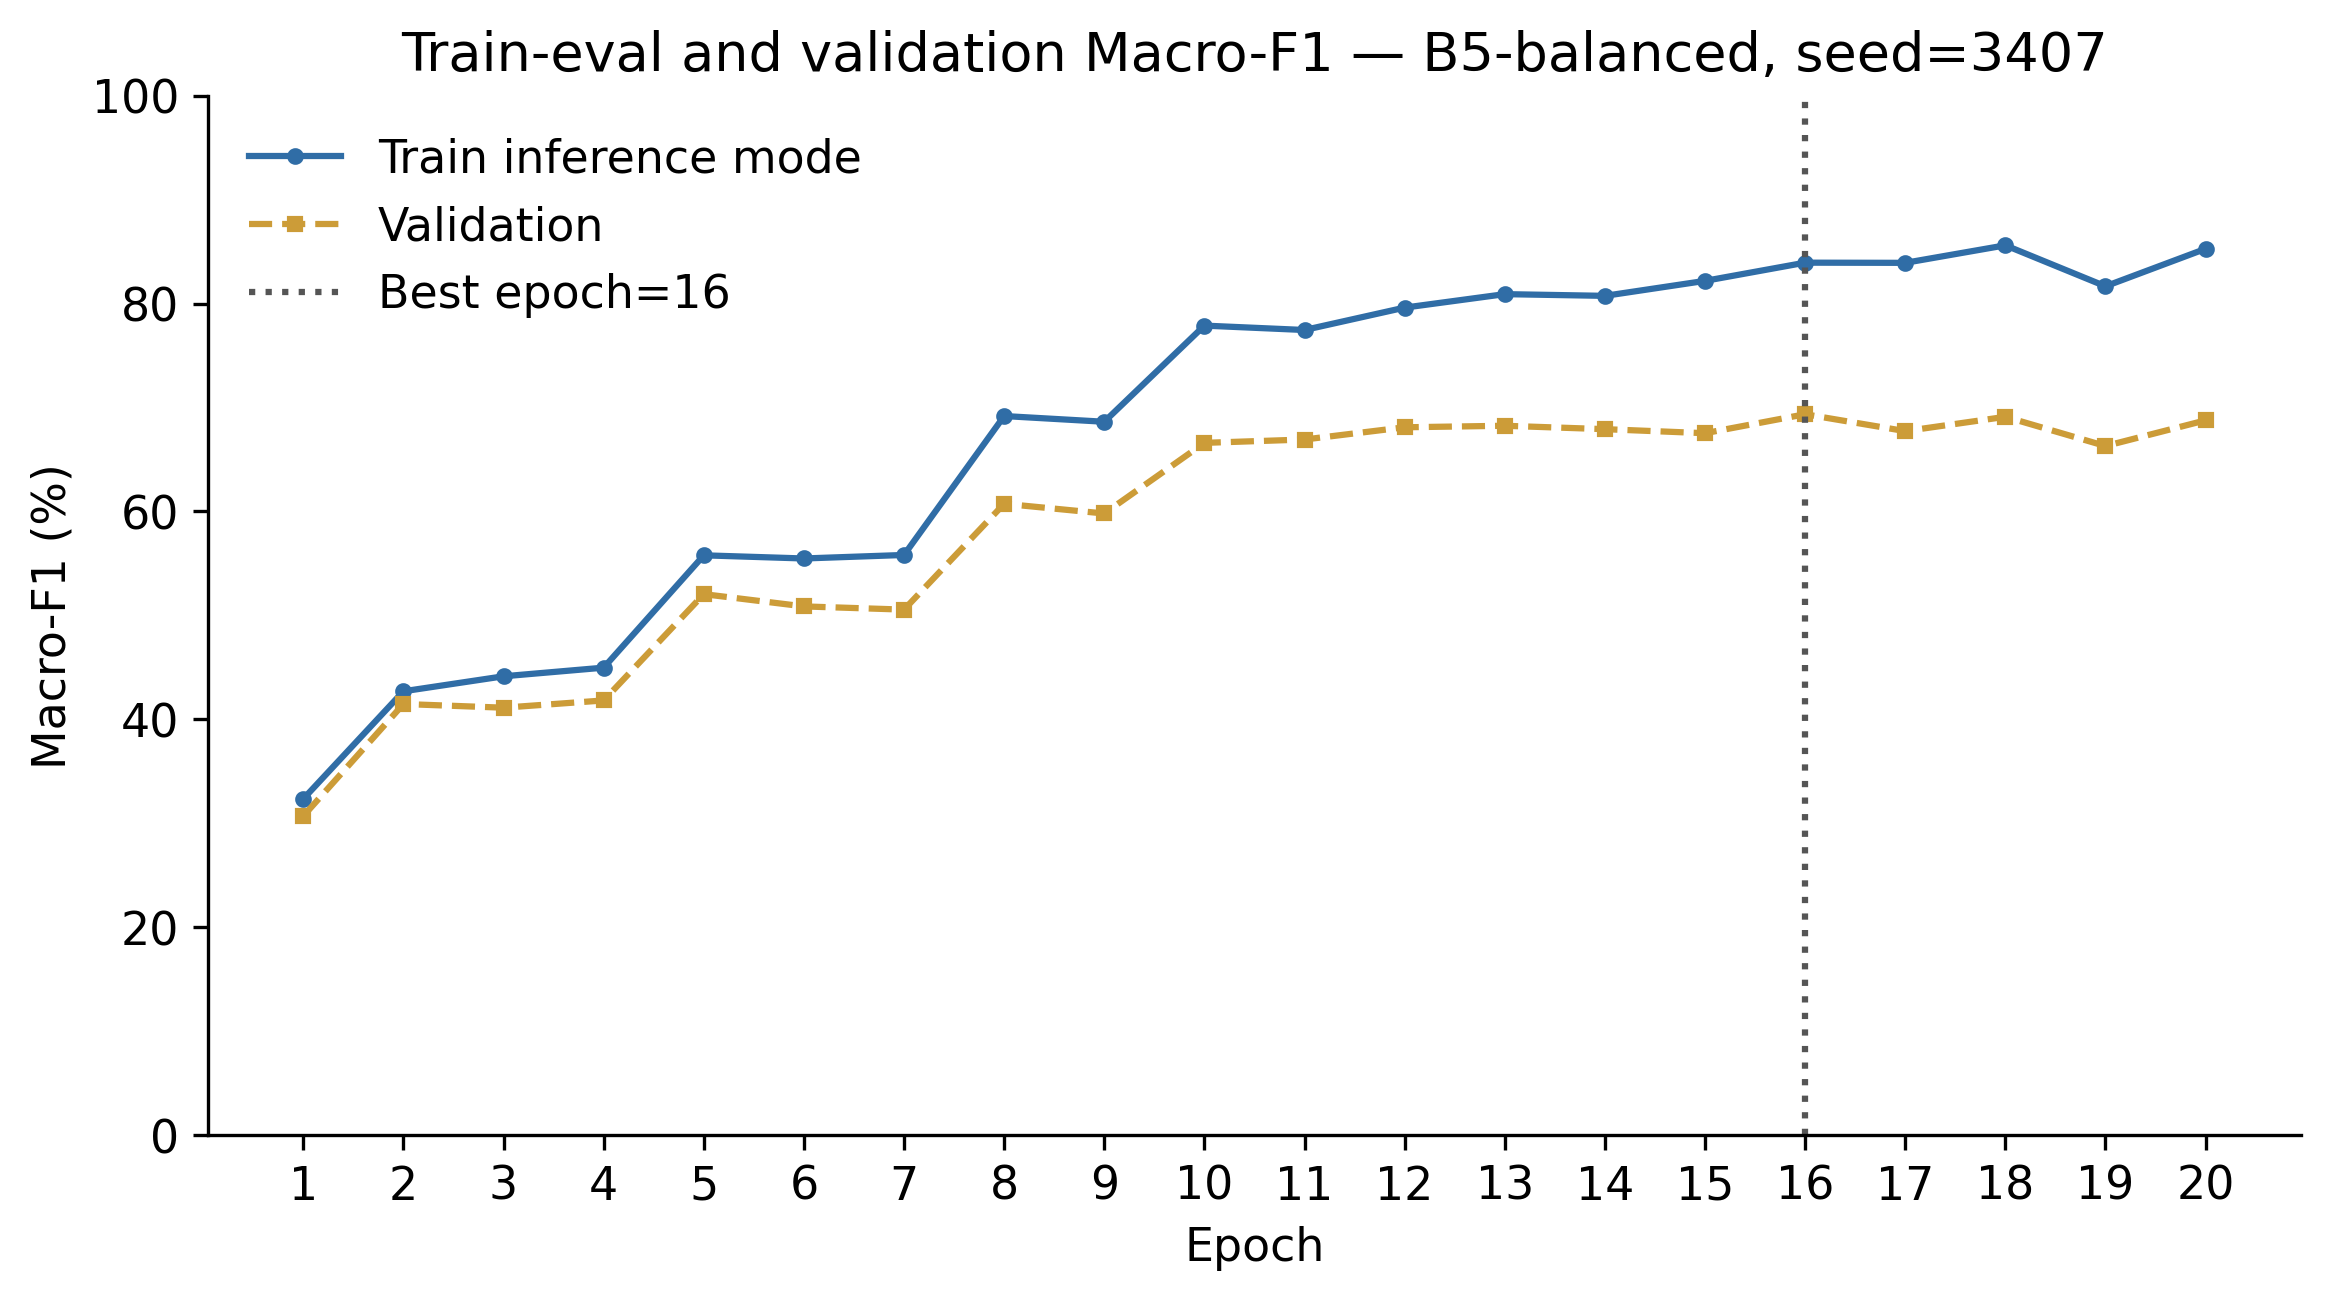

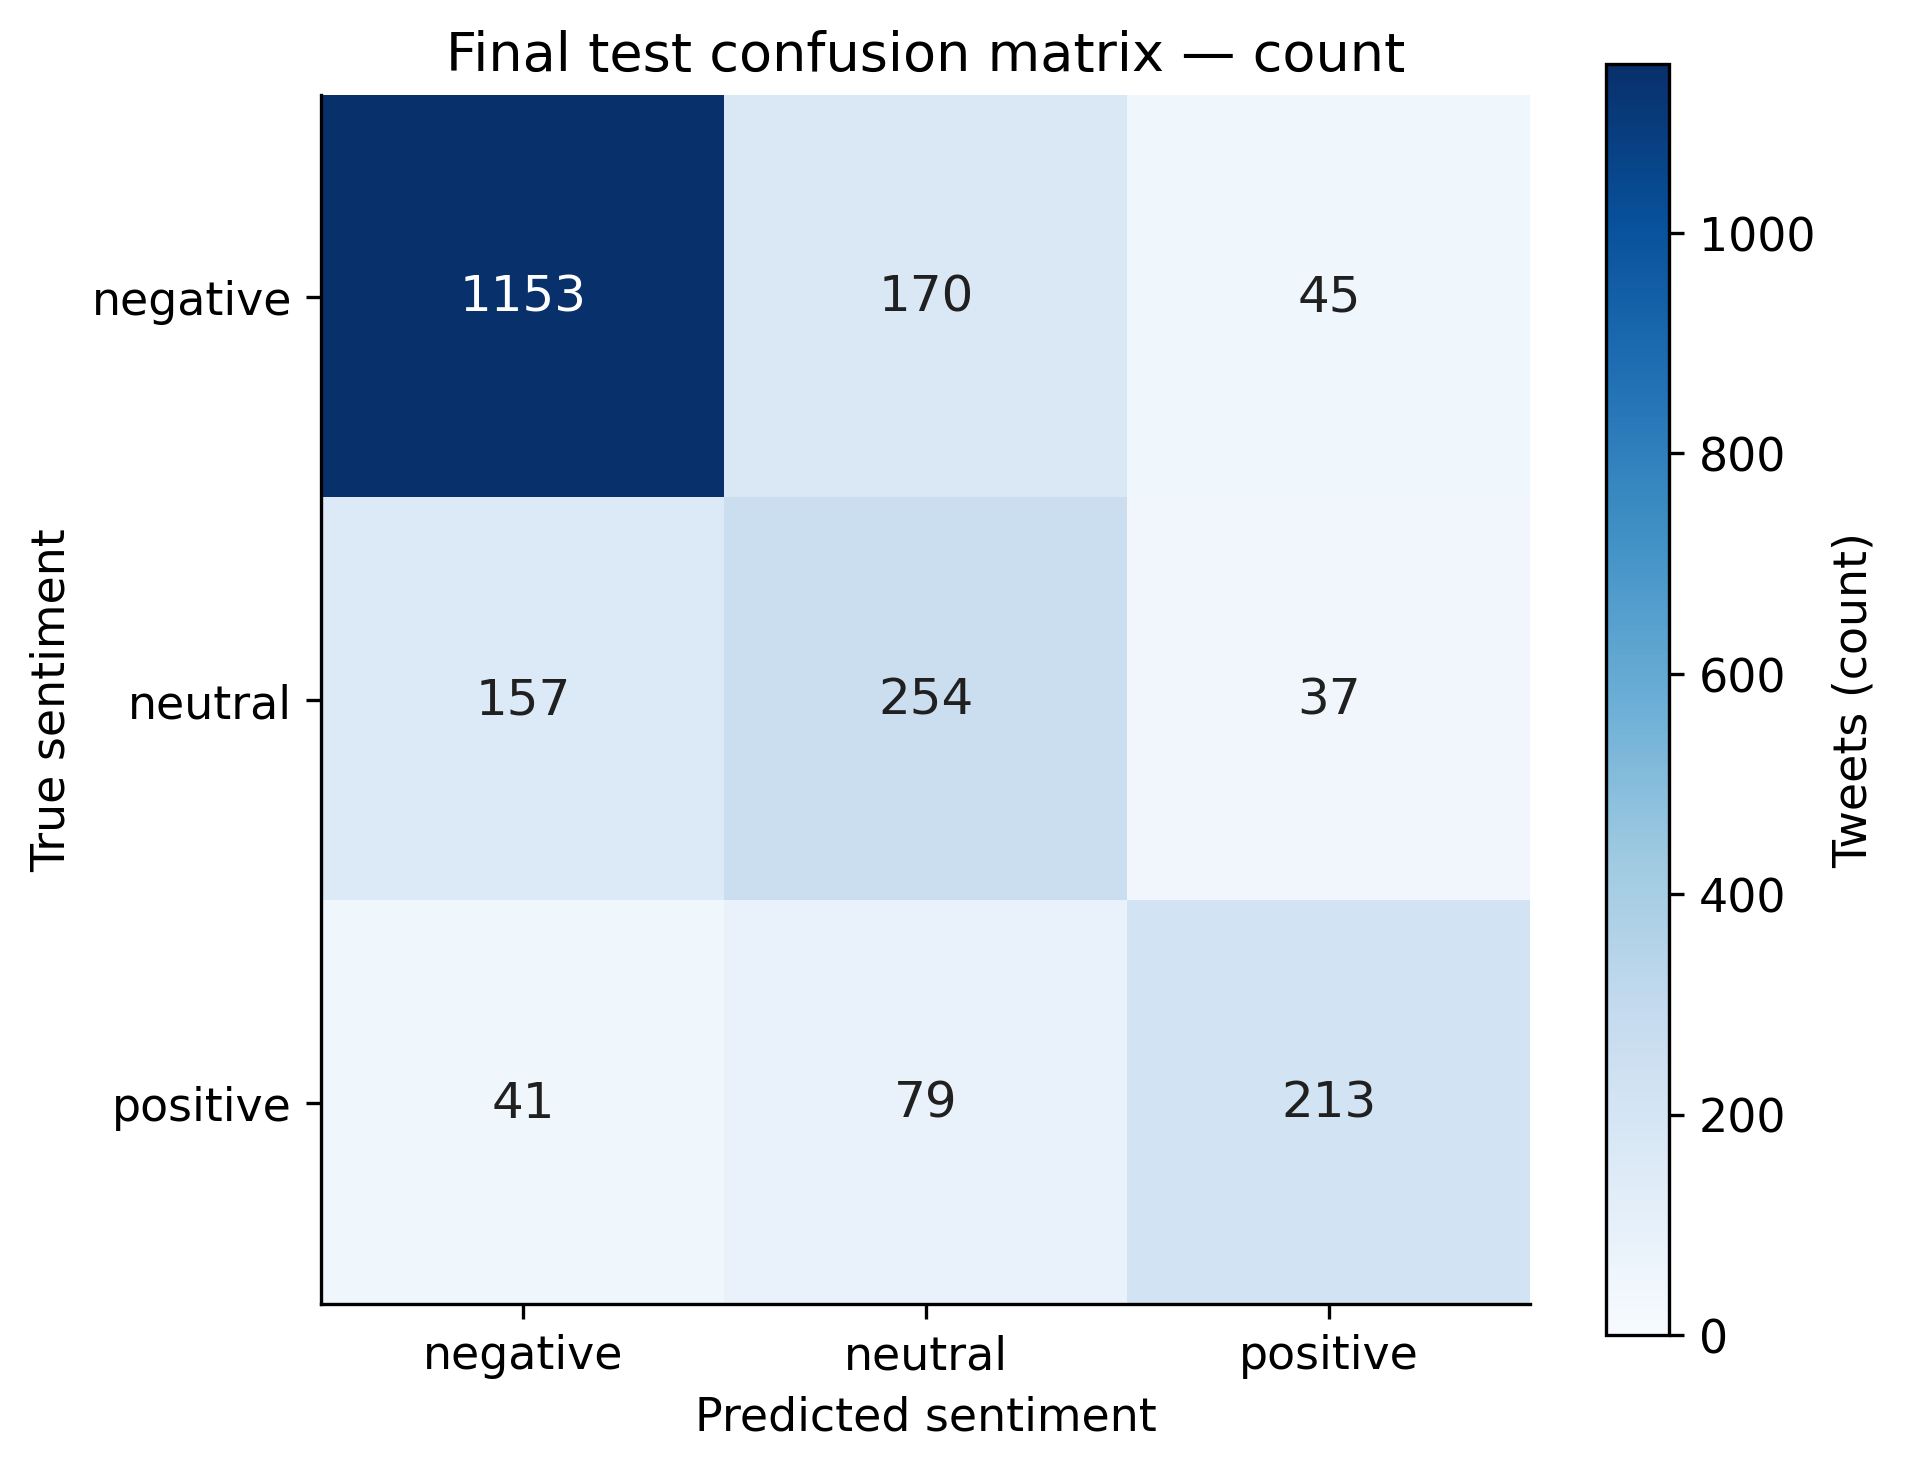

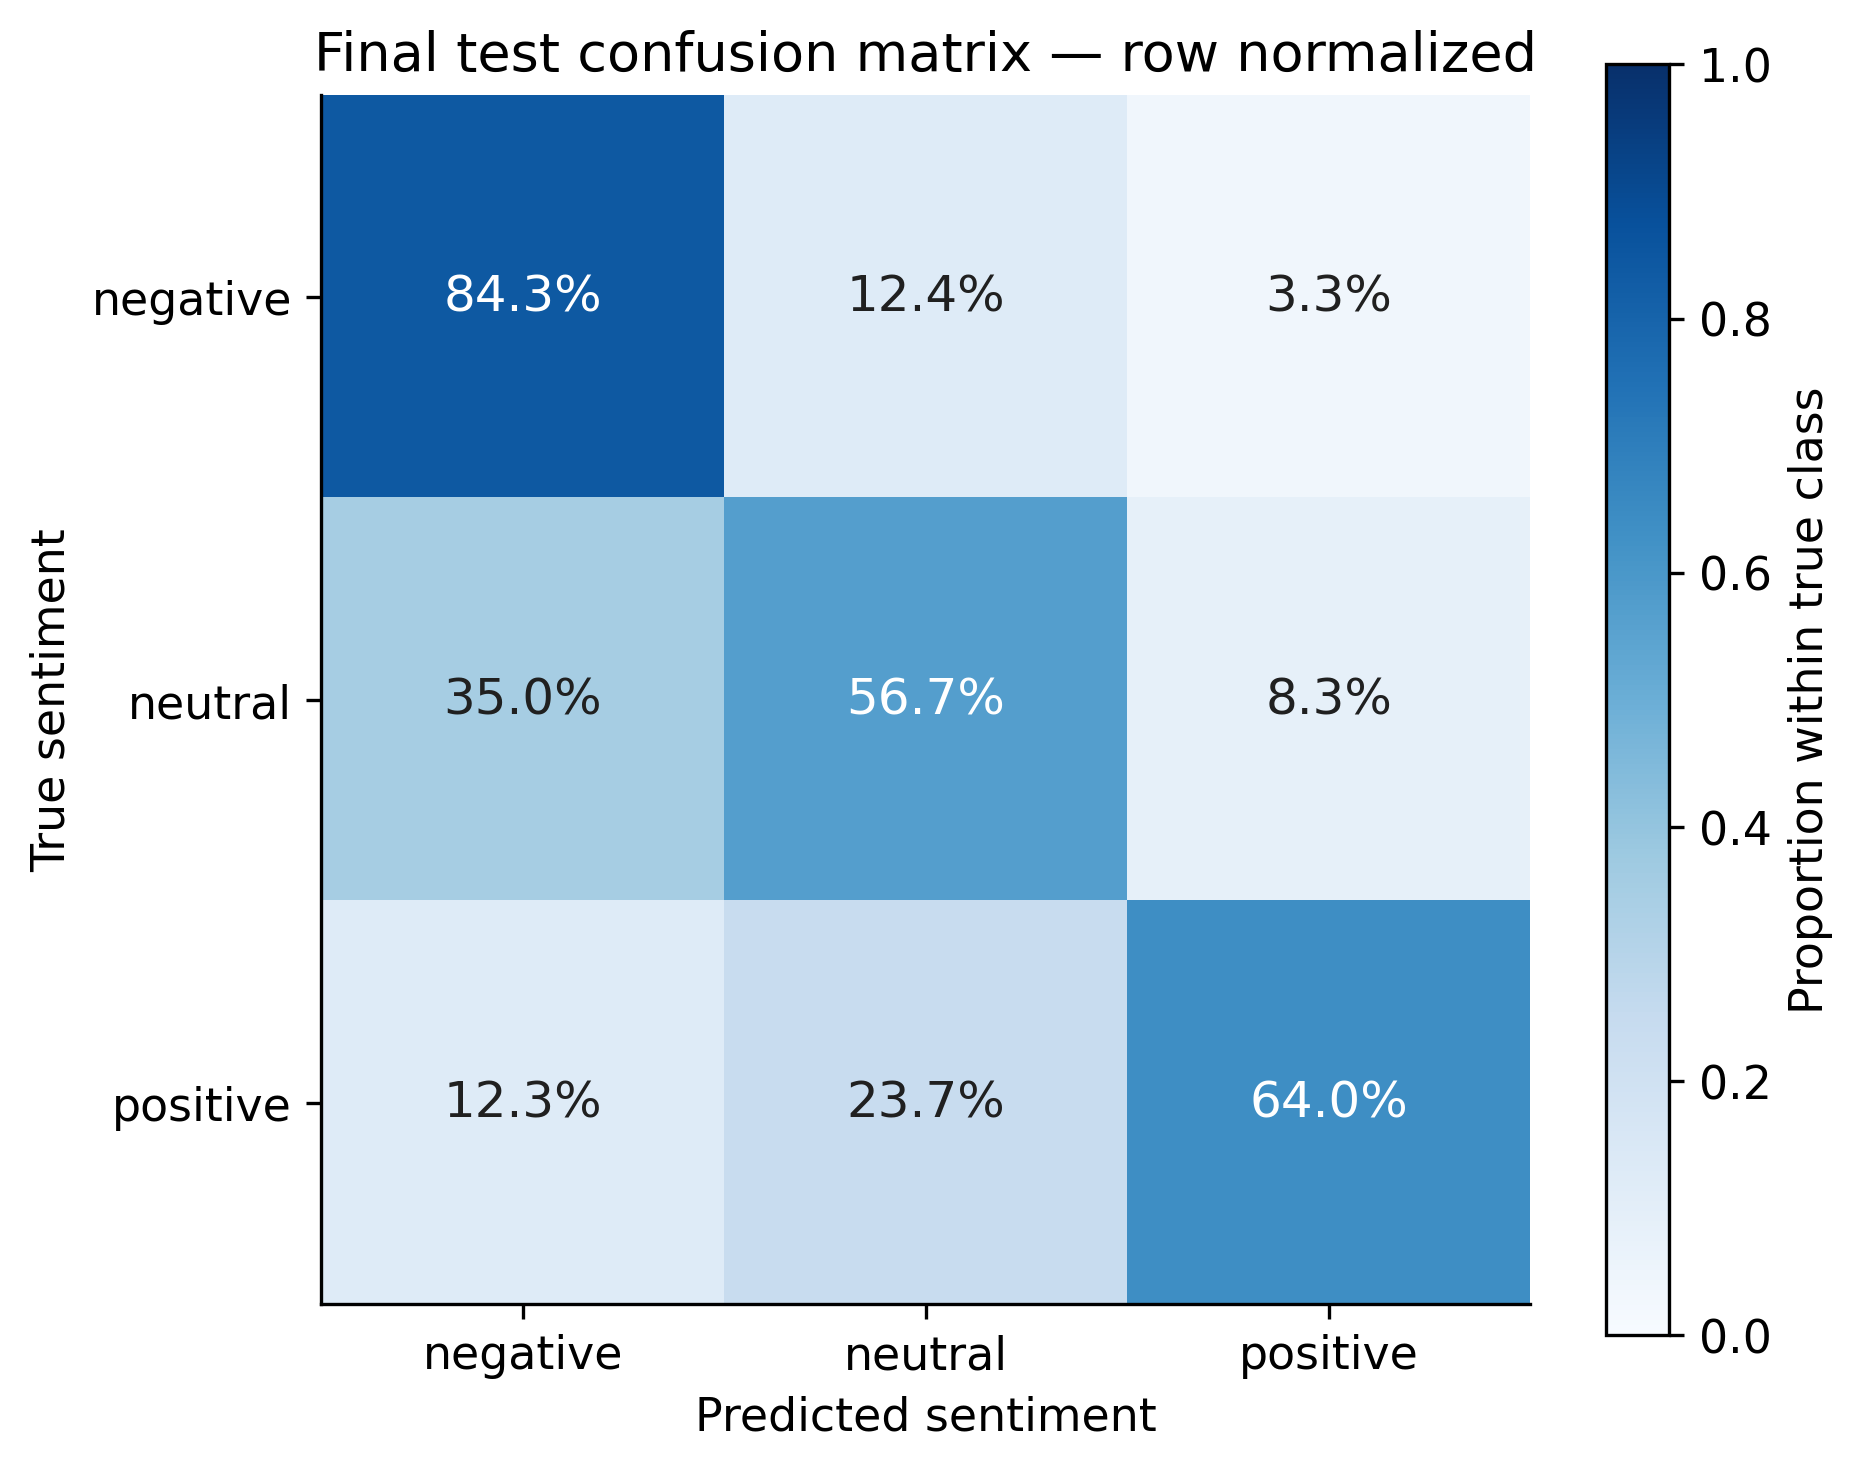

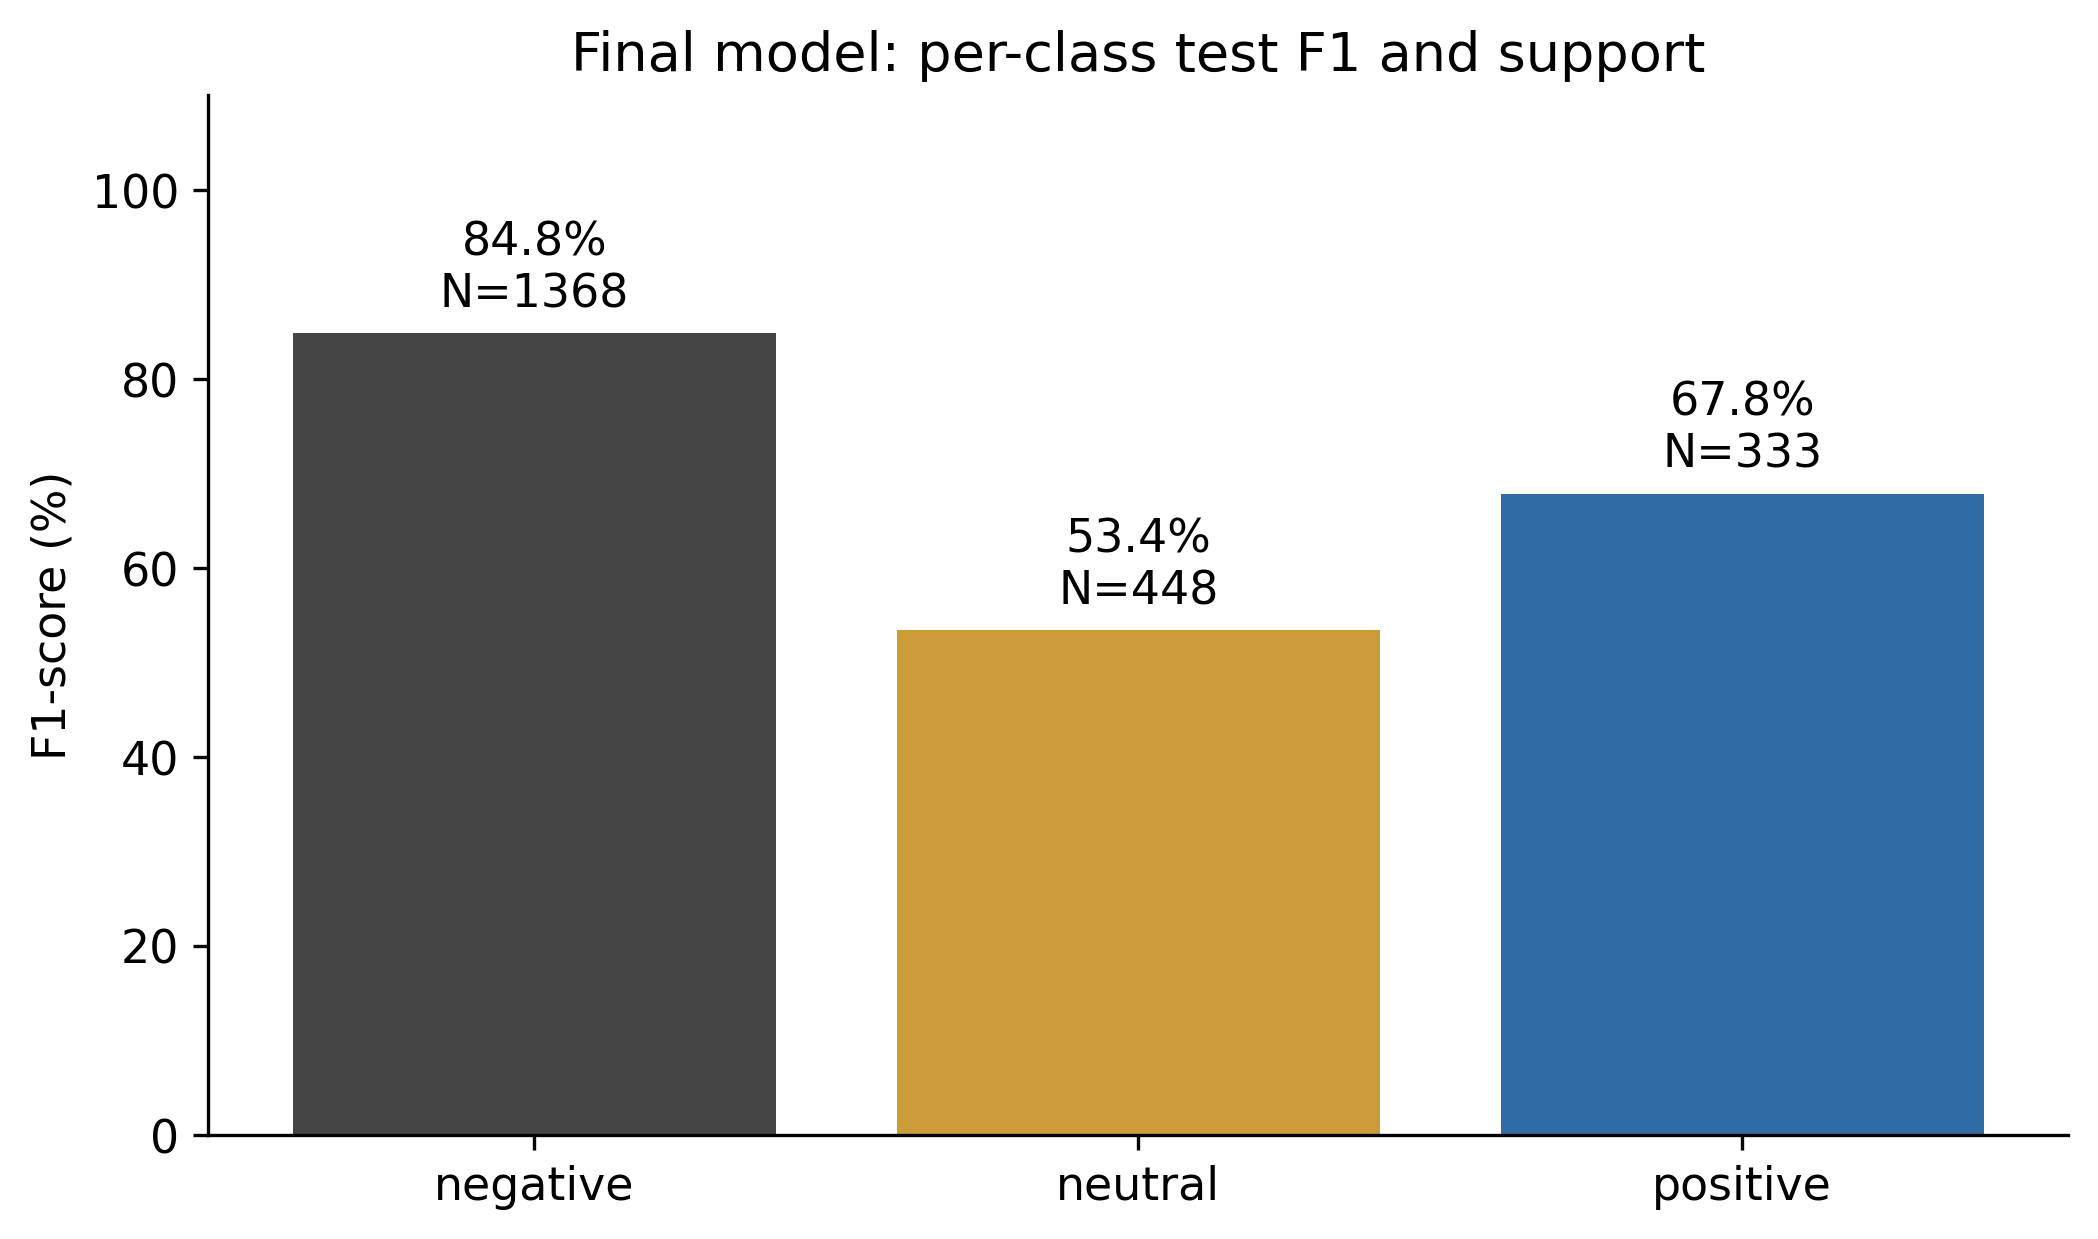

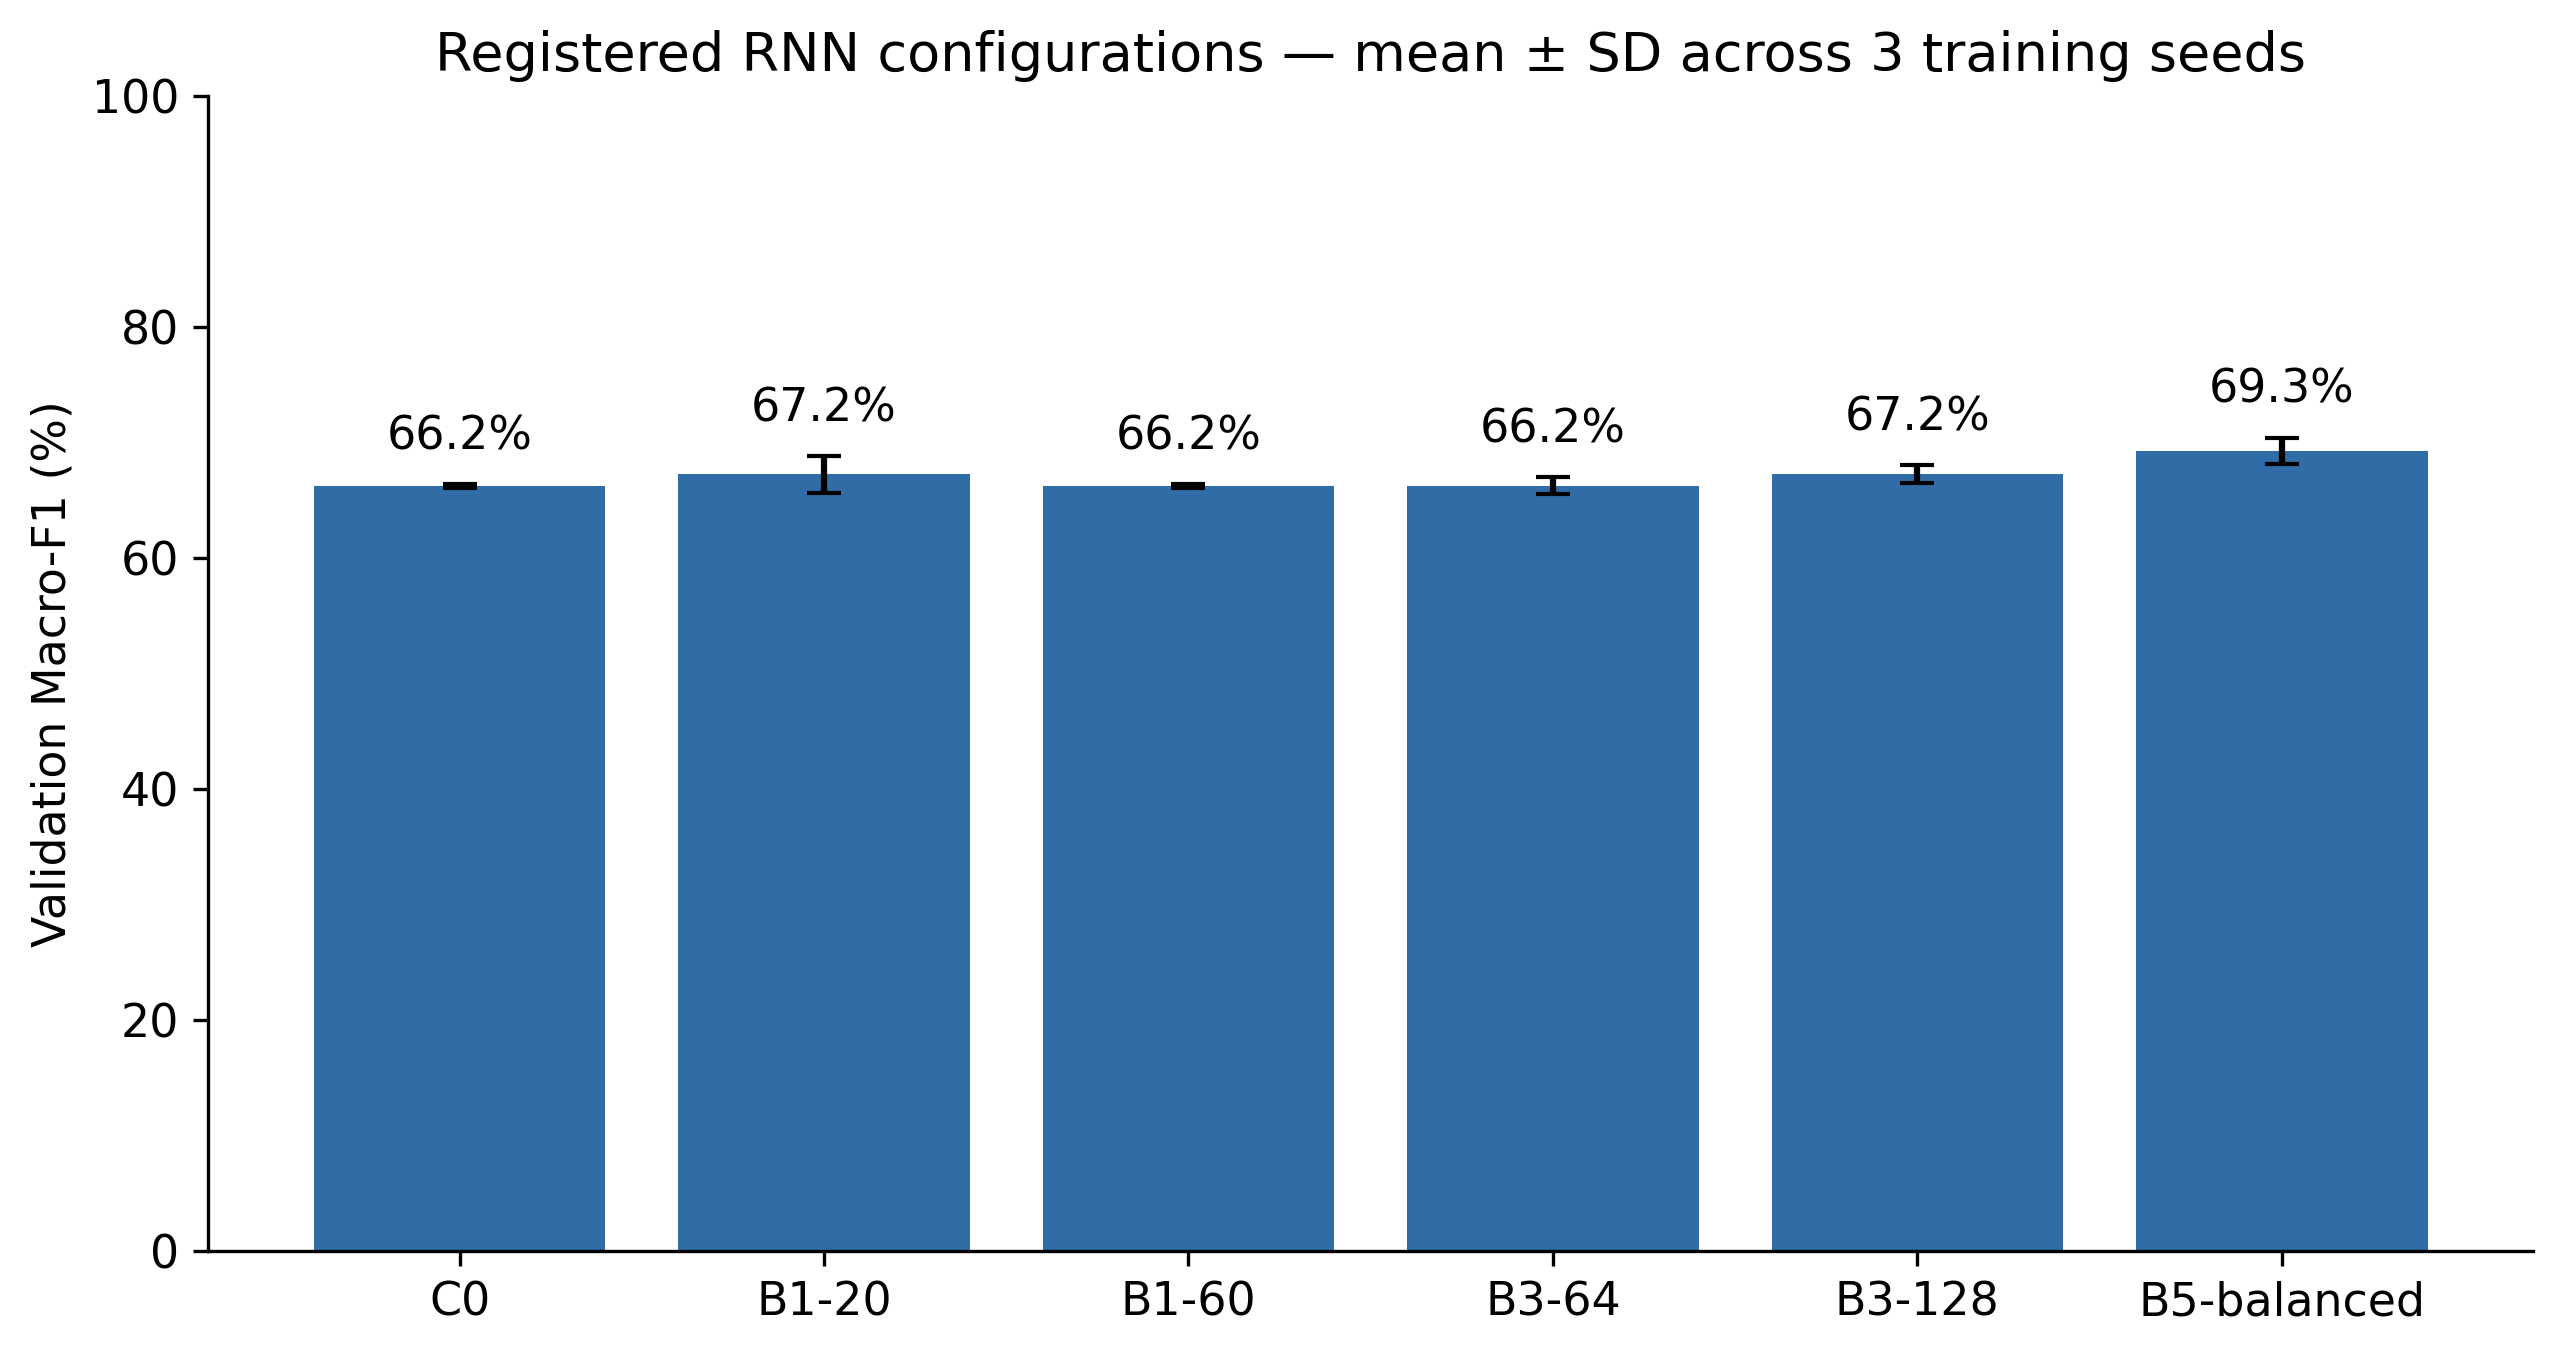

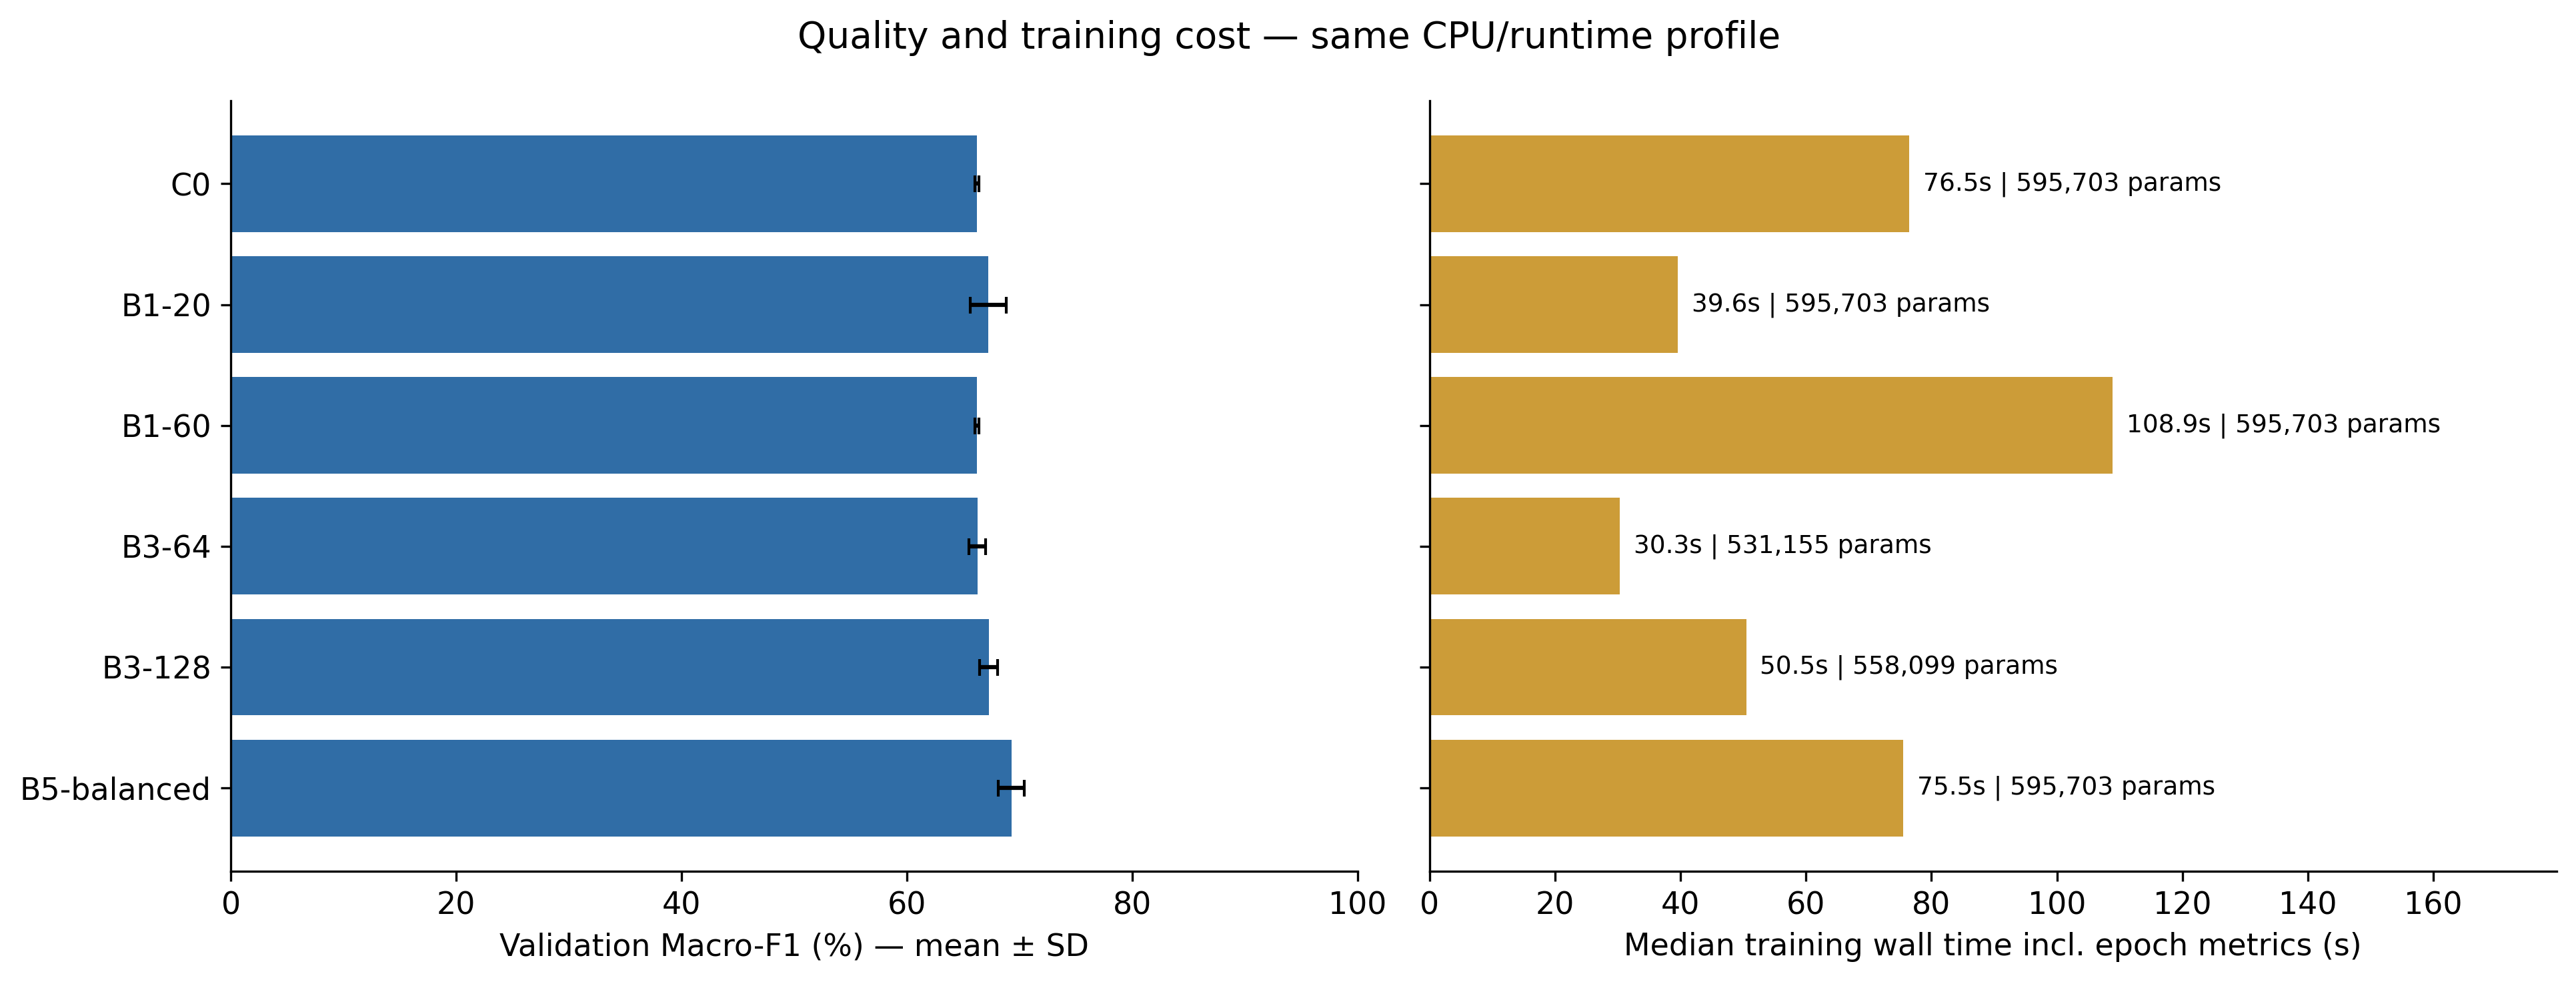

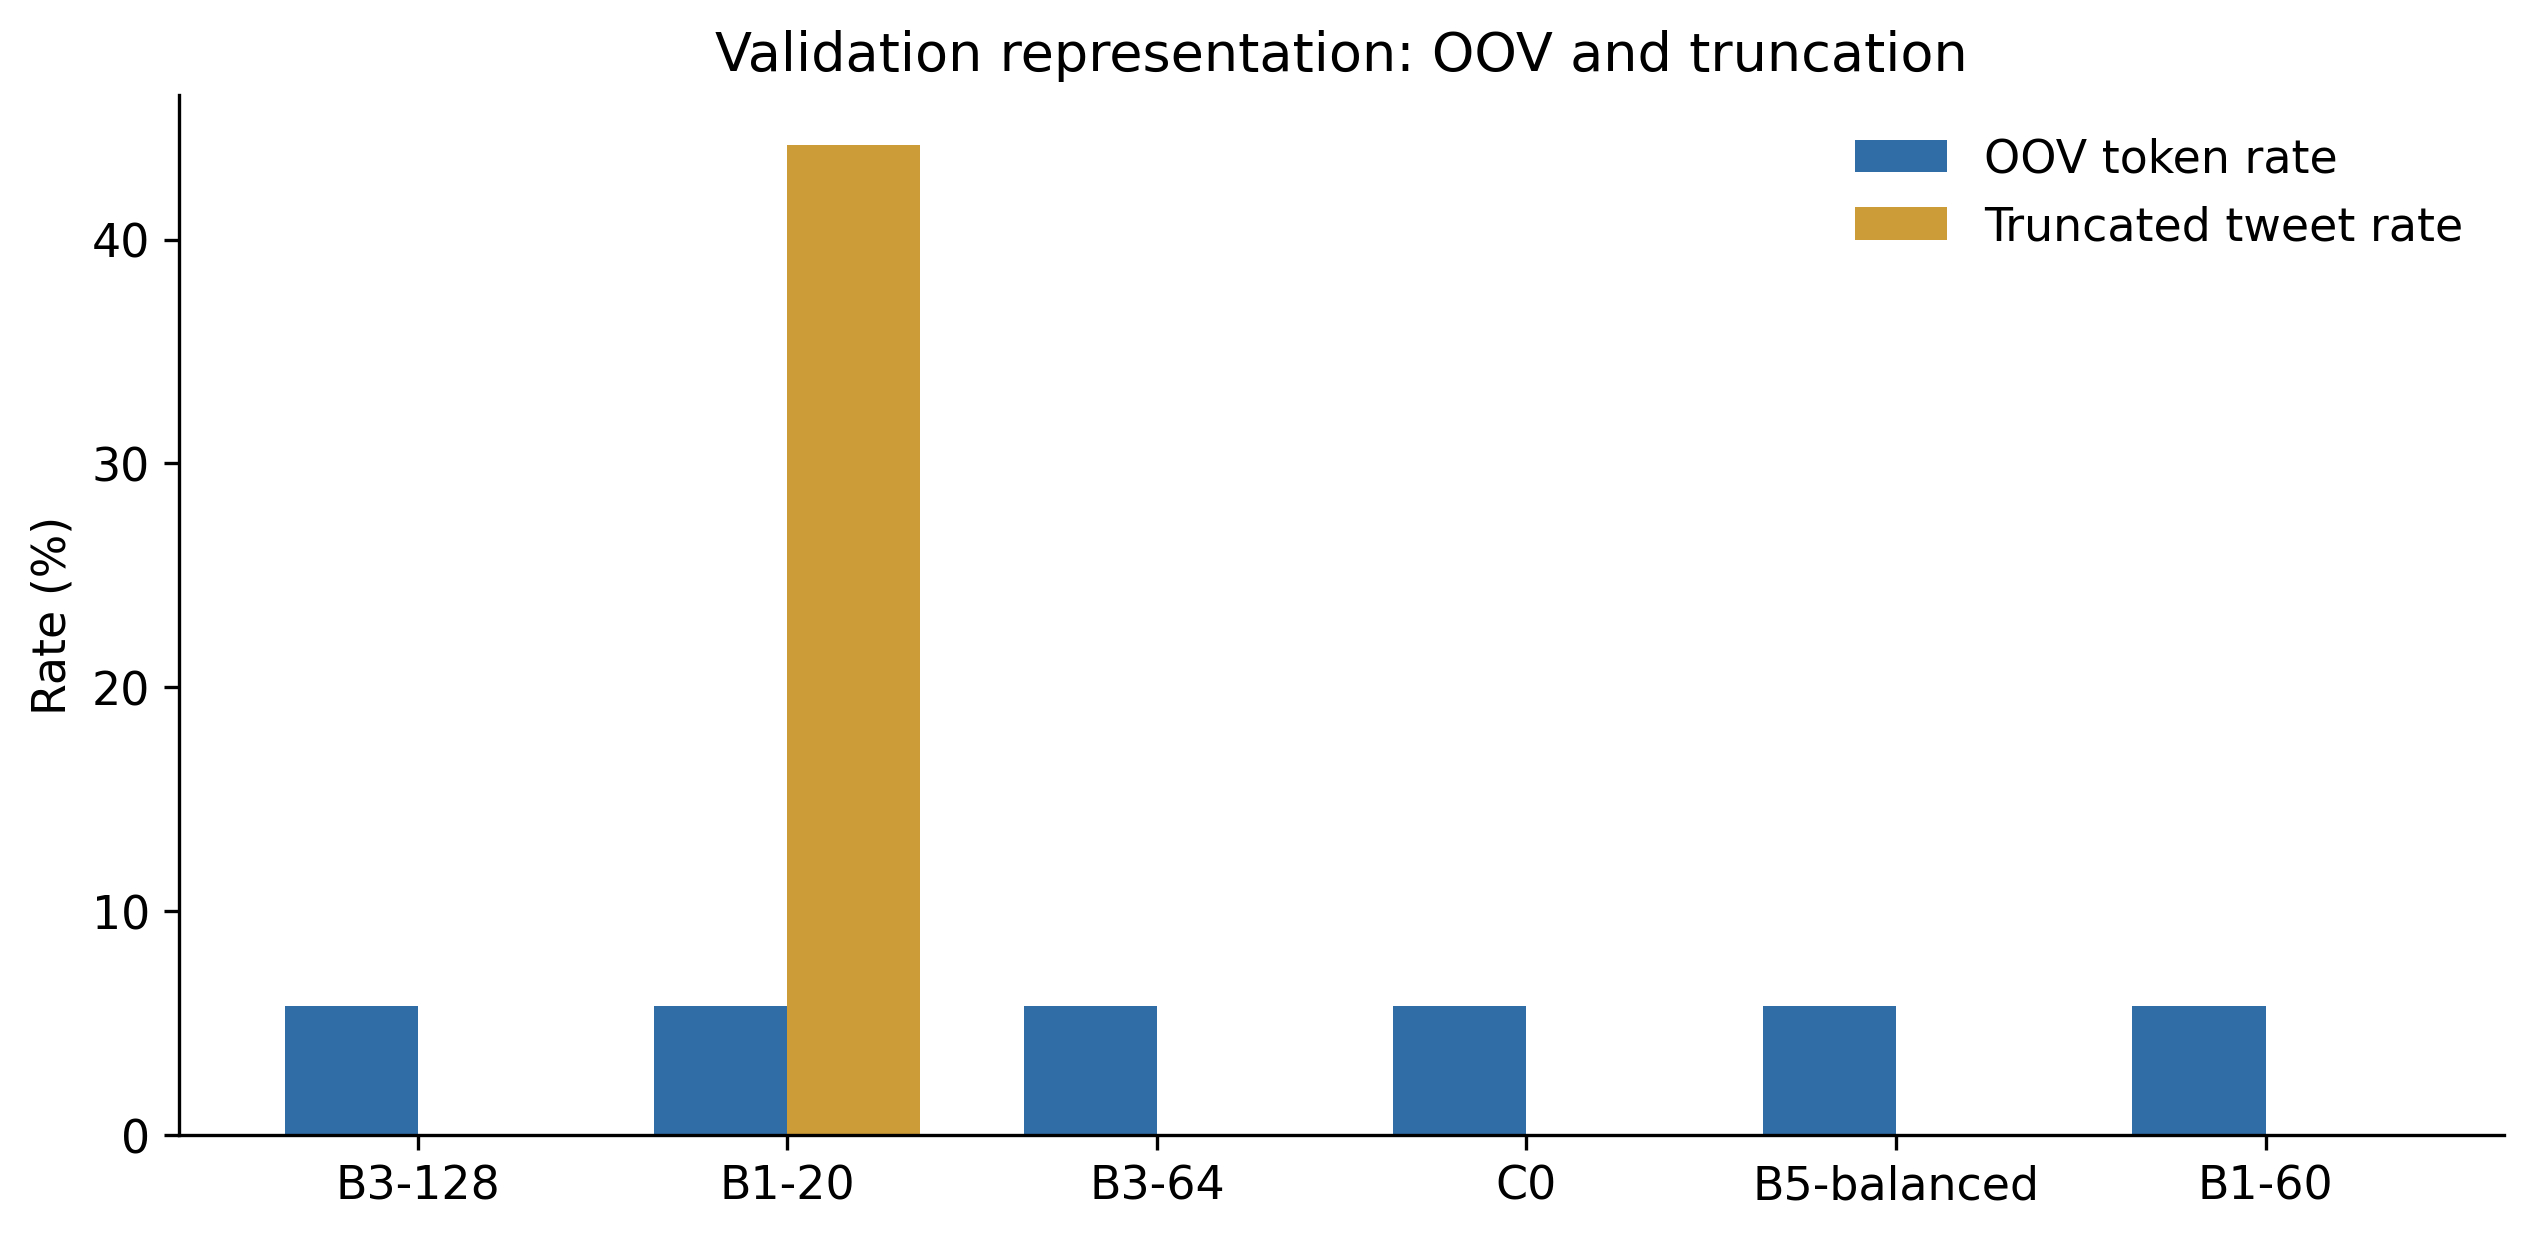

              precision    recall  f1-score   support

    negative     0.8534    0.8428    0.8481      1368
     neutral     0.5050    0.5670    0.5342       448
    positive     0.7220    0.6396    0.6783       333

    accuracy                         0.7538      2149
   macro avg     0.6935    0.6831    0.6869      2149
weighted avg     0.7604    0.7538    0.7564      2149



In [9]:
generate_results(RUN_ROOT)
write_report(RUN_ROOT)
display(pd.read_csv(RUN_ROOT / "results/tables/experiment_comparison.csv").fillna("withheld"))
display(pd.read_csv(RUN_ROOT / "results/tables/final_architecture.csv"))
print((RUN_ROOT / "models/final/model_summary.txt").read_text().replace(RNN.__name__, "RNN").replace("simple_rnn", "rnn"))
for name in ("F09_architecture", "F10_model_summary", "F11_loss", "F12_accuracy", "F13_macro_f1", "F14_confusion_count", "F15_confusion_normalized", "F16_per_class_f1", "F20_configuration_comparison", "F21_quality_cost", "F06_representation_rates"):
    figure(name)
metric_path = RUN_ROOT / f"results/metrics/{selection['winner_config']}_seed-{selection['demo_seed']}_test.json"
print(read_json(metric_path)["classification_report_text"])

## Phase 8 — Phân tích lỗi dựa trên evidence

Đọc các hướng nhầm positive/neutral/negative từ CM; dùng recall/F1 xác định lớp nào dễ hơn trong run này, không chỉ support. Slices độ dài dùng ngưỡng quartile **từ train**, phủ định dùng rule đánh dấu `not/no/never`; đây là phân nhóm mô tả, chưa chứng minh nguyên nhân. So sánh cùng support/class mix, không gán mọi lỗi ở slice cho length/negation.

CSV `manual_error_review.csv` có case sampling theo confusion pair, đúng từng class, low margin. Hai người annotate sarcasm/negation mất nghĩa/cleaning artifacts; các cột ban đầu để trống có chủ đích. Sau khi annotate, báo agreement và số case thật; không bịa nhãn. Không dùng kết quả error analysis trên test để quay lại chọn model trong vòng này.

# Phân tích lỗi thực tế — B5-balanced, seed 3407

Checkpoint được chọn bằng validation trước test; N=2149. Các tỷ lệ này mô tả một checkpoint, không thay bảng trung bình ba seeds.

## Nhầm lớp

- negative: 215/1368 mẫu sai; cặp nhầm nhiều nhất negative → neutral: 170 mẫu (12.43% support của lớp thật).
- neutral: 194/448 mẫu sai; cặp nhầm nhiều nhất neutral → negative: 157 mẫu (35.04% support của lớp thật).
- positive: 120/333 mẫu sai; cặp nhầm nhiều nhất positive → neutral: 79 mẫu (23.72% support của lớp thật).

Lớp có F1 cao nhất của checkpoint này là **negative**, F1=84.81%. Số lượng mẫu đúng tuyệt đối không được dùng để gọi lớp dễ nhất.

## Độ dài, OOV và negation

Các ngưỡng độ dài lấy từ quartile train: [13.0, 20.0, 24.0]. Bảng `results/tables/error_slices.csv` có support và phân bố class để tránh diễn giải sai do class mix.

| slice | value | support | accuracy | macro_f1 | error_rate | support_negative | support_neutral | support_positive |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| length_bin | (-1.0, 13.0] | 577 | 0.6880 | 0.6909 | 0.3120 | 220 | 213 | 144 |
| length_bin | (13.0, 20.0] | 607 | 0.7496 | 0.6896 | 0.2504 | 386 | 122 | 99 |
| length_bin | (20.0, 24.0] | 499 | 0.7796 | 0.6004 | 0.2204 | 378 | 59 | 62 |
| length_bin | (24.0, inf] | 466 | 0.8133 | 0.5248 | 0.1867 | 384 | 54 | 28 |
| flag_negation | False | 1448 | 0.7265 | 0.7013 | 0.2735 | 777 | 380 | 291 |
| flag_negation | True | 701 | 0.8103 | 0.5200 | 0.1897 | 591 | 68 | 42 |
| flag_any_oov | False | 930 | 0.7516 | 0.7028 | 0.2484 | 560 | 207 | 163 |
| flag_any_oov | True | 1219 | 0.7555 | 0.6716 | 0.2445 | 808 | 241 | 170 |
| truncated | False | 2149 | 0.7538 | 0.6869 | 0.2462 | 1368 | 448 | 333 |

Các chênh lệch là quan sát trên test; chưa chứng minh độ dài/OOV/negation gây ra lỗi. Negation flags dựa trên từ not/no/never trong clean text, cần kiểm tra ngữ cảnh khi phân tích trường hợp cụ thể.

## Cleaning, sarcasm và manual review

Cleaner P0 bỏ emoji/dấu câu, giữ phủ định và nội dung hashtag. Bảng before/after chứng minh phép biến đổi, chưa chứng minh ảnh hưởng F1 vì chưa chạy preprocessing ablation. Tập review có 85 dòng, sampling seed=42, gồm cặp nhầm, mẫu đúng và margin thấp.

`results/predictions/manual_error_review.csv` có cột hai người review và notes để nhóm ghi các nhãn negation, sarcasm, mixed sentiment, slang/typo, missing context, truncation hoặc uncertain. **Chưa có nhãn sarcasm được con người xác minh, nên chưa có kết luận về sarcasm.** Không tự gán sarcasm từ một từ như great.

Softmax và top-2 margin chưa được calibration. Confidence thấp không đồng nghĩa prediction sai; confidence cao cũng có thể sai.

## Giới hạn

Test đã được mở cho phân tích này; không dùng các lỗi để tiếp tục chọn hyperparameter trên cùng holdout. Các cải tiến từ review được ghi future work hoặc kiểm tra trên validation/holdout mới.


,slice,value,support,accuracy,macro_f1,error_rate,support_negative,support_neutral,support_positive
0,length_bin,"(-1.0, 13.0]",577,0.688042,0.690894,0.311958,220,213,144
1,length_bin,"(13.0, 20.0]",607,0.749588,0.689564,0.250412,386,122,99
2,length_bin,"(20.0, 24.0]",499,0.779559,0.600379,0.220441,378,59,62
3,length_bin,"(24.0, inf]",466,0.813305,0.524764,0.186695,384,54,28
4,flag_negation,False,1448,0.726519,0.701303,0.273481,777,380,291
5,flag_negation,True,701,0.810271,0.519951,0.189729,591,68,42
6,flag_any_oov,False,930,0.751613,0.702791,0.248387,560,207,163
7,flag_any_oov,True,1219,0.755537,0.671561,0.244463,808,241,170
8,truncated,False,2149,0.753839,0.686875,0.246161,1368,448,333


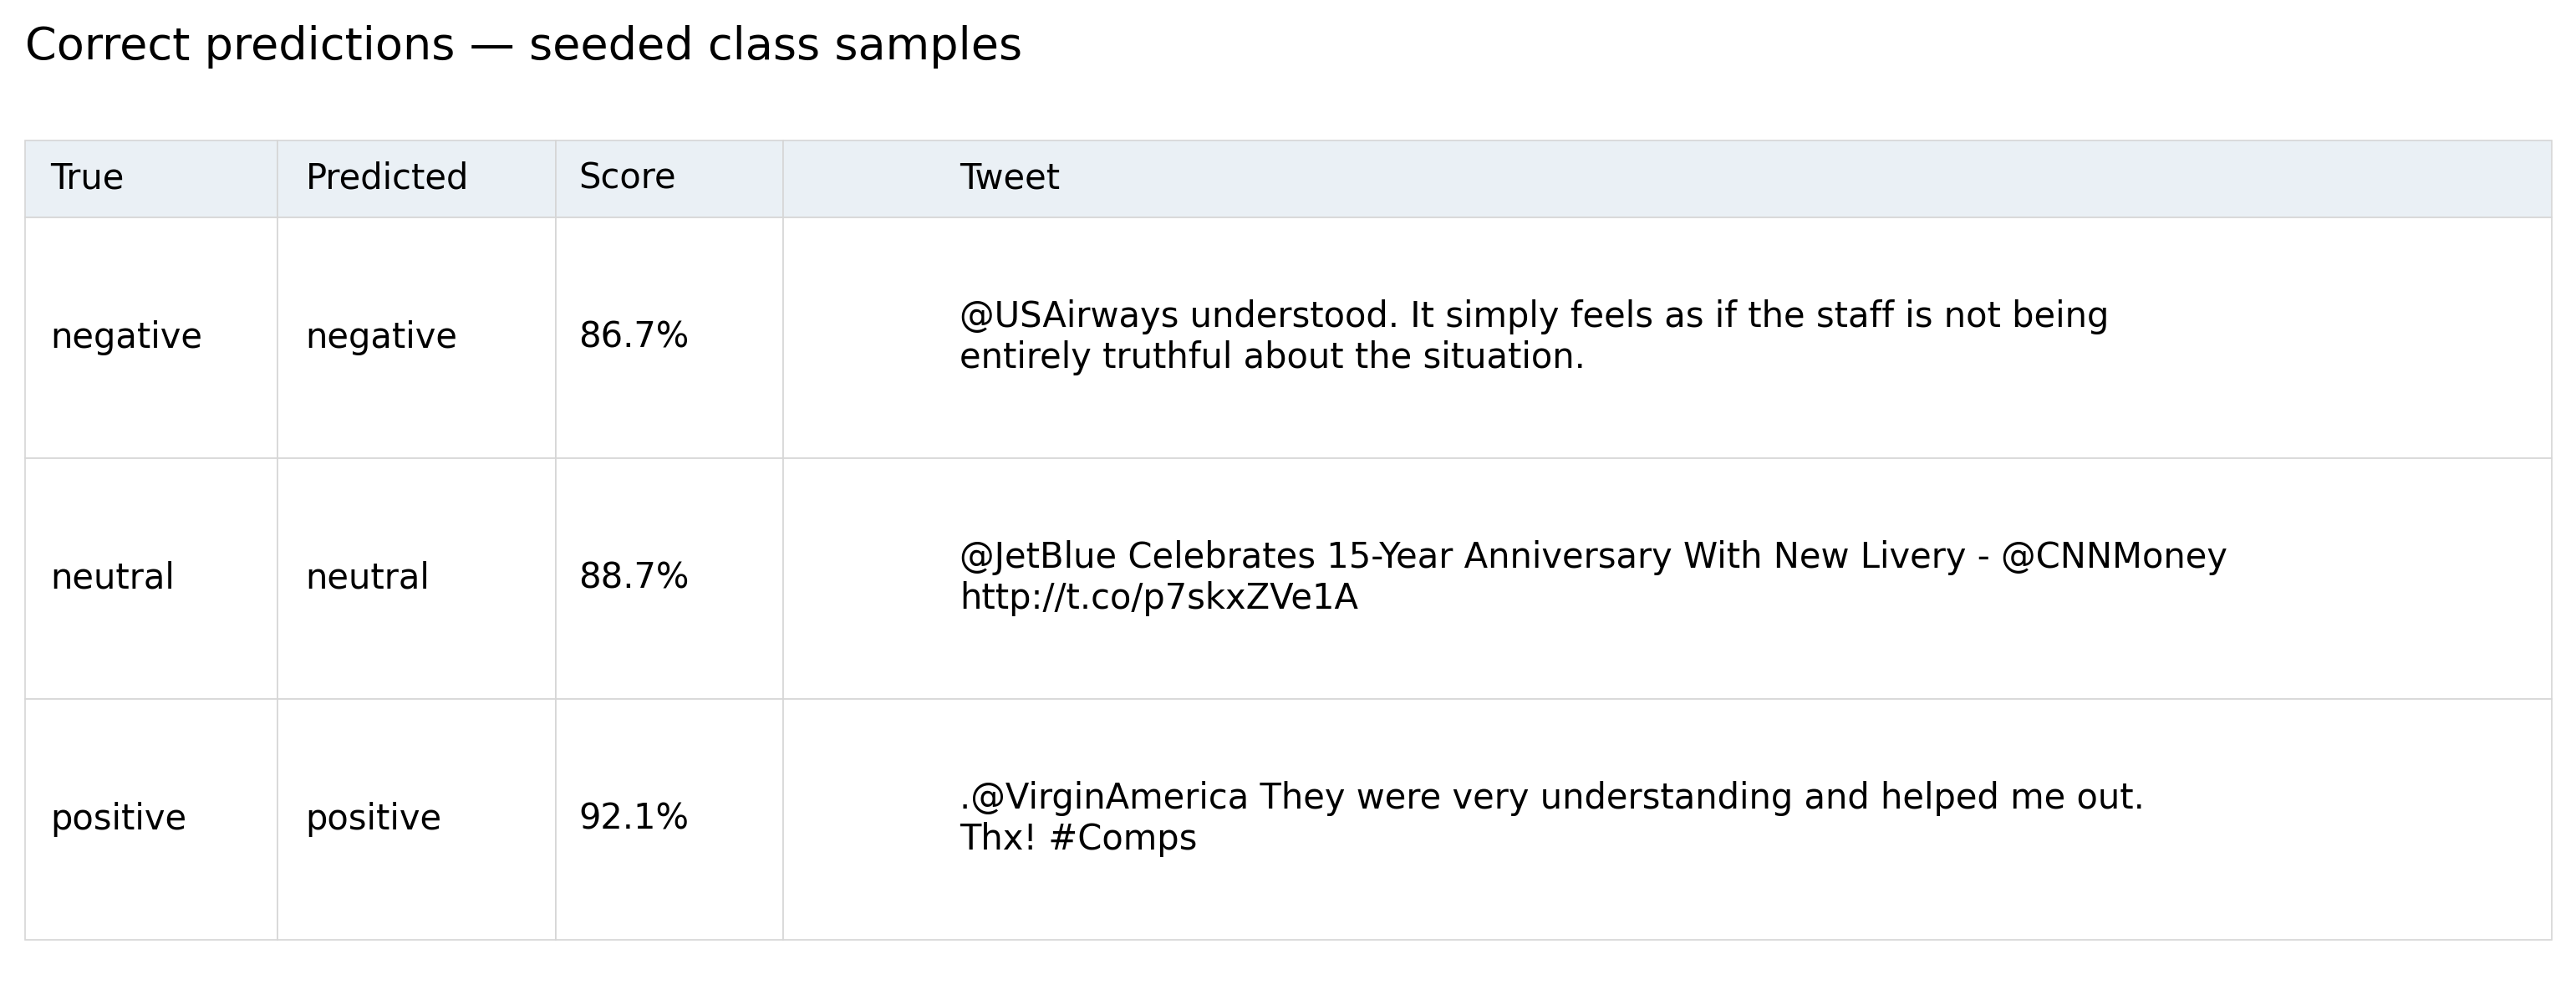

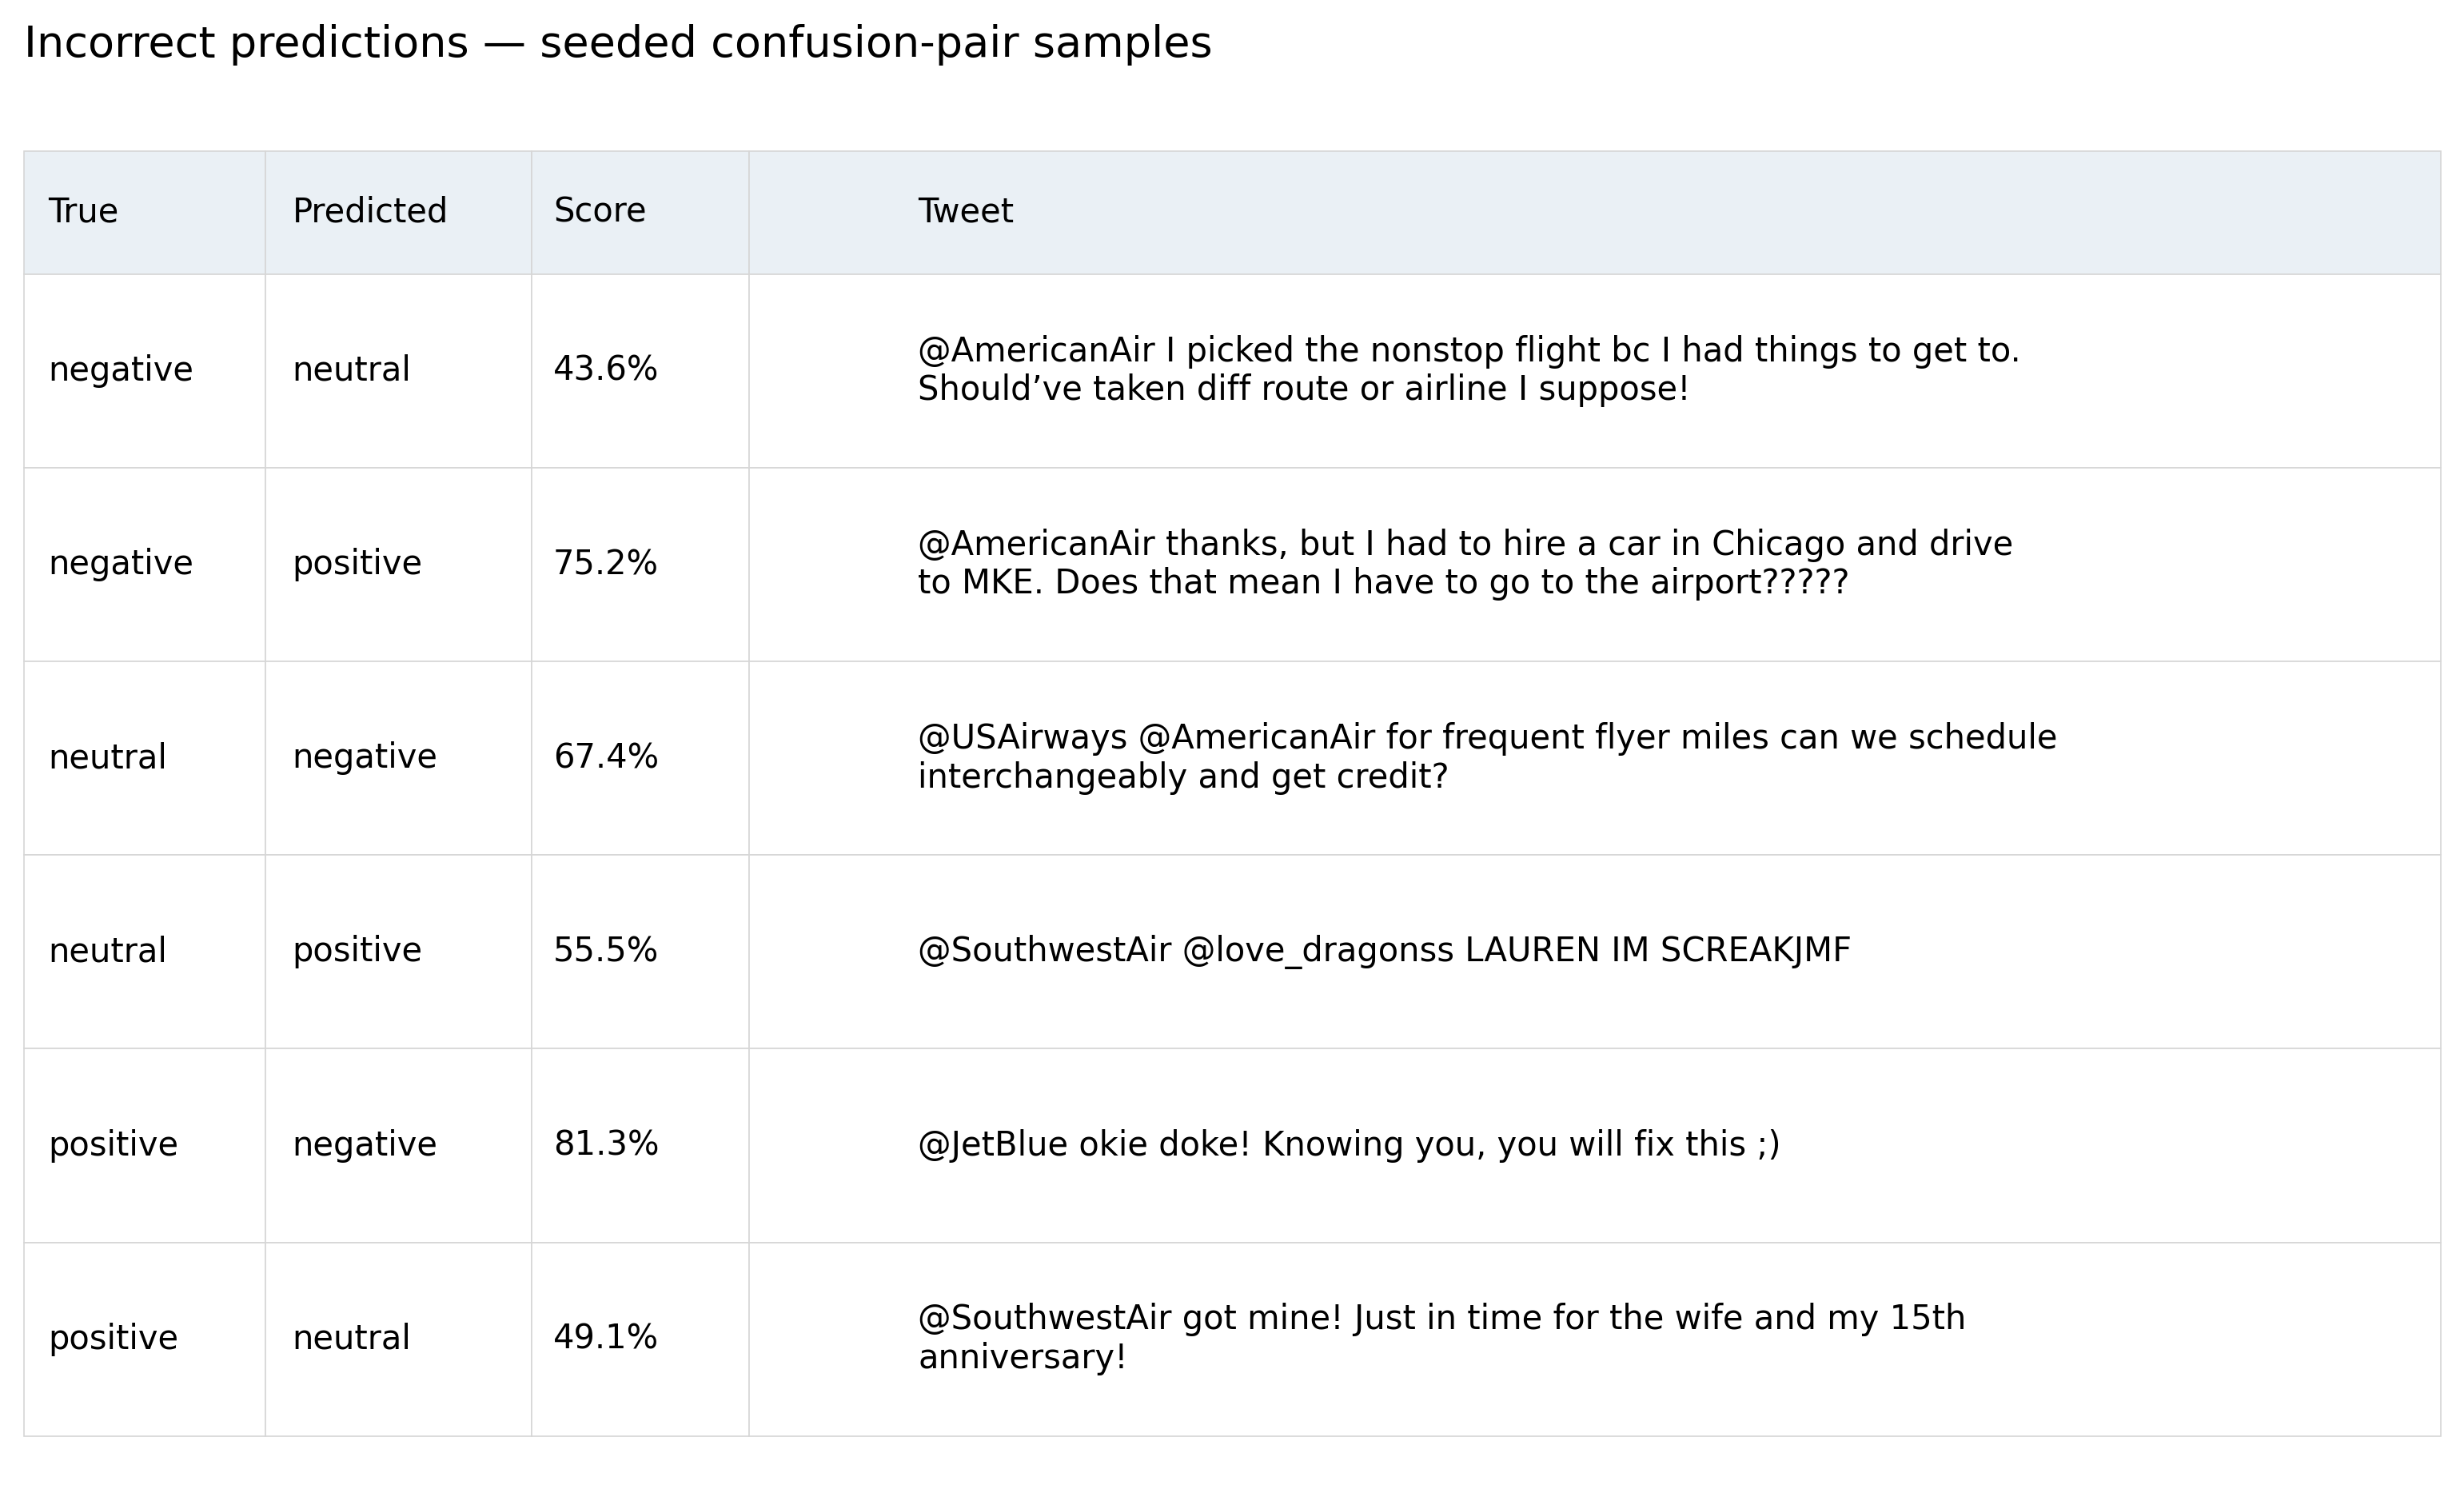

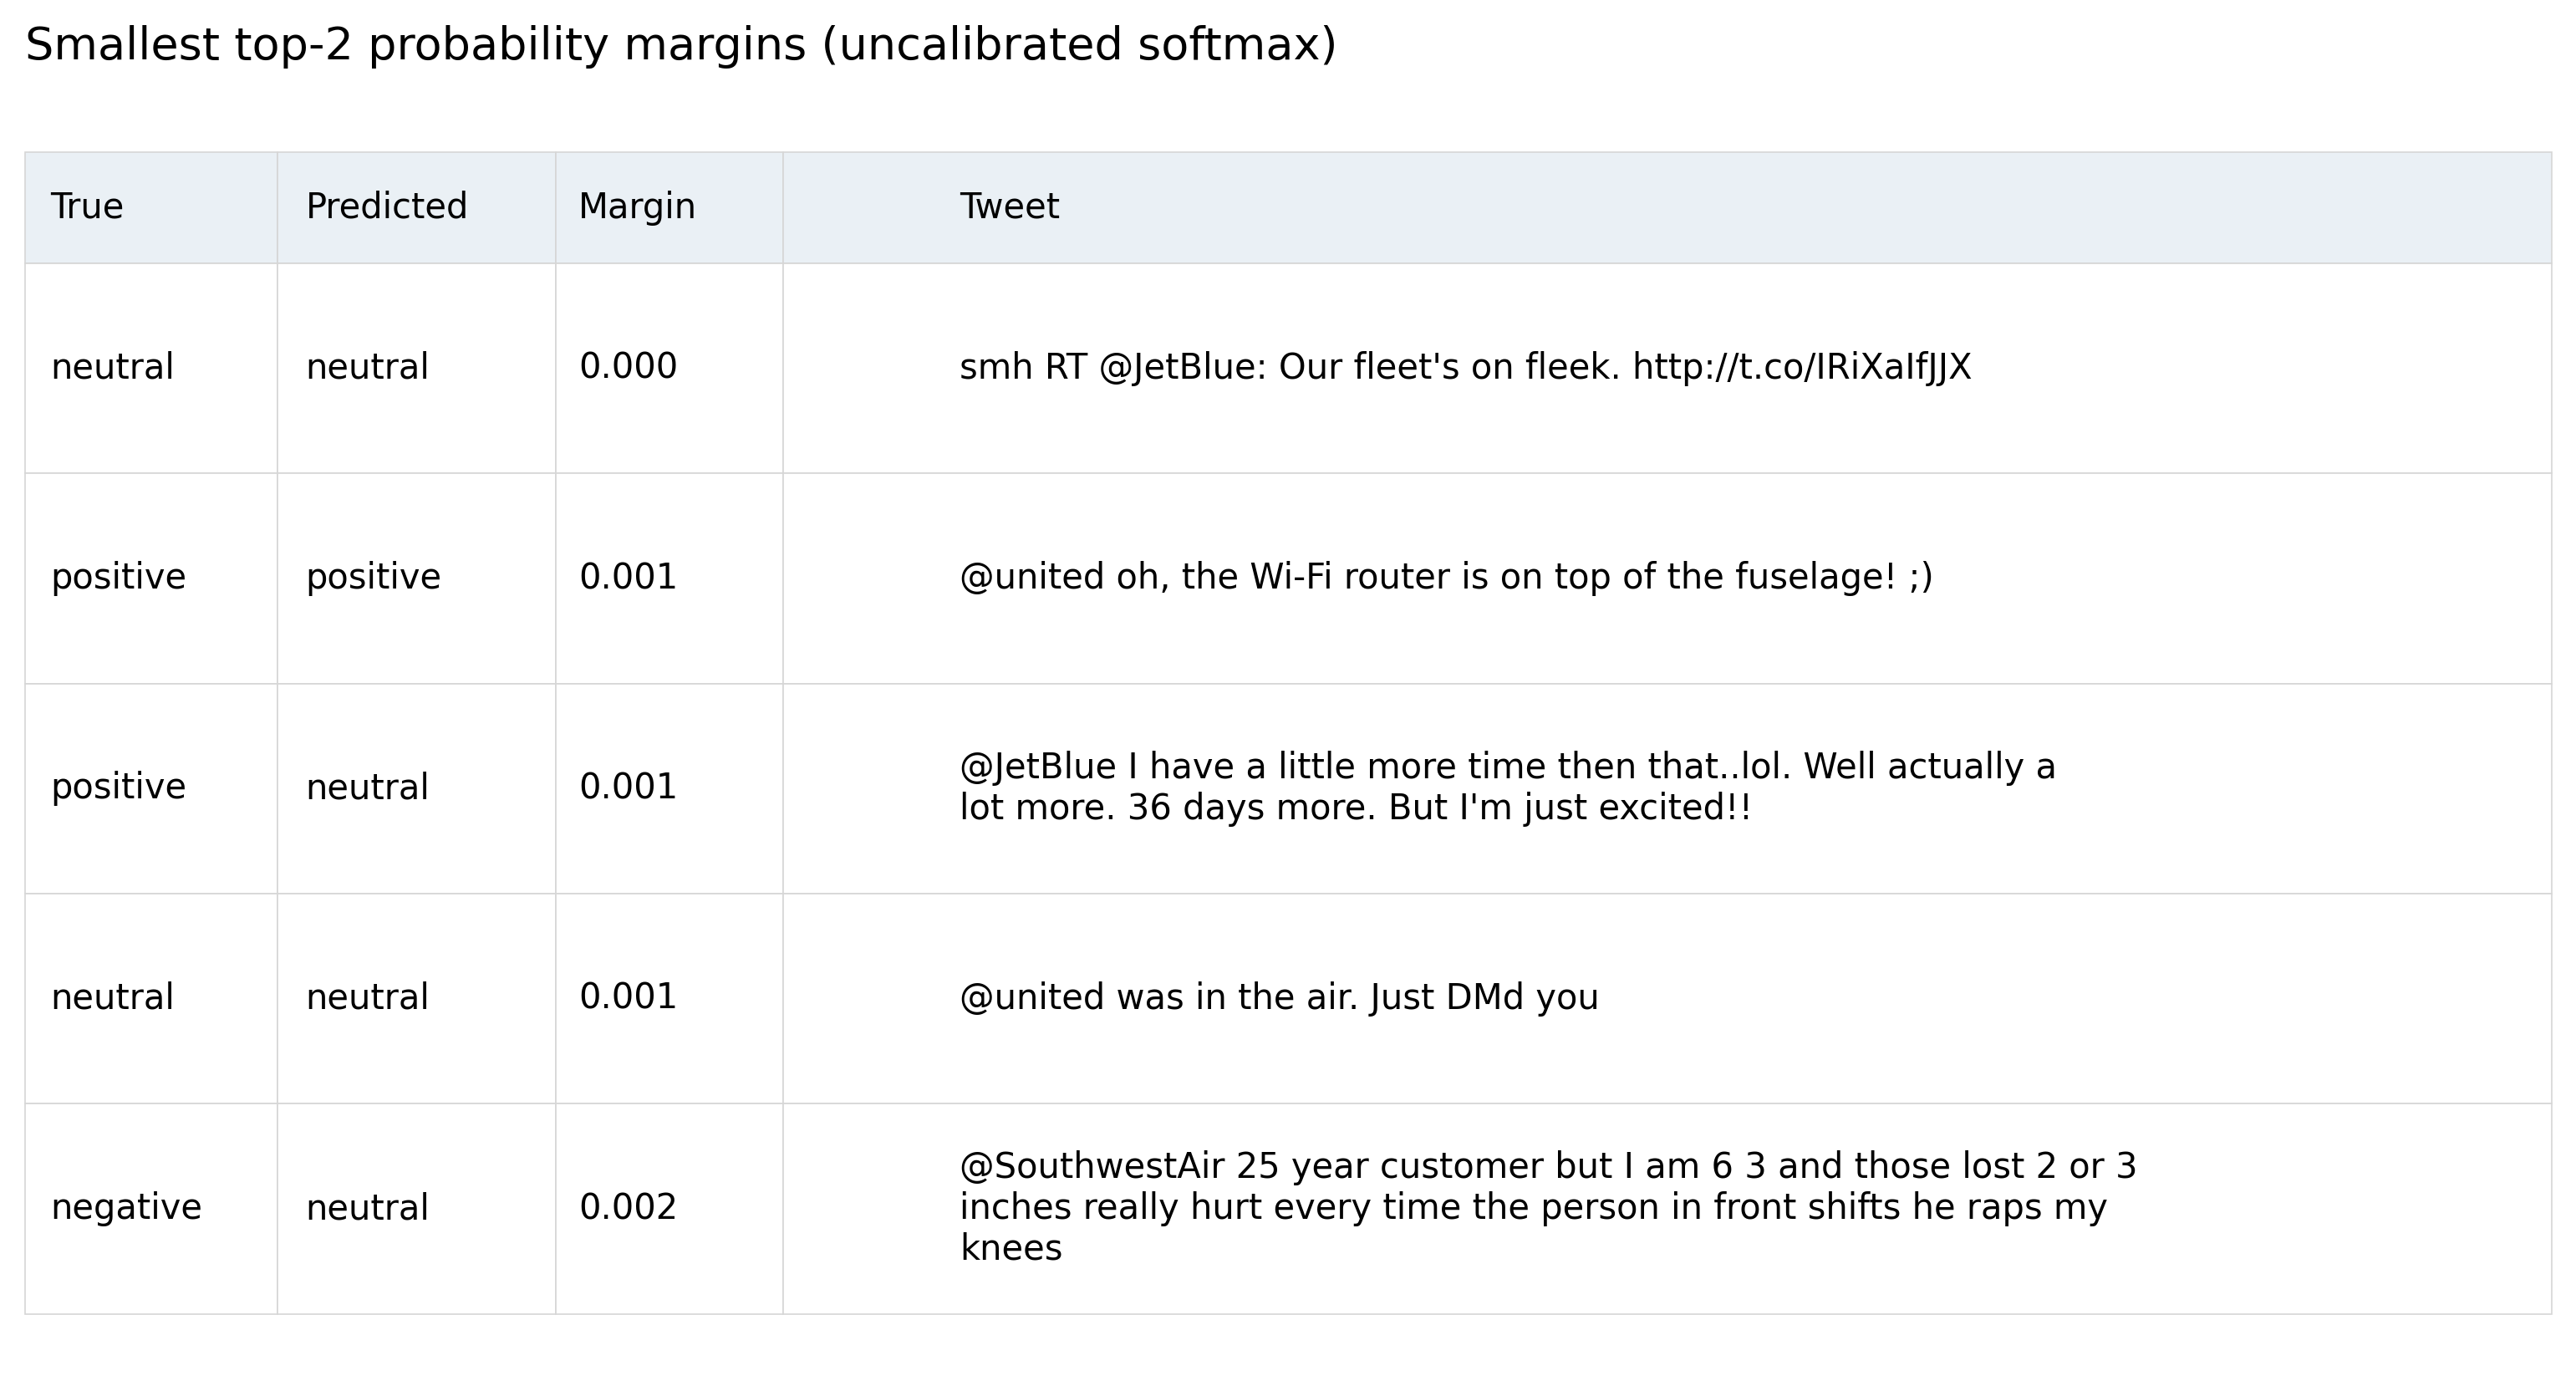

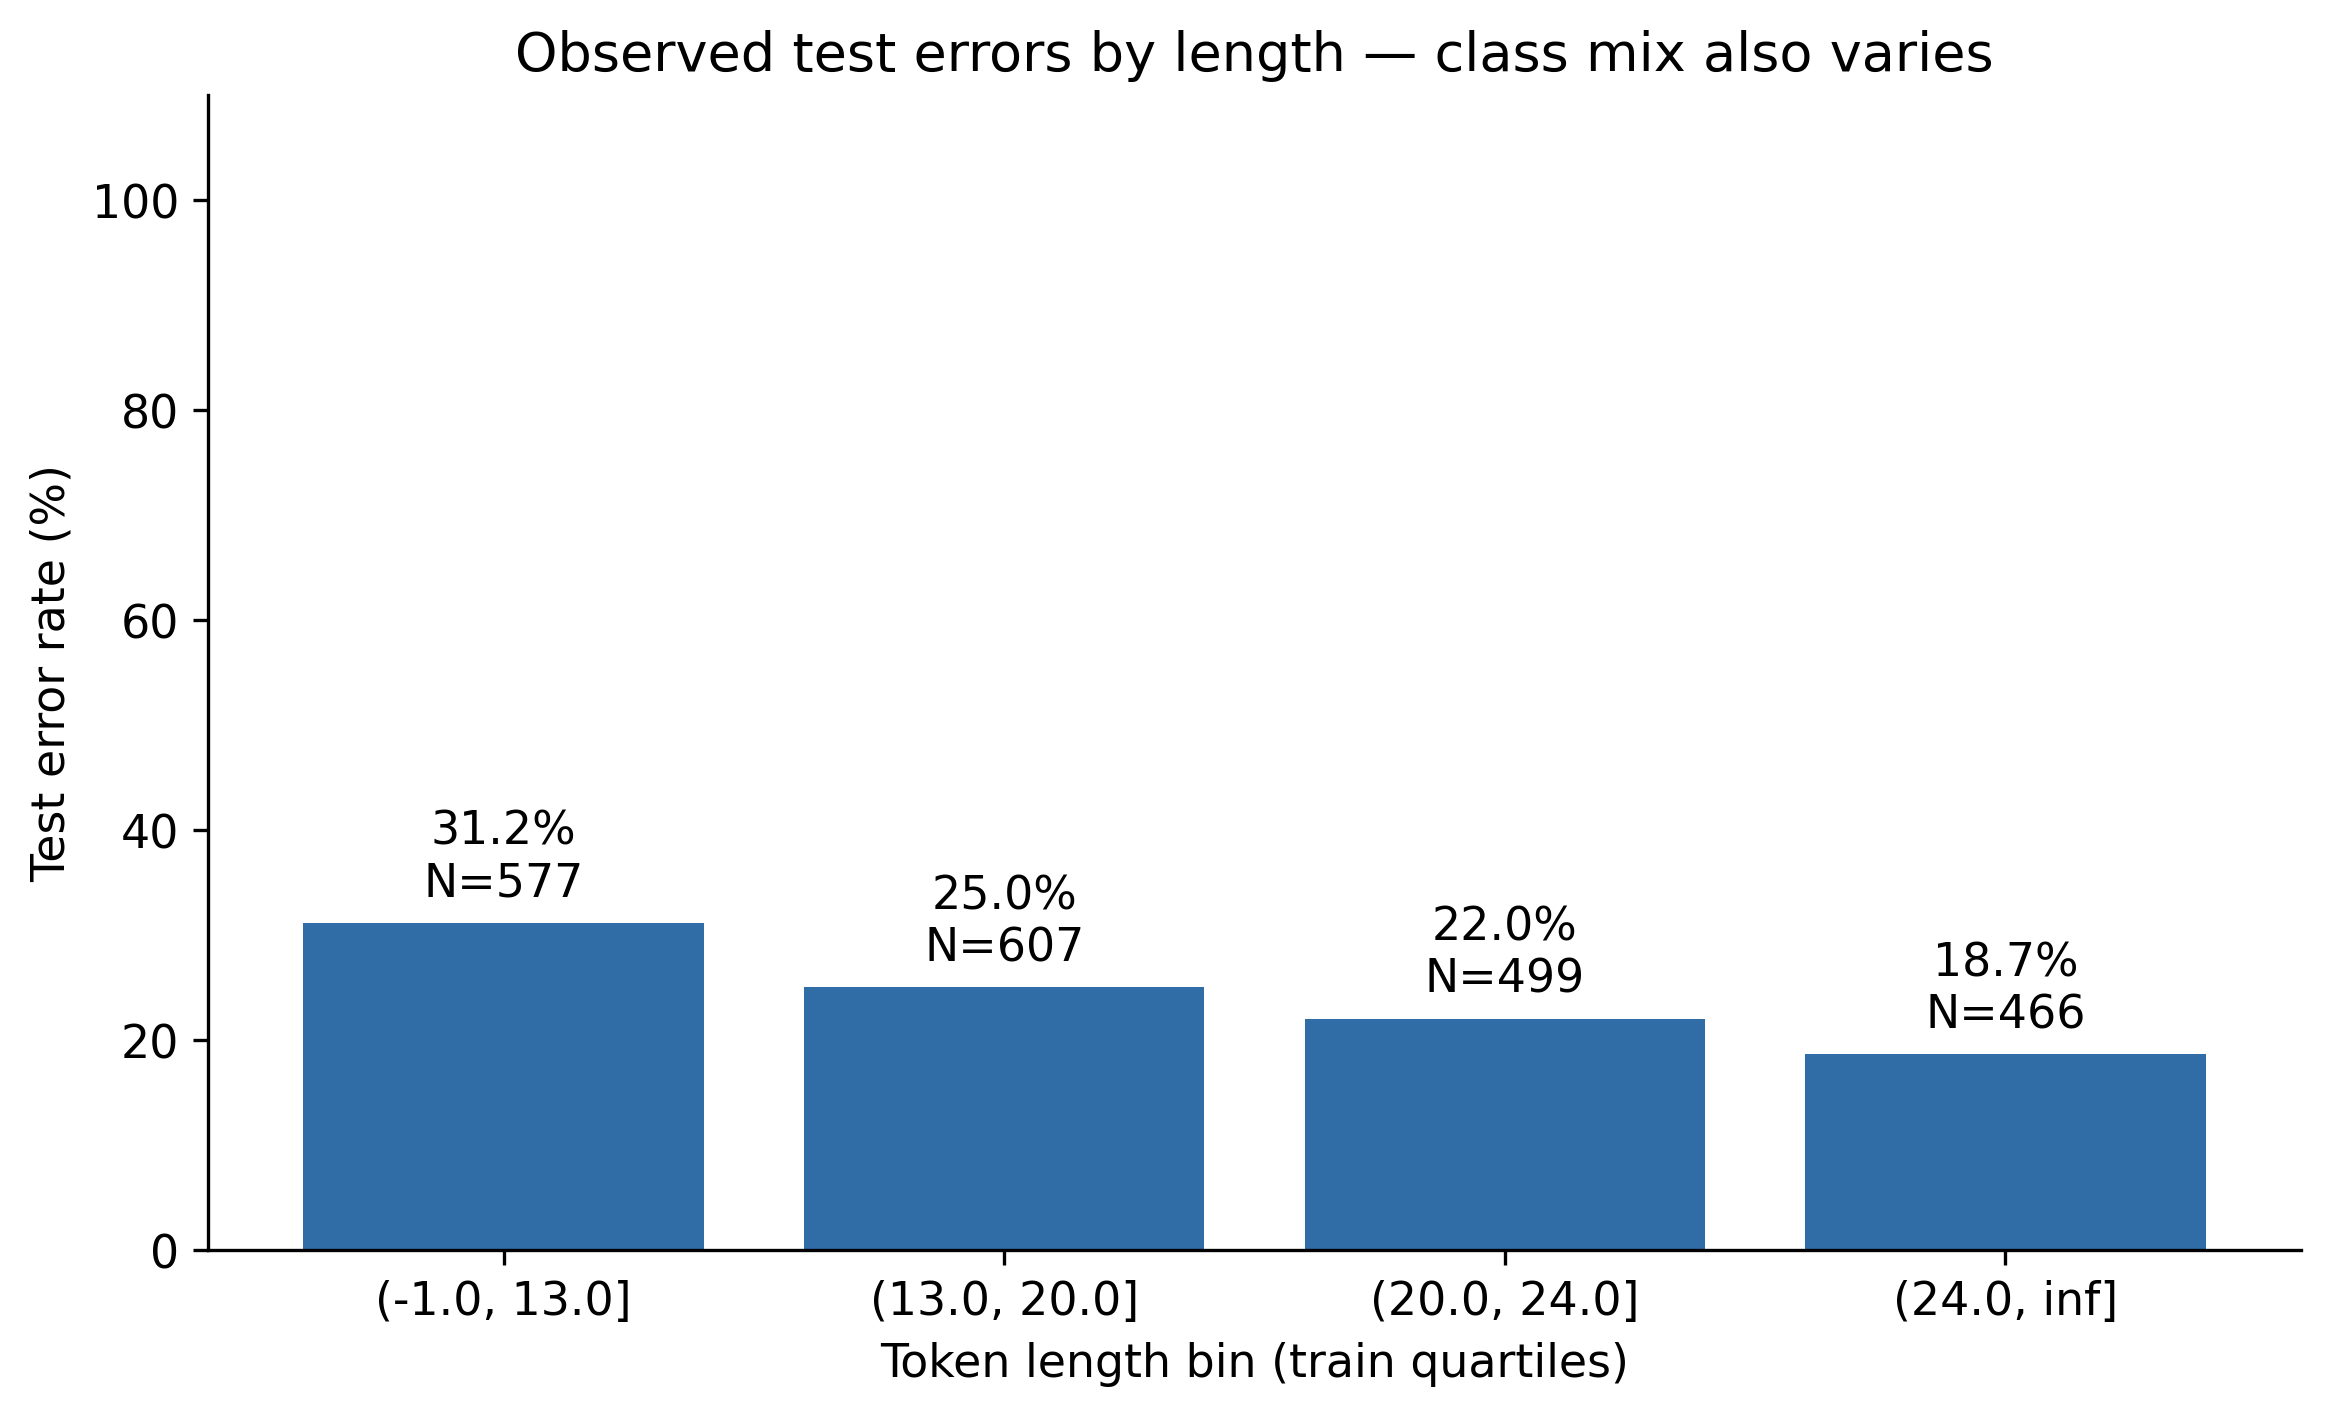

Manual review cases: 85 — human annotation fields remain pending.


,row_id,tweet_id,airline,true_label,raw_text,clean_text,predicted_label,correct,confidence,top2_margin,...,truncated,empty_sequence,length_bin,flag_negation,flag_url,flag_any_oov,review_reason,reviewer_1_group,reviewer_2_group,review_notes
0,12292,570240784357830659,American,negative,@AmericanAir I picked the nonstop flight bc I ...,usermarker i picked the nonstop flight bc i ha...,neutral,False,0.436401,0.010885,...,False,False,"(20.0, 24.0]",False,False,False,confusion_pair,NaN,NaN,NaN
1,2805,568892505829347329,United,negative,@united we can't all be american airlines I su...,usermarker we can not all be american airlines...,neutral,False,0.890122,0.798083,...,False,False,"(-1.0, 13.0]",True,True,False,confusion_pair,NaN,NaN,NaN
2,10333,569365604832047104,US Airways,negative,@USAirways just hit 4hrs. what is typical wai...,usermarker just hit 4hrs what is typical wait ...,neutral,False,0.620870,0.402449,...,False,False,"(13.0, 20.0]",False,False,True,confusion_pair,NaN,NaN,NaN
3,2717,568940548301549568,United,negative,@United can you let us out of the gate now. UA...,usermarker can you let us out of the gate now ...,neutral,False,0.859159,0.776988,...,False,False,"(-1.0, 13.0]",False,False,True,confusion_pair,NaN,NaN,NaN
4,12779,570027031326535680,American,negative,@AmericanAir I need assistance reFlight Bookin...,usermarker i need assistance reflight booking ...,neutral,False,0.913390,0.839054,...,False,False,"(-1.0, 13.0]",False,False,False,confusion_pair,NaN,NaN,NaN


In [10]:
display(Markdown((RUN_ROOT / "reports/error_analysis.md").read_text()))
display(pd.read_csv(RUN_ROOT / "results/tables/error_slices.csv"))
for name in ("F17_correct_examples", "F18_error_examples", "F19_low_confidence", "F22_length_errors"):
    figure(name)
review = pd.read_csv(RUN_ROOT / "results/predictions/manual_error_review.csv")
print("Manual review cases:", len(review), "— human annotation fields remain pending.")
display(review.head(5))

## Phase 9 — Inference dùng nguyên preprocessing/tokenizer/checkpoint

Không fit tokenizer ở inference. Mapping lớp đọc từ bundle; probabilities tổng≈1. Ví dụ nhập mới không phải thêm test metric. Demo local có form và bar xác suất; lệnh trong README. Mô hình học tiếng Anh/tweet airline, chưa kiểm tra tiếng Việt/miền khác. Softmax chưa calibration; confidence thấp dùng margin để mô tả, không khẳng định xác suất đúng đã kiểm chứng.

,text,sentiment,probabilities,confidence,clean_text,token_length,unknown_tokens,truncated,config_id,seed,note
0,@united Thank you for the helpful service!,positive,"{'negative': 0.0032259314320981503, 'neutral':...",0.988673,usermarker thank you for the helpful service,7,0,False,B5-balanced,3407,Softmax chưa được calibration; không diễn giải...
1,@AmericanAir My flight was delayed again and n...,negative,"{'negative': 0.9181810021400452, 'neutral': 0....",0.918181,usermarker my flight was delayed again and nob...,10,0,False,B5-balanced,3407,Softmax chưa được calibration; không diễn giải...
2,@Delta What time does flight 123 depart?,neutral,"{'negative': 0.16896368563175201, 'neutral': 0...",0.709801,usermarker what time does flight 123 depart,7,1,False,B5-balanced,3407,Softmax chưa được calibration; không diễn giải...


{'sentiment': 'neutral',
 'probabilities': {'negative': 0.07670217752456665,
  'neutral': 0.8105694055557251,
  'positive': 0.11272843927145004},
 'confidence': 0.8105694055557251,
 'clean_text': 'usermarker i can not believe how helpful the staff were today',
 'token_length': 11,
 'unknown_tokens': 0,
 'truncated': False,
 'config_id': 'B5-balanced',
 'seed': 3407,
 'note': 'Softmax chưa được calibration; không diễn giải score như độ tin cậy đã kiểm chứng.'}

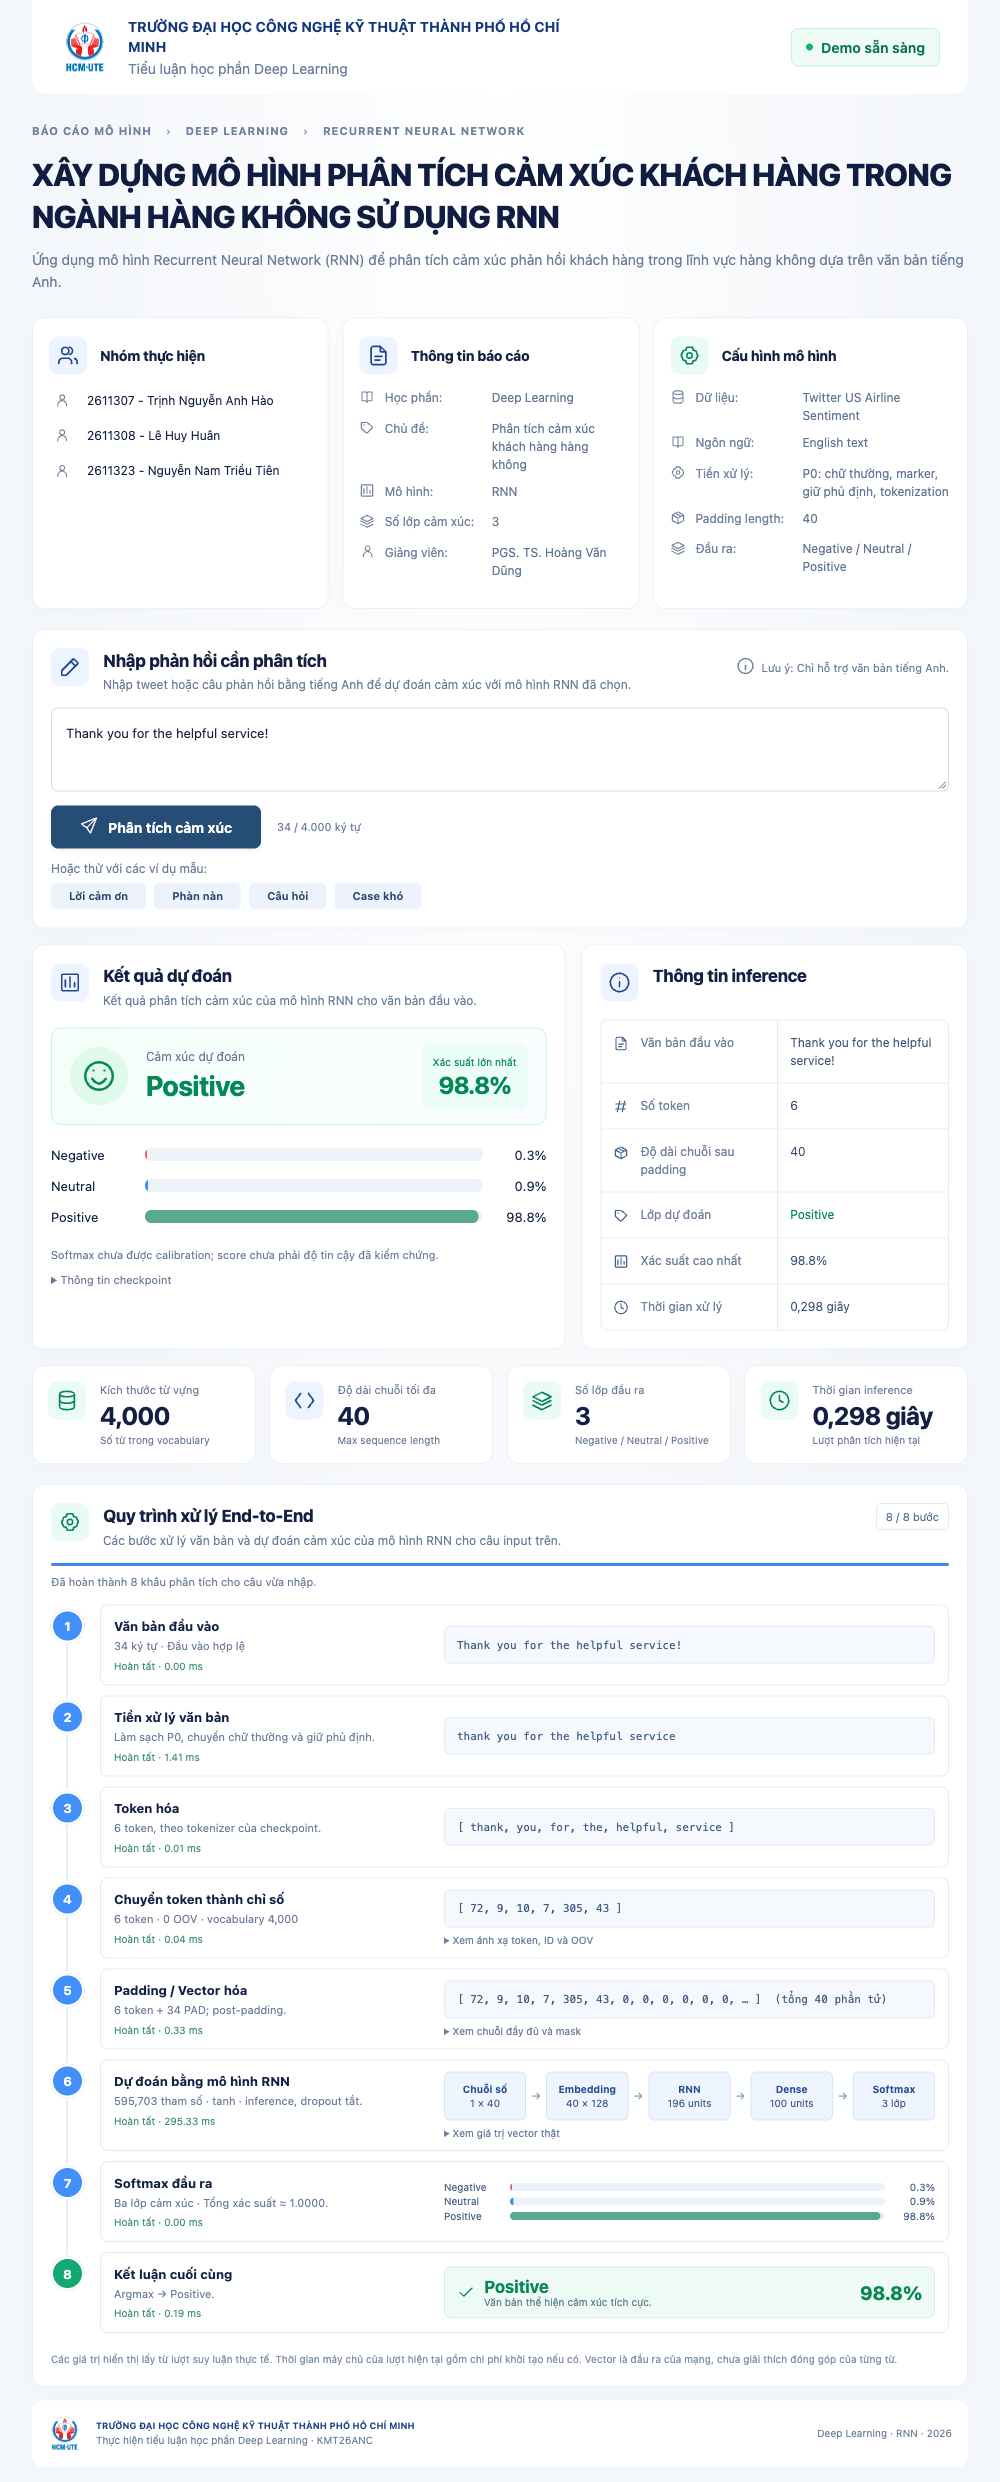

In [11]:
from airline_rnn.inference import SentimentPredictor
predictor = SentimentPredictor(RUN_ROOT)
examples = [
    "@united Thank you for the helpful service!",
    "@AmericanAir My flight was delayed again and nobody helped me.",
    "@Delta What time does flight 123 depart?",
]
inference_examples = [{"text": text, **predictor.predict(text)} for text in examples]
display(pd.DataFrame(inference_examples))
from airline_rnn.common import save_json
save_json(RUN_ROOT / "results/predictions/inference_examples.json", inference_examples)

# Change this text and re-run this cell for an interactive notebook demo.
USER_TEXT = "@united I can't believe how helpful the staff were today!"
display(predictor.predict(USER_TEXT))
figure("F23_demo")  # actual browser screenshot if captured for this project

## Phase 10 — Artifacts cho báo cáo và thuyết trình

- `reports/experiment_chapter.md`: chương thực nghiệm chứa số thật, nguồn dữ liệu, protocol, kết quả và hạn chế.
- `reports/source_audit.md`: đối chiếu kiến trúc/population và overlap nguồn.
- `reports/error_analysis.md`: phân tích mô tả CM/slices, giới hạn causal interpretation.
- `results/figures/`: PNG300dpi + PDF; `manifest.json` ghi mục đích và scope từng hình.
- `results/tables/`: Dataset, split/exclusion, training config, architecture Input/Output/Parameters, comparison, per-class, error slices.
- `results/metrics/`: full JSON/classification reports/frozen selection; `results/histories/`: history từng run.
- `models/final/`: checkpoint, tokenizer, labels, config, representation metadata và checksum manifest.
- README: môi trường, cách chạy mới/cached, Colab/Drive, demo, chính sách holdout.

Cấu trúc báo cáo đầy đủ và outline thuyết trình lưu trong `reports/`. Báo cáo mẫu chỉ định hướng cách tổ chức; không lấy kết luận CIFAR10/GCN của mẫu làm kết quả sentiment.

In [12]:
display(Markdown((RUN_ROOT / "reports/experiment_chapter.md").read_text()))
manifest = read_json(RUN_ROOT / "results/figures/manifest.json")
display(pd.DataFrame(manifest).T[["png", "purpose", "scope"]])
print("All outputs saved under:", RUN_ROOT)

# CHƯƠNG 3. THỰC NGHIỆM VÀ ĐÁNH GIÁ

## 3.1. Phạm vi và môi trường thực tế

Dự án giữ **RNN** làm mô hình chính. Notebook Kaggle dùng LSTM/binary là nguồn tham khảo, không phải cùng kiến trúc với thực nghiệm nhóm. Kết quả dưới đây được sinh từ các run hoàn tất, không có số Accuracy/F1 điền trước.

Môi trường thực thi lần này: macOS-27.2-arm64-arm-64bit; Python 3.12.14; TensorFlow 2.20.0; Keras 3.11.3; CPU arm64, 10 physical cores; RAM 16.0GiB; GPU không có GPU TensorFlow. Float32, deterministic operations; intra/inter threads 2/1. Tổng wall time training các run đăng ký (kể cả full-split metrics từng epoch): 19.91 phút. Thời gian không đại diện Colab GPU.

Notebook và dependencies hỗ trợ chuyển lên Colab; Google Drive dùng lưu artifacts nếu nhóm chọn. **Các kết quả hiện có được chạy trên máy cá nhân**, không ghi nhầm là Colab/T4.

## 3.2. Dataset, exclusions và split

Dataset raw: 14,640tweet, 15cột; SHA-256 `ea94b23f41892b290dec3330bb8cf9cb6b8bc669eaae5f3a84c40f7b0de8f15e`. Input chỉ là text, target sentiment; metadata hãng không làm feature. Duplicate ID raw=155, duplicate raw text=213; các field confidence/gold/reason không đưa vào model.

| benchmark | reason | rows |
| --- | --- | --- |
| binary | exact_duplicate_record | 28 |
| binary | conflicting_labels_in_duplicate_group | 8 |
| three_class | conflicting_labels_in_duplicate_group | 251 |
| three_class | exact_duplicate_record | 36 |

Nhóm duplicate tạo theo tweet ID, raw text chuẩn hóa và clean representation; conflicting-label groups cách ly; exact duplicate records bỏ; các nhóm còn lại không chéo split sạch. A1 giữ split nguồn riêng.

| benchmark | split | negative | positive | total | neutral |
| --- | --- | --- | --- | --- | --- |
| binary_source | test | 1254 | 709 | 1963 | 0 |
| binary_source | train | 2361 | 1301 | 3662 | 0 |
| binary_source | validation | 563 | 353 | 916 | 0 |
| binary_clean | test | 1257 | 709 | 1966 | 0 |
| binary_clean | train | 2321 | 1323 | 3644 | 0 |
| binary_clean | validation | 577 | 318 | 895 | 0 |
| three_class | test | 1368 | 333 | 2149 | 448 |
| three_class | train | 6404 | 1544 | 10043 | 2095 |
| three_class | validation | 1368 | 335 | 2161 | 458 |

Tỷ lệ trên dữ liệu sạch có thể lệch nhẹ70/15/15 do giữ group. Manifest lưu row IDs,group IDs và hashes. Source binary/A2/three-class có population khác nhau nên không so accuracy như cùng benchmark.

## 3.3. Kiến trúc và training protocol

Embedding → SpatialDropout → RNN(tanh) → Dropout → Dense100/ReLU → Dropout → softmax. Word vocabulary train-only ở A2/C0/B; PAD0,OOV1 và marker IDs ở P0; padding được mask ở C0/B. Sparse categorical cross-entropy; Adam LR0.001; batch32;max20epochs. Clean runs checkpoint theo valMacro-F1, ES patience5/min_delta0.001;A1 dùng epochcuối.

| Hyperparameter | Value |
| --- | --- |
| id | B5-balanced |
| benchmark | three_class |
| vocabulary_size | 4000 |
| sequence_length | 40 |
| hidden_units | 196 |
| embedding_dimension | 128 |
| spatial_dropout | 0.5 |
| input_dropout | 0.3 |
| recurrent_dropout | 0.3 |
| output_dropout | 0.2 |
| dense_units | 100 |
| dense_dropout | 0.4 |
| learning_rate | 0.001 |
| batch_size | 32 |
| max_epochs | 20 |
| patience | 5 |
| min_delta | 0.001 |
| class_weighting | balanced |
| gradient_clipnorm | 1.0 |
| early_stopping | True |
| mask_zero | True |

Seeds42,2026,3407 trên cùng split. F1 tính trên toàn validation/train trong inference mode, không trung bình F1 minibatch. Balanced weights chỉ dùng train. Source code/config/split/checkpoint hashes được lưu. Matrix khóa trước test; chọn meanvalMacro-F1. Các config cách max dưới0.005 được ưu tiên ít parameters, sau đó median training time; đây là quy tắc thực dụng, không phải kiểm định tương đương.

Các bảng Accuracy dùng thang phần trăm; SD bên cạnh là điểm phần trăm. Macro-F1 dùng thang0–1. Run đơn hoặc majority baseline không báo SD như một ước lượng độ bất định.

## 3.4. Baseline và controlled experiments

| Configuration | Benchmark | Seeds | Val Accuracy | Val Macro-F1 |
| --- | --- | --- | --- | --- |
| A1 | binary_source | 1 | 84.83% | 0.8376 |
| A2 | binary_clean | 3 | 73.33% ± 11.74 | 0.6421 ± 0.2171 |
| C0 | three_class | 3 | 75.12% ± 0.63 | 0.6623 ± 0.0017 |
| B1-20 | three_class | 3 | 75.69% ± 0.92 | 0.6722 ± 0.0159 |
| B1-60 | three_class | 3 | 75.12% ± 0.63 | 0.6623 ± 0.0017 |
| B3-64 | three_class | 3 | 75.88% ± 0.30 | 0.6625 ± 0.0073 |
| B3-128 | three_class | 3 | 76.21% ± 0.20 | 0.6724 ± 0.0079 |
| B5-balanced | three_class | 3 | 75.21% ± 0.86 | 0.6926 ± 0.0115 |

A1 là adapted pipeline, A2 là clean binary, C0 là clean three-class. B1 thay T20/40/60, B3 thayH64/128/196, B5 thay classweightNone/balanced; mỗi variant khácC0 một factor. Embedding dimensions/dropout/batch/LR/split/budget giữ cố định.

Train token length lớn nhất ở representation cuối là 34. Trong benchmark P0 hiện có, T40 vàT60 không cắt tweet; do đó không diễn giải T60 là giữ thêm context nếu coverage như nhau. Với PAD được mask, đây chủ yếu là đối chứng padding/chi phí; T20 khảo sát truncation. SD là độ biến thiên initialization/shuffle/dropout qua ba training seeds, không phải CI do split khác nhau.

### Bảng B trên validation

| Configuration | Benchmark | Seeds | Val Accuracy | Val Macro-F1 |
| --- | --- | --- | --- | --- |
| C0 | three_class | 3 | 75.12% ± 0.63 | 0.6623 ± 0.0017 |
| B1-20 | three_class | 3 | 75.69% ± 0.92 | 0.6722 ± 0.0159 |
| B1-60 | three_class | 3 | 75.12% ± 0.63 | 0.6623 ± 0.0017 |
| B3-64 | three_class | 3 | 75.88% ± 0.30 | 0.6625 ± 0.0073 |
| B3-128 | three_class | 3 | 76.21% ± 0.20 | 0.6724 ± 0.0079 |
| B5-balanced | three_class | 3 | 75.21% ± 0.86 | 0.6926 ± 0.0115 |

### Phân tích các thay đổi đã đo

A1 đạt test Accuracy 83.80% với RNN, còn nguồn công bố 90.32% với LSTM. Kiến trúc và seed/runtime khác nhau nên chênh lệch này không xác nhận hay bác bỏ khả năng tái lập cùng mô hình nguồn. A2 biến thiên lớn giữa seeds: test Macro-F1 SD=0.2183. Seed42 dừng ở epoch 6, chọn checkpoint epoch 1; F1 positive trên test chỉ 0.0593. Không chọn riêng seed3407 tốt hơn để che biến thiên này; chưa có ablation đủ để quy nguyên nhân cho cleaner, leakage, dropout hoặc ES.

- **Sequence length:** T20 có mean validation Macro-F1 0.6722, so với T40 0.6623. T40 và T60 cho cùng validation metrics ở cả ba seeds trong lần chạy này; median wall time lần lượt 76.5s và 108.9s. Khi không có thêm token cần giữ và PAD được mask, T60 chỉ tăng chi phí ở setup này.
- **Hidden units:** H64/H128/H196 có mean validation Macro-F1 lần lượt 0.6625/0.6724/0.6623. Tăng H không tạo cải thiện đơn điệu; cần đọc cùng số parameters và thời gian F21.
- **Class weighting:** balanced tăng mean validation Macro-F1 từ 0.6623 lên 0.6926. Đây là cấu hình được chọn bằng validation. Ba seeds chưa đủ để khẳng định statistical significance.


Không tự ghép các mức thắng. Config được chọn thực sự đã chạy: **B5-balanced**. Seed demo=3407, chọn validation Macro-F1 trung vị trước khi xem test. Nếu config khác có meanvalF1 nhỉnh hơn trong tolerance, việc ưu tiên model nhỏ hơn tuân theo quy tắc đặt trước.

## 3.5. Đánh giá cuối trên test

Test chỉ mở sau selection; A1/A2/C0/winner được đánh giá trong benchmark riêng. Các ablation khác không có test metric theo protocol.

| Configuration | Benchmark | Seeds | Test Accuracy | Test Macro-F1 |
| --- | --- | --- | --- | --- |
| A1 | binary_source | 1 | 83.80% | 0.8249 |
| A2 | binary_clean | 3 | 74.08% ± 11.12 | 0.6531 ± 0.2183 |
| C0 | three_class | 3 | 74.75% ± 0.63 | 0.6515 ± 0.0017 |
| B5-balanced | three_class | 3 | 75.18% ± 1.34 | 0.6914 ± 0.0158 |
| majority | binary_source | 1 | 63.88% | 0.3898 |
| majority | binary_clean | 1 | 63.94% | 0.3900 |
| majority | three_class | 1 | 63.66% | 0.2593 |

Mô hình cuối B5-balanced: testAccuracy mean=75.18%, SD=1.34%; testMacro-F1 mean=69.14%, SD=1.58%. Đây là mean±SD qua training seeds trên cùng holdout.

### Per-class của checkpoint dùng demo (seed 3407)

| sentiment | precision | recall | f1-score | support |
| --- | --- | --- | --- | --- |
| negative | 0.8534 | 0.8428 | 0.8481 | 1368 |
| neutral | 0.5050 | 0.5670 | 0.5342 | 448 |
| positive | 0.7220 | 0.6396 | 0.6783 | 333 |

Per-class/CM/hình ví dụ tương ứng checkpoint seed trung vị, không thay mean±SD tổng thể. Majority baseline lấy prior/lớp phổ biến từ train; không học nhãn test. Cần xem Macro-F1 và per-class recall cùng Accuracy vì negative chiếm đa số.

### Đối chiếu F1 từng lớp giữa C0 và cấu hình cuối

| config_id | sentiment | f1_mean | f1_std | seeds |
| --- | --- | --- | --- | --- |
| C0 | negative | 0.8596 | 0.0035 | 3 |
| C0 | neutral | 0.4754 | 0.0139 | 3 |
| C0 | positive | 0.6196 | 0.0132 | 3 |
| B5-balanced | negative | 0.8438 | 0.0073 | 3 |
| B5-balanced | neutral | 0.5410 | 0.0334 | 3 |
| B5-balanced | positive | 0.6895 | 0.0118 | 3 |

F1 trung bình C0 → cấu hình cuối: negative: 0.8596 → 0.8438; neutral: 0.4754 → 0.5410; positive: 0.6196 → 0.6895. Đây là tradeoff quan sát trên test sau khi selection đã khóa, không dùng để quay lại chọn model.

## 3.6. Hội tụ và phân tích lỗi

HìnhF11/F12/F13 lấy history thật;bestepoch=16;epochs chạy=20;stopreason=max_epochs. Trainfitloss có dropout/weighting;train_evalF1/valF1 dùng inference mode. Không coi chúng là cùng chế độ tính.

![Learning curves](../results/figures/F13_macro_f1.png)

![Confusion matrix](../results/figures/F14_confusion_count.png)

Phân tích chi tiết và số nhầm từng lớp ở `error_analysis.md`. Review cases ởCSV có cột cho hai người đánh dấu. Chưa có annotation sarcasm được con người xác minh; chưa có preprocessing ablation chứng minh ảnh hưởng cleaning lên metric. Không tạo kết luận trước hoặc gán nguyên nhân từ một vài ví dụ.

## 3.7. Đối chiếu nguồn và hạn chế

Nguồn báo testAccuracy90.32% của LSTM trên6.541tweet/two-class, vocabulary fitted before split, epoch20. RNN nhóm đổi recurrent mechanism;A2/C0 thay protocol/population. Chênh lệch số không phải một phép so sánh công bằng hoặc bằng chứng riêng về leakage. Source audit ghi rõ các khác biệt, và không công bố “đã tái lập LSTM90%”.

Giới hạn: một split cố định;ba seeds không thay cross-validation;duplicate/conflict policy thay population;class-weighting có thể đổi tradeoff;dropout kế thừa nguồn khá mạnh;max20epoch/ES là budget đã khóa;tiếng Anh/tweet airline có domain hạn chế;softmax chưacalibration;CPUtime không so thẳng vớiGPU. B1T40/T60 không khảo sát thêm ngữ cảnh khi không tweet nào dài vượt40tokens.

Future work: manualreview sâu;preprocessing/learningrate/gradient clipping ablation và logging để kiểm tra giả thuyếtgradient;benchmark airline/time riêng;uncertainty bằngbootstrap nhómduplicate. LSTM/GRU/Transformer chỉ là comparator mở rộng riêng nếu nhóm duyệt.

## Tài liệu và artifacts

- [Notebook nguồn](https://www.kaggle.com/code/chibuzorokocha/airline-sentiment-analysis-90-accuracy-using-rnn) và [dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment).
- `results/tables/`: bảng đầu vào báo cáo; `results/metrics/`: metrics/classification reports; `results/figures/manifest.json`: caption scope/purpose; `models/final/`: inference bundle.
- README hướng dẫn rerun và kiểm tra integrity. Không dùng test để tiếp tục tuning sau chương này.


,png,purpose,scope
F01_raw_sentiment,F01_raw_sentiment.png,Class imbalance và population ba lớp gốc,raw CSV
F02_source_filtering,F02_source_filtering.png,Thể hiện tác động lọc population trong nguồn,raw/source binary
F03_airlines,F03_airlines.png,Độ không đồng đều theo airline,raw CSV
F04_airline_filtering,F04_airline_filtering.png,Kiểm tra thay đổi phân bố airline sau sampling,raw/source binary
F05_train_lengths,F05_train_lengths.png,Cơ sở giải thích sequence coverage,C0 train only
F07_preprocessing,F07_preprocessing.png,Các biến đổi preprocessing có thể kiểm tra,raw examples; no model prediction
F08_pipeline,F08_pipeline.png,Split-before-fit và test-release policy,C0/B
F10_model_summary,F10_model_summary.png,Kiến trúc model đã chạy,"B5-balanced, seed=3407, three_class, test N=2149"
F09_architecture,F09_architecture.png,Pipeline layer shapes và parameter count,"B5-balanced, seed=3407, three_class, test N=2149"
F11_loss,F11_loss.png,Hội tụ và generalization gap; train fit có dro...,"B5-balanced, seed=3407, three_class, train/val..."


All outputs saved under: /Users/johnnycu/Downloads/DeepLearning_Project/airline-rnn
